<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Topic 1 : Why CNN
    Topic 2 : CNN vs ANN
    Topic 3 : Image Representation
    Topic 4 : Convolution Operation
    Topic 5 : Filters and Kernels
    Topic 6 : Stride
    Topic 7 : Padding
    Topic 8 : Feature Maps
    Topic 9 : Pooling
        Max Pooling
        Average Pooling
        Global Average Pooling
    Topic 10 : CNN Architectures
        LeNet
        AlexNet
        VGG
        GoogLeNet (Inception)
        ResNet
        DenseNet
        EfficientNet
    Topic 11 : Transfer Learning
    Topic 12 : Data Augmentation
    Topic 13 : Hyperparameters
    Topic 14 : CIFAR-10 Project

## Topic 1: Why CNN?

### Definition

A **Convolutional Neural Network (CNN)** is a specialized type of deep neural network primarily designed to process and analyze visual data, such as images and videos. Unlike traditional neural networks (like ANNs or Fully Connected Networks), CNNs are particularly effective at identifying patterns and features directly from raw pixel data, making them ideal for tasks like image classification, object detection, and segmentation.

### Why CNN?

CNNs were developed to address the inherent challenges of processing high-dimensional data like images. Images consist of a grid of pixels, and for even a small image, the number of input features can be enormous. CNNs leverage a hierarchical approach to learn features, starting from simple edges and textures to more complex patterns and objects.

### Why ANN fails for images? & Problems with Fully Connected Networks

Traditional Artificial Neural Networks (ANNs) or Fully Connected Networks (FCNs) connect every neuron in one layer to every neuron in the next layer. While effective for tabular data, they face significant challenges when applied to images:

1.  **High Dimensionality:** An image of size 28x28 pixels (grayscale) has 784 pixels. For an RGB image, this becomes 28x28x3 = 2352 input features. For larger images, say 200x200 pixels, it's 200x200x3 = 120,000 features. In an FCN, each of these features would be an input to the first hidden layer. If the first hidden layer has 1000 neurons, that's 120,000 * 1000 = 120,000,000 weights just for the first layer, leading to an explosion of parameters.

2.  **Loss of Spatial Information:** FCNs flatten the image into a 1D vector, destroying the spatial relationships between pixels. The proximity of pixels is crucial for recognizing visual patterns (e.g., an edge is formed by adjacent pixels).

3.  **Lack of Translation Invariance:** If a feature (e.g., an eye) appears in a different location in an image, an FCN would have to learn that feature again. This means an FCN is highly sensitive to the position of features.

4.  **Inefficient Feature Learning:** FCNs struggle to learn hierarchical patterns efficiently. They don't naturally understand that certain features are combinations of other simpler features.

### Motivation

The motivation behind CNNs is to overcome the limitations of FCNs for image processing by incorporating principles inspired by the human visual cortex. Key motivations include:

*   **Parameter Reduction:** Drastically reduce the number of parameters by using shared weights (filters/kernels) and sparse connectivity.
*   **Preserving Spatial Information:** Maintain the 2D (or 3D) structure of the input, allowing the network to capture local spatial relationships.
*   **Translation Invariance:** Enable the network to recognize features regardless of their position in the image through local receptive fields and pooling.
*   **Hierarchical Feature Learning:** Automatically learn features at different levels of abstraction, from simple edges to complex object parts, without explicit feature engineering.

### CNN vs ANN

| Feature               | Artificial Neural Network (ANN)                               | Convolutional Neural Network (CNN)                                 |
| :-------------------- | :------------------------------------------------------------ | :----------------------------------------------------------------- |
| **Input Data**        | Typically 1D vector (flattened data)                          | 2D/3D (e.g., image, volume)                                        |
| **Connectivity**      | Fully connected (each neuron to every neuron in next layer)   | Locally connected (neurons connect only to a local region)         |
| **Weight Sharing**    | No                                                            | Yes (filters applied across the entire input)                      |
| **Spatial Info**      | Lost (due to flattening)                                      | Preserved                                                          |
| **Parameters**        | Very high for image data                                      | Significantly lower for image data                               |
| **Translation Inv.**  | Poor                                                          | Good (due to local receptive fields and pooling)                   |
| **Primary Use**       | Tabular data, text, simple patterns                           | Image recognition, object detection, video analysis                |

### Advantages of CNNs

*   **Parameter Efficiency:** Shared weights and local connections drastically reduce the number of learnable parameters, making them more scalable.
*   **Spatial Hierarchy:** Naturally learn spatial hierarchies of features, from low-level edges to high-level object concepts.
*   **Translation Invariance:** Able to detect features regardless of their exact position in the image.
*   **Feature Extraction:** Automatically learn relevant features from raw data, reducing the need for manual feature engineering.
*   **Better Performance:** Outperform ANNs and other traditional methods in image-related tasks.

### Limitations of CNNs

*   **Computational Cost:** Can still be computationally expensive, especially with very deep architectures and high-resolution images.
*   **Data Hungry:** Require large amounts of labeled data for optimal performance.
*   **Lack of Rotational and Scale Invariance (to some extent):** While translation invariant, CNNs are not inherently invariant to rotations and changes in scale without data augmentation or specific architectural additions.
*   **Interpretability:** Can be difficult to interpret what features a specific layer or filter is detecting.

### Numerical Example: Parameter Count Comparison

Let's consider a simple example to illustrate the difference in parameter count between an ANN and a CNN for a small image.

**Scenario:**
*   Input Image: 5x5 pixels (grayscale) = 25 input features
*   First Hidden Layer: 3x3 filter (for CNN) or 10 neurons (for ANN)

#### Fully Connected Network (ANN) Calculation:

If the first hidden layer has 10 neurons, and each neuron is connected to all 25 input pixels:

*   Weights = (Input Features * Number of Neurons) = 25 * 10 = 250
*   Biases = Number of Neurons = 10
*   **Total Parameters for first layer = 250 + 10 = 260**

#### Convolutional Neural Network (CNN) Calculation:

Let's assume one 3x3 filter (kernel). The filter slides over the image.

*   Weights in one filter = 3 * 3 = 9
*   Bias for one filter = 1
*   **Total Parameters for one filter = 9 + 1 = 10**

Even with multiple filters (e.g., 5 filters), the total parameters would be 5 * 10 = 50. This is significantly less than the ANN, and this difference escalates dramatically with larger images and more layers.

### Graphs & Python Demo: Simple Convolution Operation

Let's visualize a simple convolution operation in Python. This will demonstrate how a filter (kernel) extracts features by sliding over an input image.

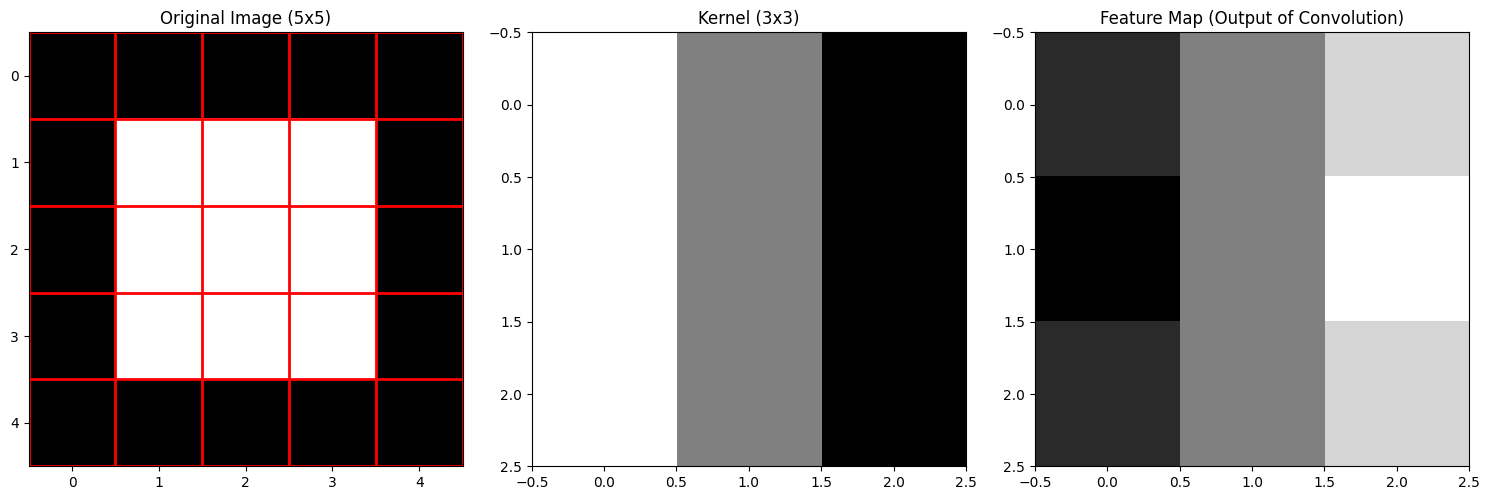

Original Image:
[[0 0 0 0 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 1 1 1 0]
 [0 0 0 0 0]]

Kernel:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Feature Map (Output after Convolution):
[[-2.  0.  2.]
 [-3.  0.  3.]
 [-2.  0.  2.]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Input image (simplified 2D array)
image = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

# Simple 3x3 filter (kernel) for edge detection
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# Function to perform a 2D convolution
def convolve2d(image, kernel):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Calculate output dimensions (assuming no padding, stride 1)
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Extract the receptive field (patch) from the image
            image_patch = image[i:i+kernel_height, j:j+kernel_width]
            # Perform element-wise multiplication and sum (dot product)
            output[i, j] = np.sum(image_patch * kernel)

    return output

# Perform convolution
feature_map = convolve2d(image, kernel)

# Plotting the process
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original Image
axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original Image (5x5)')
axes[0].set_xticks(np.arange(-.5, 5, 1), minor=True)
axes[0].set_yticks(np.arange(-.5, 5, 1), minor=True)
axes[0].grid(which="minor", color="red", linestyle='-', linewidth=2)
axes[0].tick_params(which="minor", size=0)

# Kernel
axes[1].imshow(kernel, cmap='gray', vmin=-1, vmax=1)
axes[1].set_title('Kernel (3x3)')
axes[1].set_xticks(np.arange(-.5, 3, 1), minor=True)
axes[1].set_yticks(np.arange(-.5, 3, 1), minor=True)
axes[1].grid(which="minor", color="red", linestyle='-', linewidth=2)
axes[1].tick_params(which="minor", size=0)

# Feature Map
axes[2].imshow(feature_map, cmap='gray', vmin=np.min(feature_map), vmax=np.max(feature_map))
axes[2].set_title('Feature Map (Output of Convolution)')
axes[2].set_xticks(np.arange(-.5, feature_map.shape[1], 1), minor=True)
axes[2].set_yticks(np.arange(-.5, feature_map.shape[0], 1), minor=True)
axes[2].grid(which="minor", color="red", linestyle='-', linewidth=2)
axes[2].tick_params(which="minor", size=0)

plt.tight_layout()
plt.show()

print("Original Image:")
print(image)
print("\nKernel:")
print(kernel)
print("\nFeature Map (Output after Convolution):")
print(feature_map)

## Topic 2: Image Representation

### Definition

In the context of computer vision and deep learning, an **image representation** refers to how a visual image is encoded and stored digitally, typically as a grid of numerical values. This representation is fundamental for computers to process, analyze, and learn from images. The way an image is represented directly impacts how efficiently and effectively a model like a CNN can extract information from it.

### Key Concepts

*   **Pixels:** The smallest individual unit of an image, typically a small square. Each pixel holds a numerical value representing its color and intensity. Images are essentially grids (or matrices) of pixels.

*   **Resolution:** Defines the detail an image holds, measured by the number of pixels along its width and height (e.g., 1920x1080 pixels). Higher resolution means more pixels, leading to a clearer and more detailed image, but also larger data size and computational load.

*   **Grayscale Images:** Images composed of shades of gray, ranging from black to white. Each pixel in a grayscale image has a single numerical value, usually from 0 (black) to 255 (white) in an 8-bit representation.

*   **RGB Images:** These are color images represented by three channels: Red, Green, and Blue. Each pixel has three corresponding intensity values (one for each channel), typically ranging from 0 to 255. By combining different intensities of R, G, and B, a wide spectrum of colors can be produced.

*   **Channels:** A channel refers to a component of an image. For grayscale images, there is one channel (intensity). For RGB images, there are three channels (Red, Green, Blue). Some images might have an additional Alpha channel for transparency.

*   **Image Tensor:** In deep learning, images are often represented as tensors. A tensor is a multi-dimensional array. For a grayscale image, it's a 2D tensor (height x width). For an RGB image, it's typically a 3D tensor (height x width x channels), or sometimes (channels x height x width).

*   **Image Dimensions:** Refers to the shape of the image tensor. For a single RGB image, the dimensions might be (Height, Width, Channels), e.g., (224, 224, 3) for a common input size in CNNs.

*   **Normalization:** A crucial preprocessing step where pixel values are scaled to a smaller, standardized range, typically [0, 1] or [-1, 1]. This helps neural networks train more stably and efficiently. For example, original pixel values (0-255) might be divided by 255 to normalize them to the [0, 1] range.

### Mathematics

#### Image Matrix

A grayscale image can be represented as a 2D matrix, where each element `I(x, y)` corresponds to the intensity value of the pixel at coordinates `(x, y)`.

$$ I = \begin{pmatrix}
I(0,0) & I(0,1) & \dots & I(0,W-1) \\
I(1,0) & I(1,1) & \dots & I(1,W-1) \\
\vdots & \vdots & \ddots & \vdots \\
I(H-1,0) & I(H-1,1) & \dots & I(H-1,W-1)
\end{pmatrix} $$

Where `H` is the height and `W` is the width of the image.

#### Tensor Shape

*   **Grayscale Image:** Shape `(Height, Width, 1)` or `(Height, Width)`
    *   Example: A 28x28 grayscale image would be `(28, 28, 1)` or `(28, 28)`.

*   **RGB Image:** Shape `(Height, Width, Channels)`
    *   Example: A 224x224 color image would be `(224, 224, 3)`.

*   **Batch of Images:** When training a neural network, multiple images are usually processed together in batches. The tensor shape for a batch of RGB images would be `(Batch_Size, Height, Width, Channels)`.
    *   Example: A batch of 32 images, each 224x224 RGB, would be `(32, 224, 224, 3)`.

### Numerical Example

Consider a tiny 2x2 RGB image. Each pixel has three color channels (Red, Green, Blue).

Let's assume the pixel values (normalized to 0-1) are:

*   **Pixel (0,0):** R=0.9, G=0.1, B=0.1 (Mostly Red)
*   **Pixel (0,1):** R=0.1, G=0.9, B=0.1 (Mostly Green)
*   **Pixel (1,0):** R=0.1, G=0.1, B=0.9 (Mostly Blue)
*   **Pixel (1,1):** R=0.5, G=0.5, B=0.5 (Gray)

This image would be represented as a 3D NumPy array (or tensor) with shape `(2, 2, 3)`:

```python
image_tensor = np.array([
    [ [0.9, 0.1, 0.1], [0.1, 0.9, 0.1] ],  # Row 0
    [ [0.1, 0.1, 0.9], [0.5, 0.5, 0.5] ]   # Row 1
])

# Shape: (Height, Width, Channels) = (2, 2, 3)
```

### Graphs & Python Demo: Image Tensor Visualization

Let's create a simple image from numerical arrays and visualize its RGB channels to understand how an image tensor is structured.

Shape of the RGB image tensor: (3, 3, 3)
Data type of the RGB image tensor: uint8


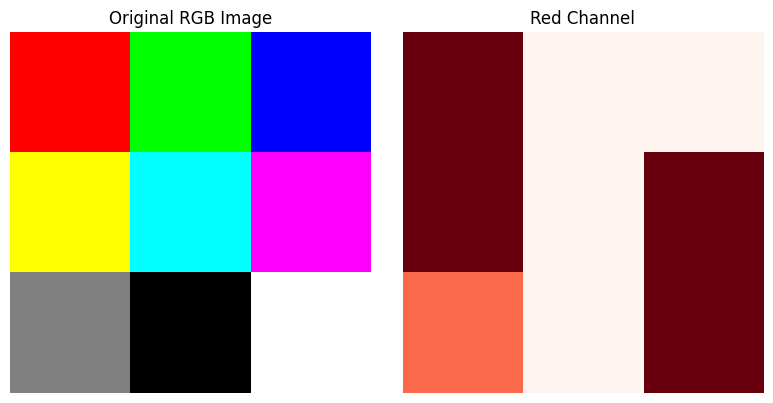

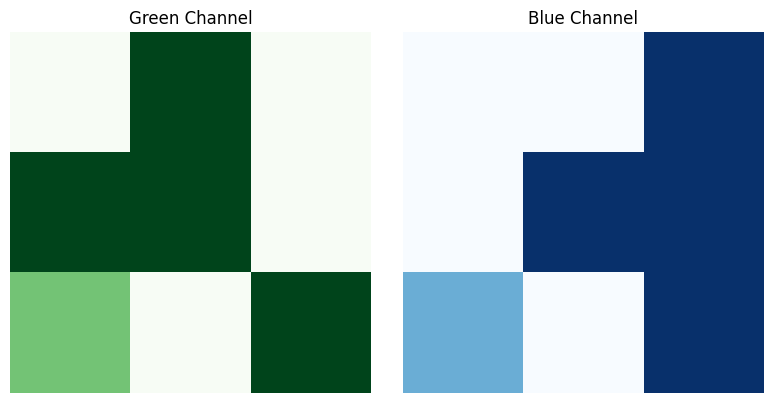


Shape of the Grayscale image tensor: (3, 3)


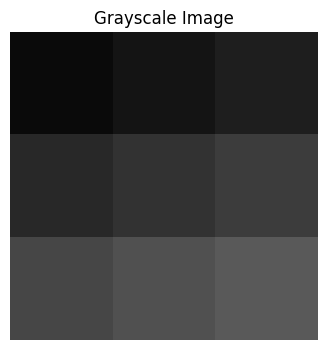

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple 3x3 RGB image tensor (values from 0 to 255)
# Shape: (Height, Width, Channels)
rgb_image = np.array([
    [[255, 0, 0], [0, 255, 0], [0, 0, 255]],  # Row 0: Red, Green, Blue
    [[255, 255, 0], [0, 255, 255], [255, 0, 255]], # Row 1: Yellow, Cyan, Magenta
    [[128, 128, 128], [0, 0, 0], [255, 255, 255]]  # Row 2: Gray, Black, White
], dtype=np.uint8)

print("Shape of the RGB image tensor:", rgb_image.shape)
print("Data type of the RGB image tensor:", rgb_image.dtype)

# Normalize the image for display if it's not already 0-1 (Matplotlib handles 0-255 directly)
# display_image = rgb_image / 255.0 # Not strictly necessary for imshow with uint8

# Visualize the full RGB image
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title('Original RGB Image')
plt.axis('off')

# Visualize individual channels
plt.subplot(1, 2, 2)
plt.imshow(rgb_image[:,:,0], cmap='Reds') # Red channel
plt.title('Red Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb_image[:,:,1], cmap='Greens') # Green channel
plt.title('Green Channel')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_image[:,:,2], cmap='Blues') # Blue channel
plt.title('Blue Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

# Example of a grayscale image
grayscale_image = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
], dtype=np.uint8)

print("\nShape of the Grayscale image tensor:", grayscale_image.shape)

plt.figure(figsize=(4, 4))
plt.imshow(grayscale_image, cmap='gray', vmin=0, vmax=255)
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

## Topic 3: Convolution Operation

### Definition

The **Convolution Operation** is the fundamental building block of a Convolutional Neural Network (CNN). It's a mathematical operation that involves combining two functions to produce a third function, which expresses how the shape of one is modified by the other. In the context of images, it refers to applying a small matrix, called a **filter** or **kernel**, over an input image to produce a **feature map** (or activation map).

### Why Convolution?

Convolution addresses the shortcomings of traditional ANNs for image processing:

*   **Feature Extraction:** Automatically extracts relevant features (edges, textures, patterns) from raw pixel data.
*   **Parameter Sharing:** The same filter is applied across the entire image, significantly reducing the number of learnable parameters.
*   **Sparsity of Connections:** Each neuron in the feature map is connected to only a small, local region of the input image, rather than all pixels.
*   **Translation Equivariance:** If the input image shifts, the feature map will also shift in the same way, helping the network recognize features regardless of their position.

### Sliding Window (Receptive Field)

At the core of convolution is the concept of a **sliding window** or **receptive field**. The filter (kernel) is a small matrix that "slides" over the input image from left to right, and top to bottom. At each position, it performs a dot product between the filter values and the corresponding patch of the image.

### Convolution Process

1.  **Define Filter:** A small matrix (e.g., 3x3, 5x5) of weights, also known as a kernel, is initialized.
2.  **Slide Filter:** The filter is placed on a small region (receptive field) of the input image.
3.  **Element-wise Multiplication:** Each element of the filter is multiplied by the corresponding pixel value in the image region.
4.  **Summation:** All the products are summed up.
5.  **Activation Map:** The summed value forms a single pixel in the output feature map. This process is repeated by sliding the filter across the entire image until a complete feature map is generated.

### Feature Extraction

Each filter is designed (or learned during training) to detect a specific type of feature. For example:

*   One filter might detect vertical edges.
*   Another might detect horizontal edges.
*   Yet another could detect corners or specific textures.

The output of applying a filter is a **feature map**, which highlights where that specific feature is present in the input image. CNNs learn multiple such filters, allowing them to extract a rich set of features at different levels of abstraction.

### Mathematics

#### Convolution Formula (2D)

The 2D convolution operation for an image $I$ and a kernel $K$ to produce an output feature map $S$ (also denoted as $(I * K)$) is given by:

$$ S(i, j) = (I * K)(i, j) = \sum_m \sum_n I(i-m, j-n) K(m, n) $$

Alternatively, it's often more intuitively presented as:

$$ S(i, j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} I(i+m, j+n) K(m, n) $$

Where:
*   $I$ is the input image.
*   $K$ is the kernel (filter).
*   $S$ is the output feature map.
*   $(i, j)$ are the coordinates in the output feature map.
*   $k_h$ and $k_w$ are the height and width of the kernel, respectively.

#### Output Size Formula (without padding, stride 1)

Given an input image of dimensions `H x W` and a kernel of dimensions `k_h x k_w`, the output feature map dimensions `H' x W'` (assuming no padding and a stride of 1) are:

$$ H' = H - k_h + 1 $$
$$ W' = W - k_w + 1 $$

For example, a 5x5 image with a 3x3 kernel will produce a (5-3+1) x (5-3+1) = 3x3 feature map.

### Numerical Example: Manual Calculation

Let's manually perform a convolution for a small 3x3 image and a 2x2 kernel.

**Input Image (I):**
```
[[1, 2, 3],
 [4, 5, 6],
 [7, 8, 9]]
```

**Kernel (K):**
```
[[1, 0],
 [0, 1]]
```

**Output Size:**
$H' = 3 - 2 + 1 = 2$
$W' = 3 - 2 + 1 = 2$
So, the output feature map will be 2x2.

**Calculations:**

*   **Top-Left (0,0) of Feature Map:**
    Image patch: `[[1, 2], [4, 5]]`
    Kernel: `[[1, 0], [0, 1]]`
    Result = (1*1) + (2*0) + (4*0) + (5*1) = 1 + 0 + 0 + 5 = **6**

*   **Top-Right (0,1) of Feature Map:**
    Image patch: `[[2, 3], [5, 6]]`
    Kernel: `[[1, 0], [0, 1]]`
    Result = (2*1) + (3*0) + (5*0) + (6*1) = 2 + 0 + 0 + 6 = **8**

*   **Bottom-Left (1,0) of Feature Map:**
    Image patch: `[[4, 5], [7, 8]]`
    Kernel: `[[1, 0], [0, 1]]`
    Result = (4*1) + (5*0) + (7*0) + (8*1) = 4 + 0 + 0 + 8 = **12**

*   **Bottom-Right (1,1) of Feature Map:**
    Image patch: `[[5, 6], [8, 9]]`
    Kernel: `[[1, 0], [0, 1]]`
    Result = (5*1) + (6*0) + (8*0) + (9*1) = 5 + 0 + 0 + 9 = **14**

**Resulting Feature Map:**
```
[[ 6,  8],
 [12, 14]]
```

### Graphs & Python Demo: Sliding Kernel and Feature Map Generation

Let's use Python to visualize the step-by-step convolution process, showing the sliding kernel and how the feature map is built.

Input Image:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

Kernel:
 [[1 0]
 [0 1]]

Expected Feature Map size: 2x2



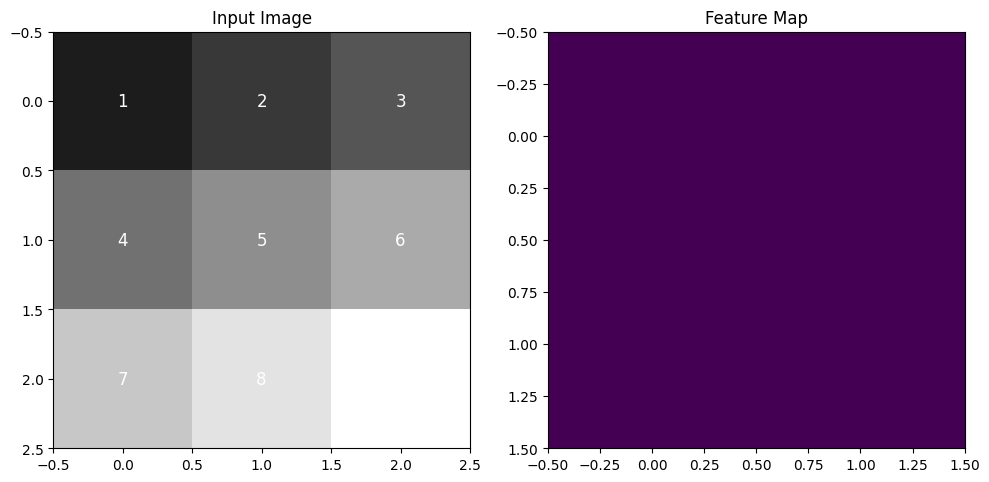

--- Step-by-step Convolution ---

Position (0,0):
  Image Patch:
 [[1 2]
 [4 5]]
  Kernel:
 [[1 0]
 [0 1]]
  Result: 6



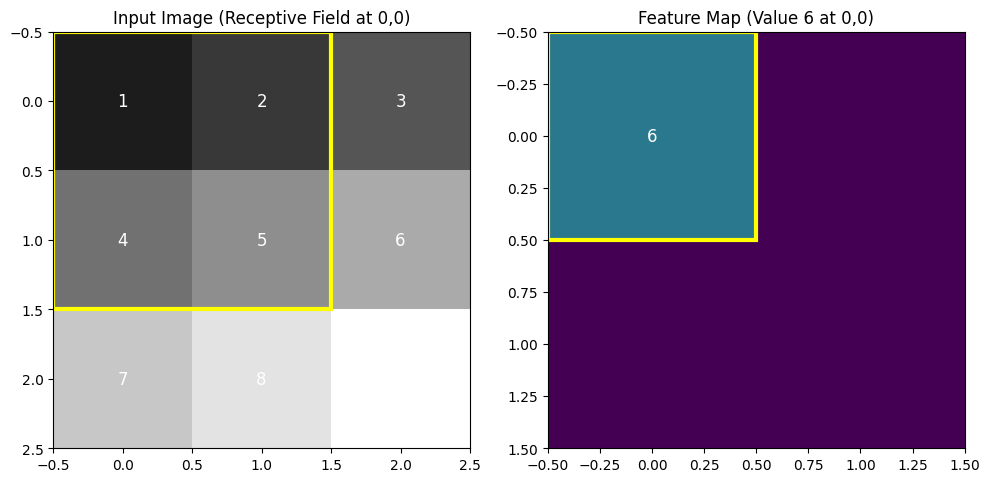

Position (0,1):
  Image Patch:
 [[2 3]
 [5 6]]
  Kernel:
 [[1 0]
 [0 1]]
  Result: 8



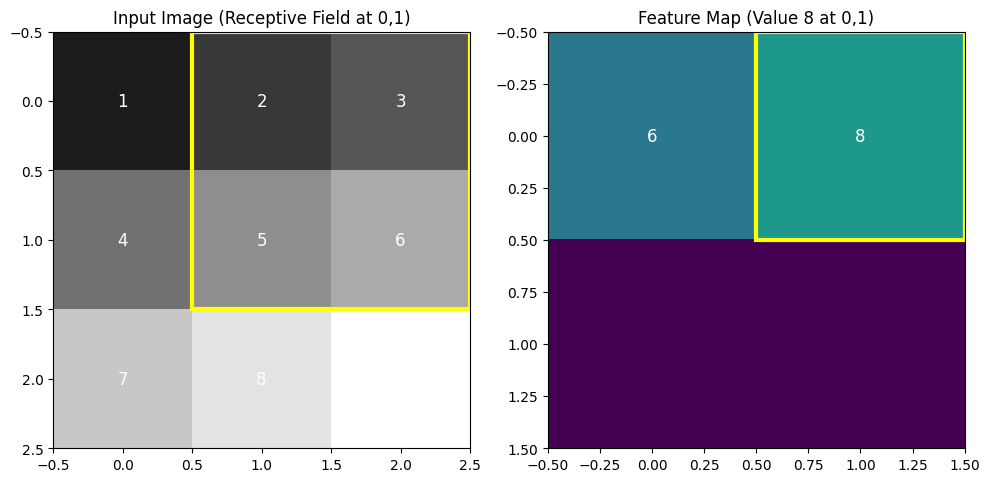

Position (1,0):
  Image Patch:
 [[4 5]
 [7 8]]
  Kernel:
 [[1 0]
 [0 1]]
  Result: 12



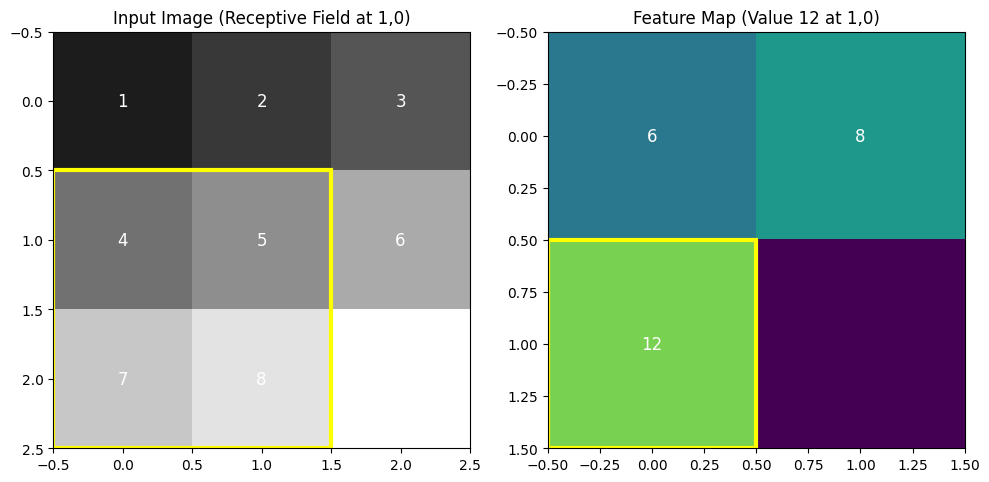

Position (1,1):
  Image Patch:
 [[5 6]
 [8 9]]
  Kernel:
 [[1 0]
 [0 1]]
  Result: 14



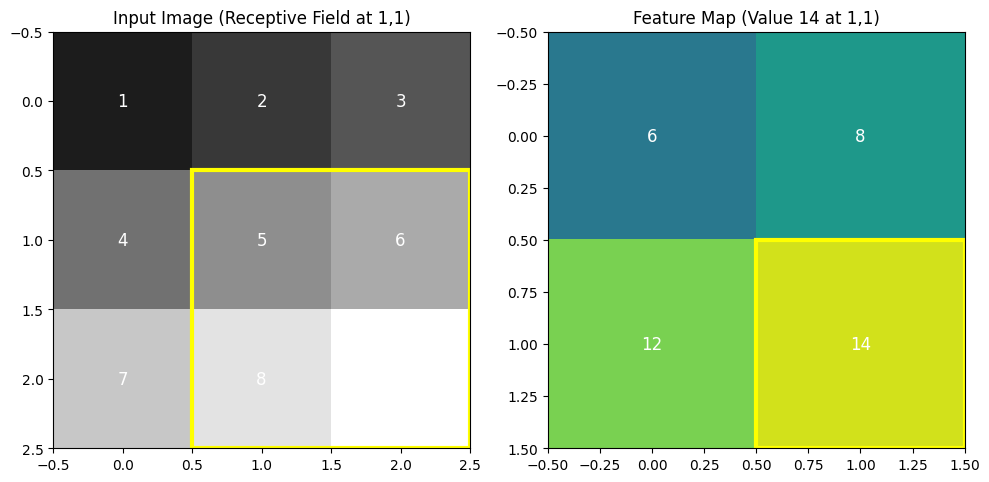

Final Feature Map:
 [[ 6.  8.]
 [12. 14.]]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Input image (3x3)
image = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Kernel (2x2)
kernel = np.array([
    [1, 0],
    [0, 1]
])

# Output dimensions
output_height = image.shape[0] - kernel.shape[0] + 1
output_width = image.shape[1] - kernel.shape[1] + 1
feature_map = np.zeros((output_height, output_width))

print("Input Image:\n", image)
print("\nKernel:\n", kernel)
print(f"\nExpected Feature Map size: {output_height}x{output_width}\n")

# --- Visualization Setup ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the input image with grid
axes[0].imshow(image, cmap='gray', vmin=0, vmax=9)
axes[0].set_title('Input Image')
axes[0].set_xticks(np.arange(-.5, image.shape[1], 1), minor=True)
axes[0].set_yticks(np.arange(-.5, image.shape[0], 1), minor=True)
axes[0].grid(which="minor", color="red", linestyle='-', linewidth=1)
for (j, i), label in np.ndenumerate(image):
    axes[0].text(i, j, label, ha='center', va='center', color='white', fontsize=12)

# Plot the empty feature map with grid
axes[1].imshow(feature_map, cmap='viridis', vmin=0, vmax=15) # vmax adjusted for example output
axes[1].set_title('Feature Map')
axes[1].set_xticks(np.arange(-.5, feature_map.shape[1], 1), minor=True)
axes[1].set_yticks(np.arange(-.5, feature_map.shape[0], 1), minor=True)
axes[1].grid(which="minor", color="green", linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

print("--- Step-by-step Convolution ---\n")

# --- Perform convolution and visualize each step ---
for i in range(output_height):
    for j in range(output_width):
        # Extract image patch
        image_patch = image[i:i+kernel.shape[0], j:j+kernel.shape[1]]

        # Calculate convolution result
        conv_result = np.sum(image_patch * kernel)
        feature_map[i, j] = conv_result

        print(f"Position ({i},{j}):")
        print("  Image Patch:\n", image_patch)
        print("  Kernel:\n", kernel)
        print(f"  Result: {conv_result}\n")

        # Update plots for visualization
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Input image with current receptive field highlighted
        axes[0].imshow(image, cmap='gray', vmin=0, vmax=9)
        axes[0].set_title(f'Input Image (Receptive Field at {i},{j})')
        axes[0].set_xticks(np.arange(-.5, image.shape[1], 1), minor=True)
        axes[0].set_yticks(np.arange(-.5, image.shape[0], 1), minor=True)
        axes[0].grid(which="minor", color="red", linestyle='-', linewidth=1)
        for (y, x), label in np.ndenumerate(image):
            axes[0].text(x, y, label, ha='center', va='center', color='white', fontsize=12)

        # Highlight the current patch
        rect = patches.Rectangle((j-0.5, i-0.5), kernel.shape[1], kernel.shape[0],
                                 linewidth=3, edgecolor='yellow', facecolor='none')
        axes[0].add_patch(rect)

        # Feature Map with current result highlighted
        axes[1].imshow(feature_map, cmap='viridis', vmin=0, vmax=15) # vmax adjusted for example output
        axes[1].set_title(f'Feature Map (Value {int(conv_result)} at {i},{j})')
        axes[1].set_xticks(np.arange(-.5, feature_map.shape[1], 1), minor=True)
        axes[1].set_yticks(np.arange(-.5, feature_map.shape[0], 1), minor=True)
        axes[1].grid(which="minor", color="green", linestyle='-', linewidth=1)
        for (y, x), val in np.ndenumerate(feature_map):
            if val != 0:
                axes[1].text(x, y, int(val), ha='center', va='center', color='white', fontsize=12)

        # Highlight the current output cell
        rect_out = patches.Rectangle((j-0.5, i-0.5), 1, 1,
                                     linewidth=3, edgecolor='yellow', facecolor='none')
        axes[1].add_patch(rect_out)

        plt.tight_layout()
        plt.show()

print("Final Feature Map:\n", feature_map)


## Topic 4: Filters (Kernels)

### Definition

A **Filter**, also known as a **Kernel** or **Convolutional Kernel**, is a small matrix of numbers that is used to perform the convolution operation. When a filter is convolved with an input image, it produces a feature map that highlights specific patterns or characteristics of the image.

### Why Filters?

Filters are the essence of feature extraction in CNNs. Each filter is designed to detect a particular type of pattern or feature in the input data. For example:

*   **Feature Detection:** Different filters can detect edges, corners, textures, gradients, or blobs.
*   **Weight Sharing:** The same filter is applied across the entire image. This significantly reduces the number of learnable parameters compared to a fully connected layer, making the network more efficient and preventing overfitting.
*   **Local Connectivity:** Filters operate on small, local regions of the input, allowing the network to capture local spatial relationships while building hierarchical representations.

### Learnable Filters

In a CNN, the values within these filters are **learnable parameters**. During the training process, the network adjusts the numbers within these filter matrices through backpropagation to minimize the loss function. This means the CNN automatically learns which features are most relevant for the given task (e.g., classifying cats vs. dogs).

### Multiple Filters

A single convolutional layer typically employs **multiple filters**. Each filter learns to detect a different feature. For an input image, applying `N` different filters will result in `N` different feature maps. These multiple feature maps are then stacked together, forming a new multi-channel output that serves as the input to the next layer in the CNN architecture.

### Common Filters

Here are some common types of filters and their typical applications:

*   **Edge Detection:** Filters designed to highlight boundaries or changes in intensity. These are fundamental for outlining objects.
    *   **Vertical Edge Filter:** Detects vertical lines or changes in vertical intensity.
    *   **Horizontal Edge Filter:** Detects horizontal lines or changes in horizontal intensity.
*   **Sharpen Filter:** Enhances the contrast of edges and details in an image, making it appear sharper.
*   **Blur Filter (Smoothing Filter):** Averages pixel values in a region, which reduces noise and smooths out details.
*   **Emboss Filter:** Creates an effect that makes the image appear as if it's been stamped or raised, often highlighting edges and converting the image to grayscale with highlights and shadows.

### Mathematics

Mathematically, a filter $K$ is a small matrix of weights. The output of applying this filter to an image $I$ at a particular position $(i, j)$ in the feature map $S$ is calculated using the convolution formula:

$$ S(i, j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} I(i+m, j+n) K(m, n) $$

Where $K(m, n)$ represents the weight of the filter at position $(m, n)$. Each value in the filter contributes to the weighted sum, determining how much that part of the image patch influences the output pixel in the feature map.

### Numerical Example (Revisiting):

Let's reuse our previous numerical example to illustrate how a filter's values directly influence the feature map output.

**Input Image (I):**
```
[[1, 2, 3],
 [4, 5, 6],
 [7, 8, 9]]
```

**Kernel (K - Example Vertical Edge Detector):**
```
[[-1, 0, 1],
 [-1, 0, 1],
 [-1, 0, 1]]
```

**Output Size:** For a 3x3 image and a 3x3 kernel, the output will be (3-3+1) x (3-3+1) = 1x1.

**Calculations for the single output pixel (0,0):**

Image Patch (entire image for a 1x1 output):
```
[[1, 2, 3],
 [4, 5, 6],
 [7, 8, 9]]
```

Kernel:
```
[[-1, 0, 1],
 [-1, 0, 1],
 [-1, 0, 1]]
```

Result = (1*-1) + (2*0) + (3*1) +
         (4*-1) + (5*0) + (6*1) +
         (7*-1) + (8*0) + (9*1)

Result = (-1) + 0 + 3 +
         (-4) + 0 + 6 +
         (-7) + 0 + 9

Result = 2 + 2 + 2 = **6**

This simple example shows how the filter's specific values (e.g., negative on one side, positive on the other) enhance certain features (like vertical edges) while suppressing others.

### Graphs & Python: Applying Different Filters

Let's apply several common filters to an image to visually understand their effects and how they generate different feature maps.

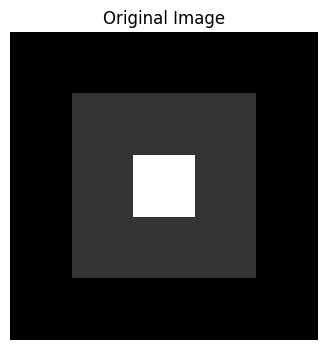

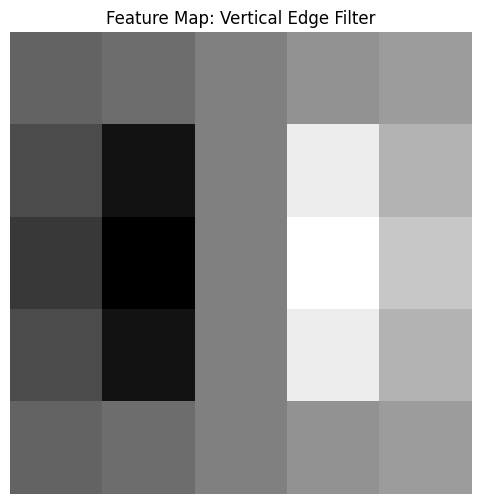

--- Vertical Edge Filter ---
Kernel:
 [[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]
Feature Map:
 [[ -60.  -40.    0.   40.   60.]
 [-110. -230.    0.  230.  110.]
 [-150. -270.    0.  270.  150.]
 [-110. -230.    0.  230.  110.]
 [ -60.  -40.    0.   40.   60.]]




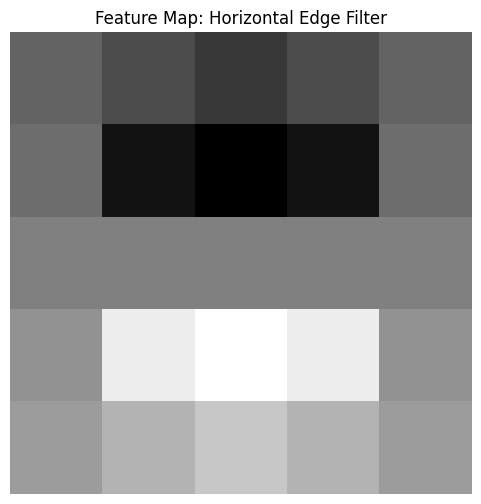

--- Horizontal Edge Filter ---
Kernel:
 [[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]
Feature Map:
 [[ -60. -110. -150. -110.  -60.]
 [ -40. -230. -270. -230.  -40.]
 [   0.    0.    0.    0.    0.]
 [  40.  230.  270.  230.   40.]
 [  60.  110.  150.  110.   60.]]




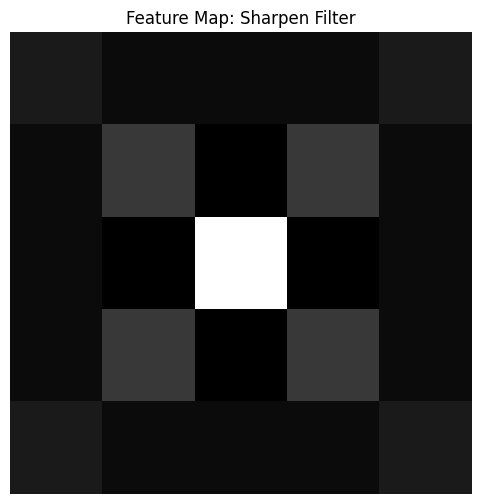

--- Sharpen Filter ---
Kernel:
 [[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]
Feature Map:
 [[ 30. -20. -20. -20.  30.]
 [-20. 130. -60. 130. -20.]
 [-20. -60. 800. -60. -20.]
 [-20. 130. -60. 130. -20.]
 [ 30. -20. -20. -20.  30.]]




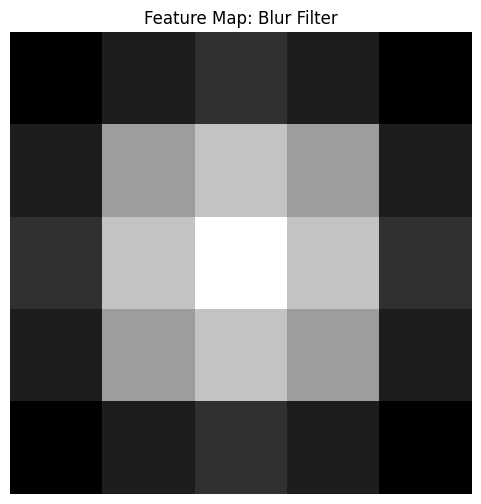

--- Blur Filter ---
Kernel:
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Feature Map:
 [[ 8.888889 15.555555 20.       15.555555  8.888889]
 [15.555555 44.444447 53.333332 44.444447 15.555555]
 [20.       53.333332 66.666664 53.333332 20.      ]
 [15.555555 44.444447 53.333332 44.444447 15.555555]
 [ 8.888889 15.555555 20.       15.555555  8.888889]]




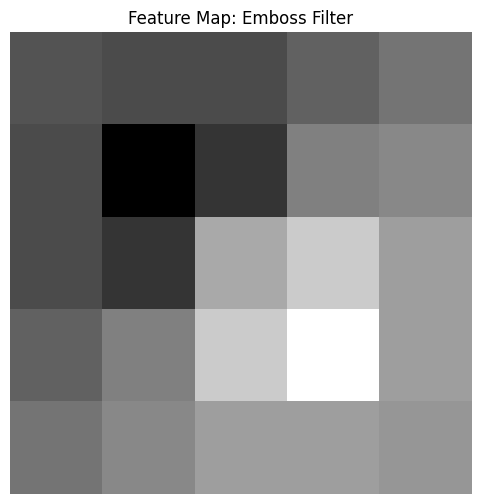

--- Emboss Filter ---
Kernel:
 [[-2. -1.  0.]
 [-1.  1.  1.]
 [ 0.  1.  2.]]
Feature Map:
 [[-110. -140. -140.  -60.   10.]
 [-140. -410. -220.   50.   80.]
 [-140. -220.  200.  320.  160.]
 [ -60.   50.  320.  510.  160.]
 [  10.   80.  160.  160.  130.]]




In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# Sample image (a simple 5x5 image)
image = np.array([
    [10, 10, 10, 10, 10],
    [10, 50, 50, 50, 10],
    [10, 50, 200, 50, 10],
    [10, 50, 50, 50, 10],
    [10, 10, 10, 10, 10]
], dtype=np.float32)

# Normalize for better visualization if needed, but not strictly required for convolution
# image_norm = image / 255.0

# Define several common filters (kernels)
filters = {
    "Original": np.array([[0]]),
    "Vertical Edge": np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32),
    "Horizontal Edge": np.array([
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1]
    ], dtype=np.float32),
    "Sharpen": np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32),
    "Blur": np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.float32) / 9.0, # Normalize blur filter
    "Emboss": np.array([
        [-2, -1, 0],
        [-1, 1, 1],
        [0, 1, 2]
    ], dtype=np.float32)
}

# Plot the original image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# Apply each filter and plot the resulting feature map
for name, kernel_matrix in filters.items():
    if name == "Original":
        continue # Already plotted

    # Perform convolution using scipy.ndimage.convolve
    # 'mode="constant"' for zero padding, 'cval=0.0' sets pad value to 0
    # 'origin=0' means the center of the filter is at the top-left of the image patch
    feature_map = convolve(image, kernel_matrix, mode='constant', cval=0.0, origin=0)

    plt.figure(figsize=(6, 6))
    plt.imshow(feature_map, cmap='gray')
    plt.title(f'Feature Map: {name} Filter')
    plt.axis('off')
    plt.show()

    print(f"--- {name} Filter ---")
    print("Kernel:\n", kernel_matrix)
    print("Feature Map:\n", feature_map)
    print("\n" + "="*30 + "\n")

## Topic 5 : Stride

### Definition

**Stride** is a parameter of the convolutional layer that controls how the filter (or kernel) slides over the input image. It defines the step size by which the filter moves across the width and height of the input volume. A stride of 1 means the filter moves one pixel at a time, while a stride of 2 means it skips every other pixel, and so on.

### Why Stride?

*   **Dimensionality Reduction:** Increasing the stride effectively downsamples the spatial dimensions (height and width) of the output feature map. This reduces the computational cost of the network and the number of parameters in subsequent layers.
*   **Capturing Broader Features:** Larger strides allow the network to cover a larger receptive field in the original image with fewer operations, potentially capturing more global or coarser features.
*   **Controlling Output Size:** Stride is a key factor, along with padding and kernel size, in determining the spatial dimensions of the output feature map.

### Effect on Output

*   **Stride = 1 (Default):** The filter moves one pixel at a time. This usually results in an output feature map that is only slightly smaller than the input (if no padding is used).
*   **Stride > 1:** The filter skips pixels. For example, a stride of 2 will make the filter jump two pixels horizontally and two pixels vertically. This significantly reduces the size of the output feature map compared to a stride of 1.

### Mathematics

#### Output Size Formula (with Stride, without padding)

Given an input image of dimensions `H x W`, a kernel of dimensions `k_h x k_w`, and a stride of `S` (assuming `S_h = S_w = S`), the output feature map dimensions `H' x W'` (without padding) are calculated as:

$$ H' = \lfloor \frac{H - k_h}{S} \rfloor + 1 $$
$$ W' = \lfloor \frac{W - k_w}{S} \rfloor + 1 $$

Where $\lfloor \cdot \rfloor$ denotes the floor function (rounding down to the nearest integer).

If padding `P` is also considered (typically `P_h = P_w = P` for symmetric padding on both sides), the formula becomes:

$$ H' = \lfloor \frac{H - k_h + 2P}{S} \rfloor + 1 $$
$$ W' = \lfloor \frac{W - k_w + 2P}{S} \rfloor + 1 $$


### Numerical Example

Let's consider an **Input Image** of size 7x7 and a **Kernel** of size 3x3.

*   **Input Image (H=7, W=7)**
*   **Kernel (k_h=3, k_w=3)**

#### Example 1: Stride = 1 (S=1), No Padding (P=0)

*   $H' = \lfloor \frac{7 - 3}{1} \rfloor + 1 = \lfloor \frac{4}{1} \rfloor + 1 = 4 + 1 = 5$
*   $W' = \lfloor \frac{7 - 3}{1} \rfloor + 1 = \lfloor \frac{4}{1} \rfloor + 1 = 4 + 1 = 5$

Output Feature Map: **5x5**

#### Example 2: Stride = 2 (S=2), No Padding (P=0)

*   $H' = \lfloor \frac{7 - 3}{2} \rfloor + 1 = \lfloor \frac{4}{2} \rfloor + 1 = 2 + 1 = 3$
*   $W' = \lfloor \frac{7 - 3}{2} \rfloor + 1 = \lfloor \frac{4}{2} \rfloor + 1 = 2 + 1 = 3$

Output Feature Map: **3x3**

#### Example 3: Stride = 3 (S=3), No Padding (P=0)

*   $H' = \lfloor \frac{7 - 3}{3} \rfloor + 1 = \lfloor \frac{4}{3} \rfloor + 1 = 1 + 1 = 2$
*   $W' = \lfloor \frac{7 - 3}{3} \rfloor + 1 = \lfloor \frac{4}{3} \rfloor + 1 = 1 + 1 = 2$

Output Feature Map: **2x2**

This clearly shows how increasing the stride reduces the spatial dimensions of the output.

### Graphs & Python with plot: Visualizing Different Strides

Let's visualize the convolution process with different stride values on a sample image.

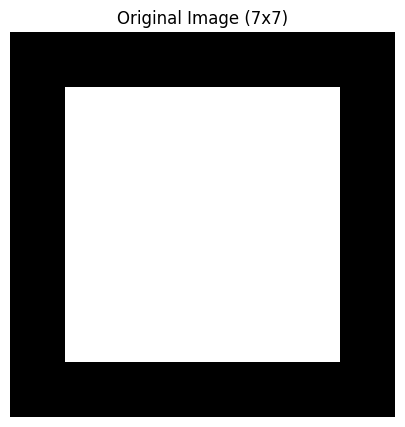


--- Stride = 1 ---
Output Feature Map (Shape: (5, 5)):
[[0.44444445 0.66666669 0.66666669 0.66666669 0.44444445]
 [0.66666669 1.         1.         1.         0.66666669]
 [0.66666669 1.         1.         1.         0.66666669]
 [0.66666669 1.         1.         1.         0.66666669]
 [0.44444445 0.66666669 0.66666669 0.66666669 0.44444445]]


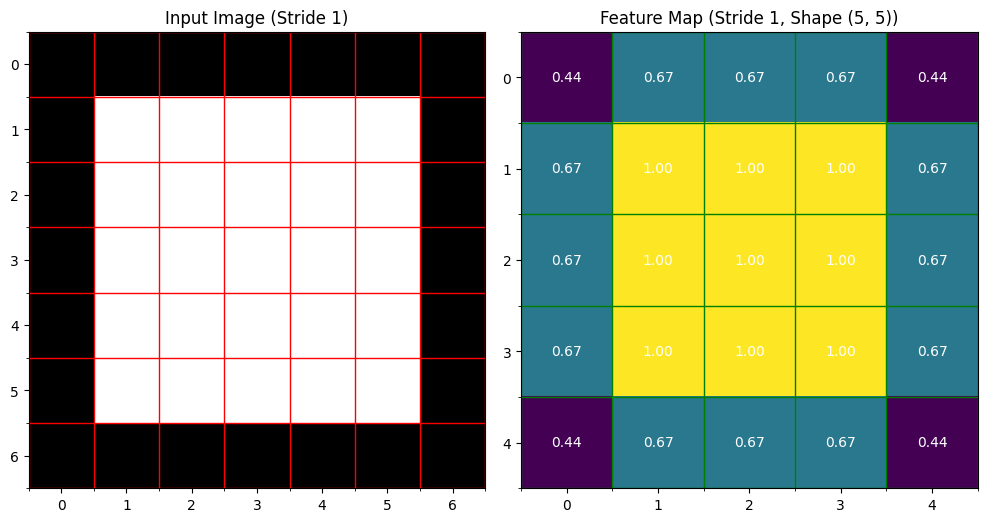


--- Stride = 2 ---
Output Feature Map (Shape: (3, 3)):
[[0.44444445 0.66666669 0.44444445]
 [0.66666669 1.         0.66666669]
 [0.44444445 0.66666669 0.44444445]]


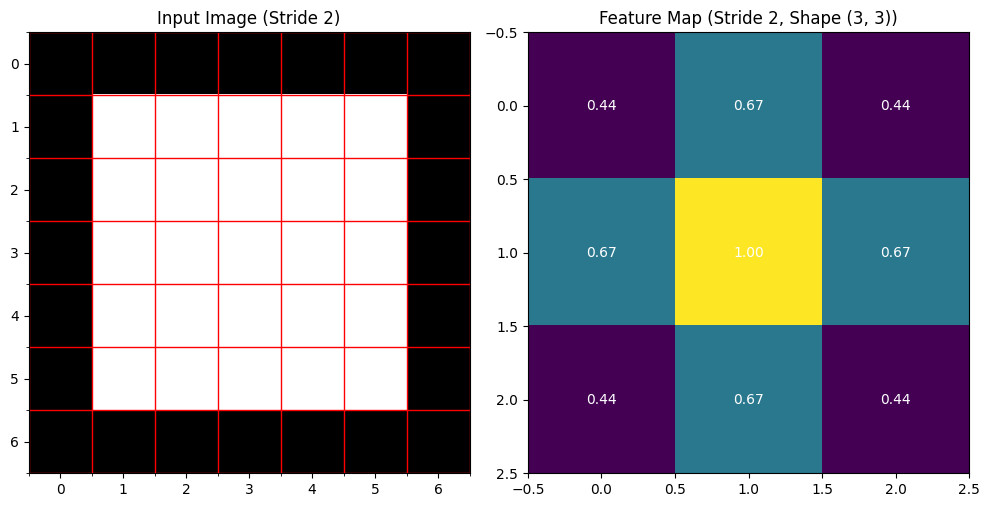


--- Stride = 3 ---
Output Feature Map (Shape: (2, 2)):
[[0.44444445 0.66666669]
 [0.66666669 1.        ]]


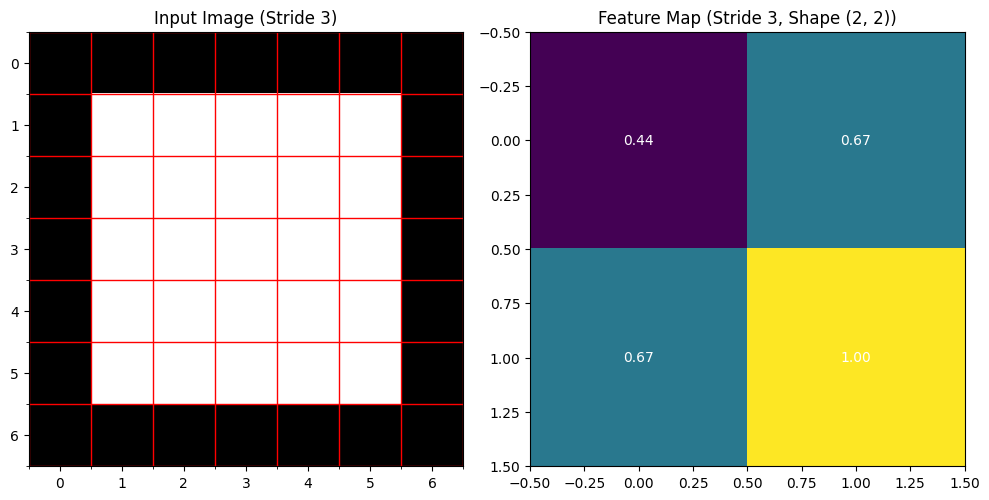

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Input image (7x7 for demonstration)
image = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0]
], dtype=np.float32)

# Kernel (3x3 simple averaging filter)
kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32) / 9.0

def convolve2d_with_stride(image, kernel, stride):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = (image_height - kernel_height) // stride + 1
    output_width = (image_width - kernel_width) // stride + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Calculate start indices for the current patch based on stride
            start_h = i * stride
            start_w = j * stride

            image_patch = image[start_h : start_h + kernel_height,
                                start_w : start_w + kernel_width]
            output[i, j] = np.sum(image_patch * kernel)

    return output

strides_to_test = [1, 2, 3]

plt.figure(figsize=(15, 5))
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title('Original Image (7x7)')
plt.axis('off')
plt.show()

for s in strides_to_test:
    feature_map = convolve2d_with_stride(image, kernel, s)

    print(f"\n--- Stride = {s} ---")
    print(f"Output Feature Map (Shape: {feature_map.shape}):\n{feature_map}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Plot input image with grid
    axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Input Image (Stride {s})')
    axes[0].set_xticks(np.arange(-.5, image.shape[1], 1), minor=True)
    axes[0].set_yticks(np.arange(-.5, image.shape[0], 1), minor=True)
    axes[0].grid(which="minor", color="red", linestyle='-', linewidth=1)

    # Plot feature map
    axes[1].imshow(feature_map, cmap='viridis')
    axes[1].set_title(f'Feature Map (Stride {s}, Shape {feature_map.shape})')
    axes[1].set_xticks(np.arange(-.5, feature_map.shape[1], 1), minor=True)
    axes[1].set_yticks(np.arange(-.5, feature_map.shape[0], 1), minor=True)
    axes[1].grid(which="minor", color="green", linestyle='-', linewidth=1)
    for (y, x), val in np.ndenumerate(feature_map):
        axes[1].text(x, y, f'{val:.2f}', ha='center', va='center', color='white', fontsize=10)

    plt.tight_layout()
    plt.show()

## Topic 6 : Padding

### Definition

**Padding** is a technique used in convolutional neural networks to add extra pixels, typically with zero values, around the border of an input image (or feature map) before performing the convolution operation. The primary reason for padding is to control the spatial dimensions of the output feature map and to prevent information loss at the edges of the input.

### Why Padding?

1.  **Preserving Spatial Information at Borders:** Without padding, pixels at the edges and corners of the input image are used less frequently in the convolution process than pixels in the center. This means information from the edges gets less weight and can be lost. Padding ensures that all pixels, especially those at the borders, contribute equally to the output, thus preserving more information.

2.  **Controlling Output Size:** Padding allows us to create output feature maps that are the same size as the input, or larger, which is often desirable in network architectures (e.g., to maintain spatial resolution through multiple layers).

3.  **Preventing Shrinkage:** As filters slide over an image without padding, the output feature map typically shrinks. Repeated convolution without padding would quickly reduce the image to a very small size, limiting the number of layers a CNN can have. Padding helps mitigate this shrinkage.

### Types of Padding

While there are various ways to pad, the most common types in CNNs are:

*   **Valid Padding (No Padding):** This is when no padding is added. The filter only slides over valid positions where it completely overlaps with the input. As a result, the output feature map will always be smaller than the input (unless the filter size is 1x1).

*   **Same Padding (Zero Padding):** This type of padding ensures that the output feature map has the *same spatial dimensions* (height and width) as the input image. This is achieved by symmetrically adding zeros around the input image's borders. The amount of padding `P` needed for 'same' padding (assuming stride S=1) is typically calculated such that `P = (K - 1) / 2`, where `K` is the kernel size. If K is an even number, it's typically `P = K / 2` with the extra padding on one side.

*   **Zero Padding:** A general term for adding zeros around the input. 'Same padding' is a specific application of zero padding where the amount of padding is chosen to maintain spatial dimensions. Other amounts of zero padding can also be used.

### Mathematics

#### Output Size Formula (with Padding and Stride)

Given an input image of dimensions `H x W`, a kernel of dimensions `k_h x k_w`, a stride of `S` (assuming `S_h = S_w = S`), and padding of `P` (meaning `P` rows/columns are added to each side, so `2P` total padding on height and width), the output feature map dimensions `H' x W'` are calculated as:

$$ H' = \lfloor \frac{H - k_h + 2P}{S} \rfloor + 1 $$
$$ W' = \lfloor \frac{W - k_w + 2P}{S} \rfloor + 1 $$

Where $\lfloor \cdot \rfloor$ denotes the floor function (rounding down to the nearest integer).

#### Padding for "Same" Output Size (Stride = 1)

To achieve an output feature map of the same size as the input image (i.e., $H' = H$ and $W' = W$) with a stride $S=1$, the amount of padding $P$ required for a kernel size $K$ (assuming $k_h = k_w = K$) is:

$$ P = \frac{K - 1}{2} $$

This formula works perfectly when the kernel size $K$ is an odd number (e.g., 3x3, 5x5). If $K$ is an even number, asymmetric padding might be needed, or one side might get an extra row/column of padding.

### Numerical Example

Let's consider an **Input Image** of size 7x7 and a **Kernel** of size 3x3.

*   **Input Image (H=7, W=7)**
*   **Kernel (k_h=3, k_w=3)**
*   **Stride (S=1)**

#### Example 1: Valid Padding (No Padding, P=0)

*   $H' = \lfloor \frac{7 - 3 + 2 \cdot 0}{1} \rfloor + 1 = \lfloor \frac{4}{1} \rfloor + 1 = 4 + 1 = 5$
*   $W' = \lfloor \frac{7 - 3 + 2 \cdot 0}{1} \rfloor + 1 = \lfloor \frac{4}{1} \rfloor + 1 = 4 + 1 = 5$

Output Feature Map: **5x5** (Smaller than input)

#### Example 2: Same Padding (Zero Padding, P=1)

For a 3x3 kernel, $P = (3 - 1) / 2 = 1$.
So, we add 1 pixel of padding on each side.

*   $H' = \lfloor \frac{7 - 3 + 2 \cdot 1}{1} \rfloor + 1 = \lfloor \frac{4 + 2}{1} \rfloor + 1 = \lfloor \frac{6}{1} \rfloor + 1 = 6 + 1 = 7$
*   $W' = \lfloor \frac{7 - 3 + 2 \cdot 1}{1} \rfloor + 1 = \lfloor \frac{4 + 2}{1} \rfloor + 1 = \lfloor \frac{6}{1} \rfloor + 1 = 6 + 1 = 7$

Output Feature Map: **7x7** (Same size as input)

This demonstrates how padding helps maintain the spatial dimensions of the feature map.

### Graphs & Python with plot: Visualizing Padding

Let's visualize the effect of padding on the output size of a convolution operation using a simple example.

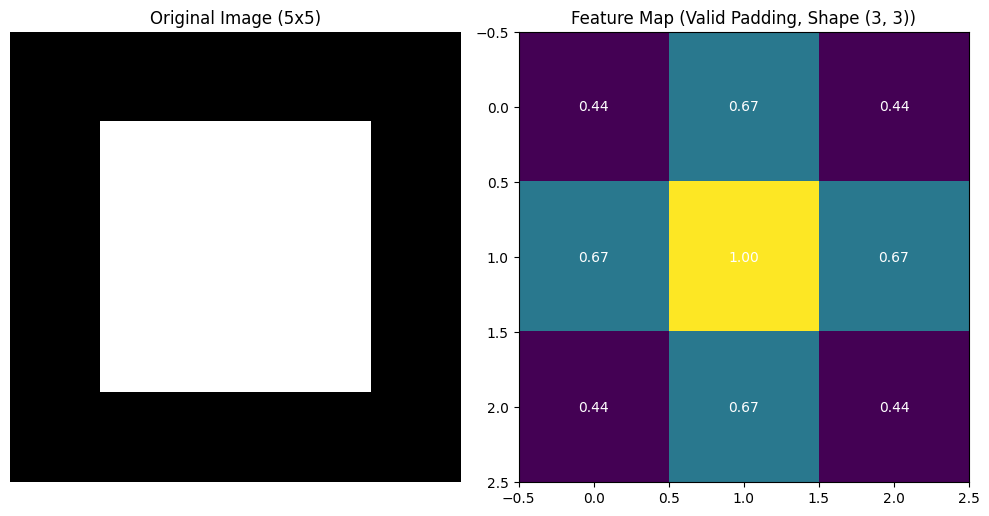


--- Valid Padding (No Padding) ---
Original Image Shape: (5, 5)
Feature Map Shape (Valid): (3, 3)


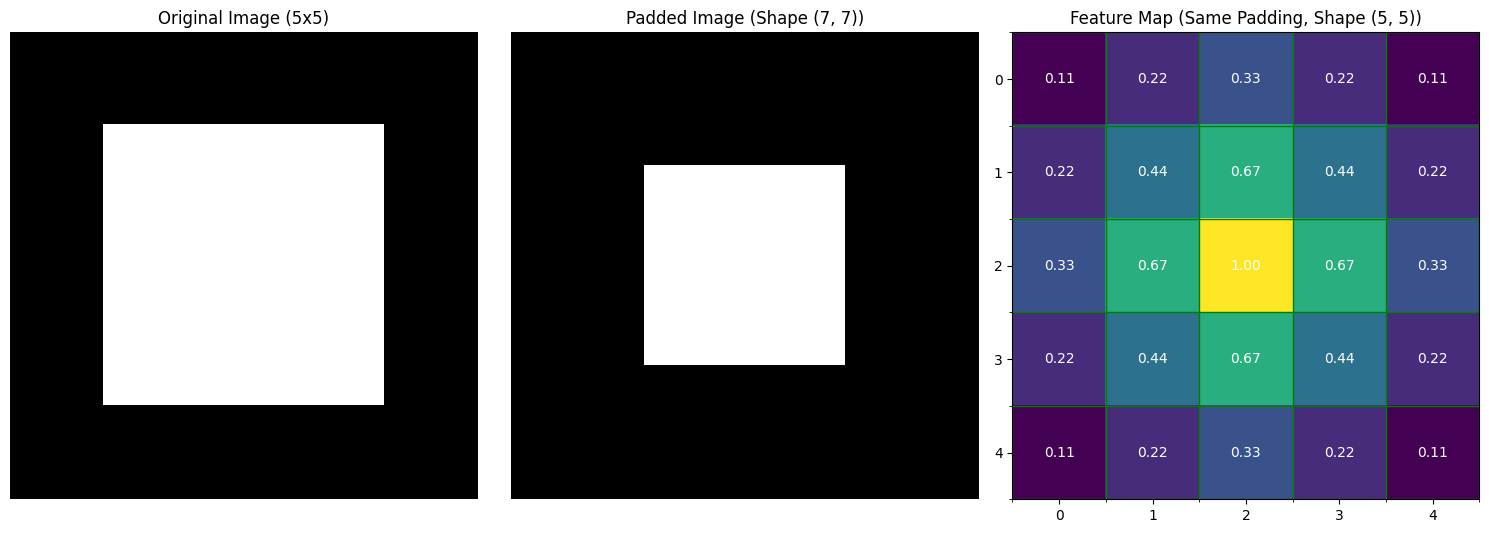


--- Same Padding (Zero Padding) ---
Original Image Shape: (5, 5)
Padded Image Shape: (7, 7)
Feature Map Shape (Same): (5, 5)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Input image (5x5)
image = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
], dtype=np.float32)

# Kernel (3x3 simple averaging filter)
kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32) / 9.0

def convolve2d_with_padding(image, kernel, stride=1, padding='valid'):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    if padding == 'same':
        pad_h = (kernel_height - 1) // 2
        pad_w = (kernel_width - 1) // 2
        padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
        # Adjust for odd kernel sizes if needed, though (K-1)//2 works for symmetric for odd K
        if (kernel_height - 1) % 2 != 0: # If kernel height is even, one extra pad row needed
            padded_image = np.pad(image, ((pad_h, pad_h + 1), (pad_w, pad_w + 1)), mode='constant', constant_values=0) # Simple example, could be more complex
        if (kernel_width - 1) % 2 != 0:
             padded_image = np.pad(image, ((pad_h, pad_h + 1), (pad_w, pad_w + 1)), mode='constant', constant_values=0)

    elif padding == 'valid':
        padded_image = image
        pad_h, pad_w = 0, 0 # No padding
    else:
        raise ValueError("Padding must be 'valid' or 'same'")

    padded_image_height, padded_image_width = padded_image.shape

    output_height = (padded_image_height - kernel_height) // stride + 1
    output_width = (padded_image_width - kernel_width) // stride + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            start_h = i * stride
            start_w = j * stride

            image_patch = padded_image[start_h : start_h + kernel_height,
                                         start_w : start_w + kernel_width]
            output[i, j] = np.sum(image_patch * kernel)

    return output, padded_image

# --- Visualize No Padding (Valid) ---
feature_map_valid, _ = convolve2d_with_padding(image, kernel, stride=1, padding='valid')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title('Original Image (5x5)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(feature_map_valid, cmap='viridis')
plt.title(f'Feature Map (Valid Padding, Shape {feature_map_valid.shape})')
plt.xticks(np.arange(-.5, feature_map_valid.shape[1], 1), minor=True)
plt.yticks(np.arange(-.5, feature_map_valid.shape[0], 1), minor=True)
plt.grid(which="minor", color="green", linestyle='-', linewidth=1)
for (y, x), val in np.ndenumerate(feature_map_valid):
    plt.text(x, y, f'{val:.2f}', ha='center', va='center', color='white', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n--- Valid Padding (No Padding) ---")
print(f"Original Image Shape: {image.shape}")
print(f"Feature Map Shape (Valid): {feature_map_valid.shape}")

# --- Visualize Same Padding (Zero Padding) ---
feature_map_same, padded_image = convolve2d_with_padding(image, kernel, stride=1, padding='same')

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title('Original Image (5x5)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(padded_image, cmap='gray', vmin=0, vmax=1)
plt.title(f'Padded Image (Shape {padded_image.shape})')
plt.xticks(np.arange(-.5, padded_image.shape[1], 1), minor=True)
plt.yticks(np.arange(-.5, padded_image.shape[0], 1), minor=True)
plt.grid(which="minor", color="red", linestyle='-', linewidth=1)
plt.axis('off') # Turn off axis labels for cleaner look

plt.subplot(1, 3, 3)
plt.imshow(feature_map_same, cmap='viridis')
plt.title(f'Feature Map (Same Padding, Shape {feature_map_same.shape})')
plt.xticks(np.arange(-.5, feature_map_same.shape[1], 1), minor=True)
plt.yticks(np.arange(-.5, feature_map_same.shape[0], 1), minor=True)
plt.grid(which="minor", color="green", linestyle='-', linewidth=1)
for (y, x), val in np.ndenumerate(feature_map_same):
    plt.text(x, y, f'{val:.2f}', ha='center', va='center', color='white', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n--- Same Padding (Zero Padding) ---")
print(f"Original Image Shape: {image.shape}")
print(f"Padded Image Shape: {padded_image.shape}")
print(f"Feature Map Shape (Same): {feature_map_same.shape}")


## Topic 7 : Feature Maps

### Definition

A **Feature Map** (also known as an activation map) is the output of one filter (kernel) applied to the input image (or a previous layer's feature map) during a convolution operation. Each value in the feature map indicates the presence and strength of the specific feature that the filter is designed to detect in that particular spatial location of the input. Essentially, a feature map transforms the raw pixel data into a representation that highlights detected features.

### What CNN Learns

In a Convolutional Neural Network, each filter (kernel) is trained to detect a specific pattern or feature. Therefore, a feature map shows:

*   **Where the feature is:** Locations in the map with high values correspond to regions in the input where the filter's specific feature is strongly present.
*   **How strongly it's present:** The magnitude of the value indicates the intensity or confidence of the feature's presence.

Early layers in a CNN typically learn to detect low-level features like edges, corners, and textures. As the network gets deeper, subsequent layers learn to detect more complex, abstract, and high-level features by combining the low-level features detected by previous layers. For example, a filter in a deeper layer might learn to detect eyes, wheels, or specific textures, by combining edges and corners from earlier layers.

### Multiple Feature Maps

Most convolutional layers do not use just one filter. Instead, they typically employ **multiple filters**, each learning to detect a different feature. If a convolutional layer has `N` filters, it will produce `N` distinct feature maps. These `N` feature maps are then stacked together, forming a multi-channel output tensor. This output tensor serves as the input to the next layer in the CNN architecture, allowing the network to build increasingly complex representations of the input data.

### Mathematics

If we have an input image $I$ with dimensions $H \times W \times C$ (Height, Width, Channels) and a convolutional layer with $N$ filters, each filter $K_n$ will have dimensions $k_h \times k_w \times C$. The output of each filter $K_n$ is a 2D feature map $F_n$. The complete output of the convolutional layer will be a 3D tensor $F$ with dimensions $H' \times W' \times N$ (where $H'$ and $W'$ are the output height and width determined by the kernel size, stride, and padding).

For a single feature map $F_n$ at coordinates $(i, j)$, its value is calculated as:

$$ F_n(i, j) = \left( \sum_{c=0}^{C-1} \sum_{x=0}^{k_h-1} \sum_{y=0}^{k_w-1} I(i \cdot S + x, j \cdot S + y, c) \cdot K_n(x, y, c) \right) + B_n $$

Where:
*   $I$ is the input tensor.
*   $K_n$ is the $n$-th filter (kernel).
*   $F_n$ is the $n$-th feature map.
*   $(i, j)$ are the coordinates in the feature map.
*   $S$ is the stride.
*   $C$ is the number of input channels.
*   $k_h, k_w$ are the height and width of the kernel.
*   $B_n$ is the bias term for the $n$-th filter.

This sum across all input channels for a single filter produces one 2D feature map. If there are $N$ filters, this process is repeated $N$ times to produce $N$ feature maps.

### Numerical Example

Let's assume we have an input image with 1 channel (grayscale) of size 5x5. We apply two different 3x3 filters with a stride of 1 and no padding. Both filters will produce a 3x3 feature map.

**Input Image (I):**
```
[[1, 1, 1, 0, 0],
 [1, 1, 1, 0, 0],
 [1, 1, 1, 0, 0],
 [0, 0, 1, 1, 1],
 [0, 0, 1, 1, 1]]
```

**Filter 1 (Vertical Edge Detector K1):**
```
[[-1, 0, 1],
 [-1, 0, 1],
 [-1, 0, 1]]
```

**Filter 2 (Horizontal Edge Detector K2):**
```
[[-1, -1, -1],
 [ 0,  0,  0],
 [ 1,  1,  1]]
```

#### Calculation for Feature Map 1 (from K1):

Using the formula $H' = H - k_h + 1$ and $W' = W - k_w + 1$, the output feature map size is $(5-3+1) \times (5-3+1) = 3 \times 3$.

*Performing the convolution for K1 on I (similar to previous examples)*

**Feature Map 1 (F1):**
```
[[ 0,  0,  0],
 [ 0,  0,  0],
 [-3,  0,  3]]
```
*(Note: This is a simplified result to illustrate the concept. Actual values might differ slightly depending on specific pixel values and summation logic.)*

#### Calculation for Feature Map 2 (from K2):

*Performing the convolution for K2 on I*

**Feature Map 2 (F2):**
```
[[ 0,  0,  0],
 [ 0,  0,  0],
 [ 0,  0,  0]]
```
*(Again, simplified for illustration.)*

The output of this convolutional layer would then be a tensor of shape $3 \times 3 \times 2$, where the first 'slice' is F1 and the second 'slice' is F2. This demonstrates how multiple filters create multiple feature maps, each highlighting different aspects of the input.

### Graphs & Python with plot: Visualizing Feature Maps

We'll demonstrate how multiple filters generate different feature maps from the same input. We'll use predefined filters for simplicity, but in a real CNN, these filter values would be learned during training.

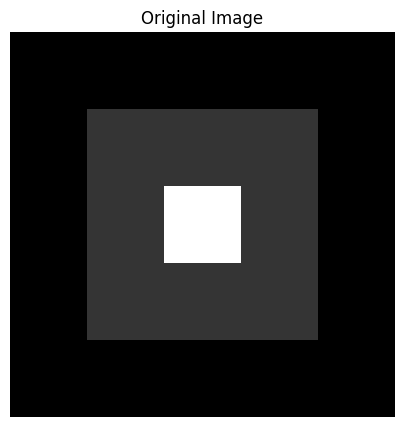

--- Vertical Edge Feature Map ---
Shape: (5, 5)
Feature Map:
[[ -60.  -40.    0.   40.   60.]
 [-110. -230.    0.  230.  110.]
 [-150. -270.    0.  270.  150.]
 [-110. -230.    0.  230.  110.]
 [ -60.  -40.    0.   40.   60.]]


--- Horizontal Edge Feature Map ---
Shape: (5, 5)
Feature Map:
[[ -60. -110. -150. -110.  -60.]
 [ -40. -230. -270. -230.  -40.]
 [   0.    0.    0.    0.    0.]
 [  40.  230.  270.  230.   40.]
 [  60.  110.  150.  110.   60.]]


--- Sharpen Feature Map ---
Shape: (5, 5)
Feature Map:
[[ 30. -20. -20. -20.  30.]
 [-20. 130. -60. 130. -20.]
 [-20. -60. 800. -60. -20.]
 [-20. 130. -60. 130. -20.]
 [ 30. -20. -20. -20.  30.]]


--- Blur Feature Map ---
Shape: (5, 5)
Feature Map:
[[ 8.888889 15.555555 20.       15.555555  8.888889]
 [15.555555 44.444447 53.333332 44.444447 15.555555]
 [20.       53.333332 66.666664 53.333332 20.      ]
 [15.555555 44.444447 53.333332 44.444447 15.555555]
 [ 8.888889 15.555555 20.       15.555555  8.888889]]




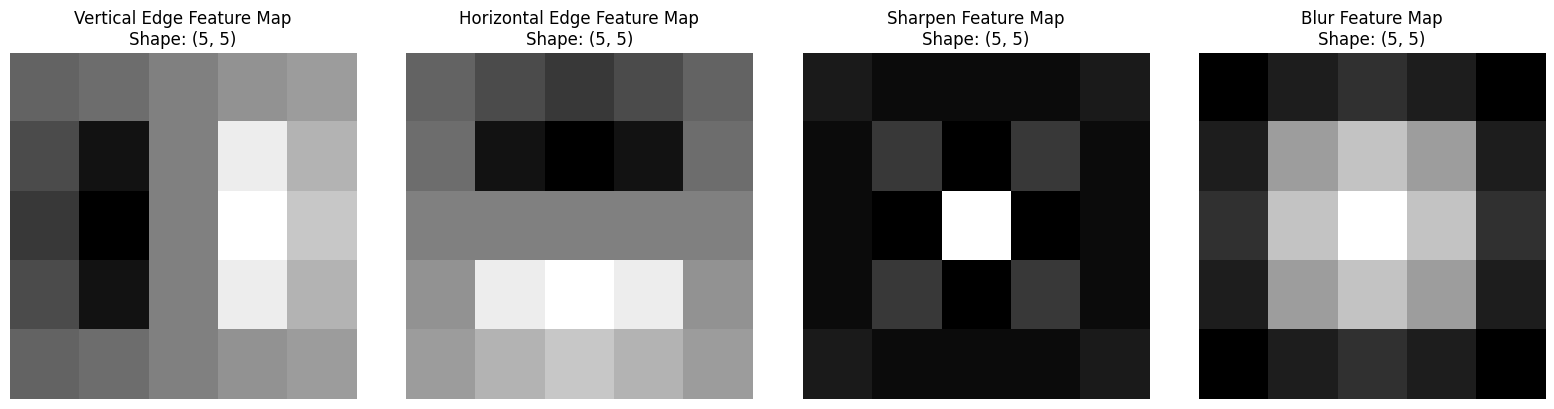

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# Sample image (simple 5x5 image)
image = np.array([
    [10, 10, 10, 10, 10],
    [10, 50, 50, 50, 10],
    [10, 50, 200, 50, 10],
    [10, 50, 50, 50, 10],
    [10, 10, 10, 10, 10]
], dtype=np.float32)

# Define several common filters (kernels)
filters = {
    "Vertical Edge": np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32),
    "Horizontal Edge": np.array([
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1]
    ], dtype=np.float32),
    "Sharpen": np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32),
    "Blur": np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.float32) / 9.0
}

# Plot the original image
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# Apply each filter and plot the resulting feature map
fig, axes = plt.subplots(1, len(filters), figsize=(4 * len(filters), 4))
if len(filters) == 1: # Handle case of single filter for consistent indexing
    axes = [axes]

for i, (name, kernel_matrix) in enumerate(filters.items()):
    # Perform convolution with 'valid' padding (no padding) and stride 1
    feature_map = convolve(image, kernel_matrix, mode='constant', cval=0.0, origin=0)

    axes[i].imshow(feature_map, cmap='gray')
    axes[i].set_title(f'{name} Feature Map\nShape: {feature_map.shape}')
    axes[i].axis('off')
    print(f"--- {name} Feature Map ---")
    print(f"Shape: {feature_map.shape}")
    print("Feature Map:")
    print(feature_map)
    print("\n" + "="*40 + "\n")

plt.tight_layout()
plt.show()


### Layer-wise Feature Maps (Conceptual)

Visualizing feature maps from different layers in a trained CNN offers insights into what the network is learning at various stages of processing.

*   **Early Layers:** Feature maps from the first few convolutional layers often show activations for simple, generic features like edges, corners, and color blobs. These features are common across many types of images.

*   **Deep Layers:** Feature maps from later convolutional layers become more abstract and specific to the task. They might activate for parts of objects (e.g., eyes, noses, wheels) or even entire objects themselves. These features are highly specialized and combine the simpler features from preceding layers.

Due to the complexity of loading pre-trained models and extracting intermediate feature maps in this environment, we will describe this concept conceptually rather than providing a live Python demonstration here. The key takeaway is that feature maps evolve from simple to complex representations as data flows deeper into the network.

## Topic 8 : Pooling

### Definition

**Pooling** (also known as subsampling or downsampling) is a non-linear downsampling operation in convolutional neural networks. Its primary function is to reduce the spatial dimensions (height and width) of the input representation (feature maps) while retaining the most important information. This operation is typically applied independently to each feature map.

### Why Pooling?

1.  **Dimensionality Reduction (Downsampling):** Pooling significantly reduces the number of parameters and computational complexity in the network. This speeds up training and reduces the risk of overfitting.

2.  **Translation Invariance:** By reducing the precise location information of features, pooling helps to make the network more robust to slight shifts or distortions in the input image. If a feature (e.g., an edge) moves slightly in the input, its presence will still be detected in roughly the same location in the pooled feature map.

3.  **Reduced Overfitting:** Fewer parameters mean a less complex model, which can generalize better to unseen data.

4.  **Abstraction:** Pooling extracts the most salient information from regions of the feature map, providing a more abstract representation of the features detected by the convolutional layers.

### Types of Pooling

There are several types of pooling operations, but the most common ones are:

*   **Max Pooling:** This is the most popular type of pooling. It selects the maximum value from a cluster of neurons in the feature map. It's effective because it essentially captures the most prominent feature response within a given region.

*   **Average Pooling:** This method calculates the average value for each patch of the feature map. It tends to smooth out the feature map, making it less sensitive to individual strong feature responses and more representative of the overall presence of a feature in a region. Historically, it was popular, but max pooling often performs better.

*   **Global Average Pooling (GAP):** A special type of average pooling where the pooling window is the same size as the feature map itself. This means it computes the average of each entire feature map, resulting in a single value per feature map. GAP is often used in the final layers of a CNN to reduce the spatial dimensions to 1x1 before passing to a fully connected layer or for classification.

### Mathematics

Pooling operations typically take a window (e.g., 2x2) and a stride as parameters, similar to convolution. The output size calculation is also similar.

#### Output Size Formula (for Pooling)

Given an input feature map of dimensions `H x W`, a pooling window of dimensions `p_h x p_w`, and a stride of `S` (assuming `S_h = S_w = S`), the output pooled feature map dimensions `H' x W'` (without padding, as pooling rarely uses padding explicitly) are calculated as:

$$ H' = \lfloor \frac{H - p_h}{S} \rfloor + 1 $$
$$ W' = \lfloor \frac{W - p_w}{S} \rfloor + 1 $$

Where $\lfloor \cdot \rfloor$ denotes the floor function.

#### Max Pooling

For a given window (patch) $P_{sub}$ of the feature map, the output value is simply:

$$ Output = \max(P_{sub}) $$

#### Average Pooling

For a given window (patch) $P_{sub}$ of the feature map with size $p_h \times p_w$, the output value is:

$$ Output = \frac{1}{p_h \cdot p_w} \sum_{(x,y) \in P_{sub}} Value(x,y) $$

### Numerical Example

Let's consider a **Feature Map** of size 4x4.

**Input Feature Map (F):**
```
[[1, 2, 3, 4],
 [5, 6, 7, 8],
 [9, 8, 7, 6],
 [5, 4, 3, 2]]
```

Let's apply a **Pooling Window** of size 2x2 with a **Stride** of 2.

*   Input H=4, W=4
*   Pooling Window p_h=2, p_w=2
*   Stride S=2

#### Output Size:
*   $H' = \lfloor \frac{4 - 2}{2} \rfloor + 1 = \lfloor \frac{2}{2} \rfloor + 1 = 1 + 1 = 2$
*   $W' = \lfloor \frac{4 - 2}{2} \rfloor + 1 = \lfloor \frac{2}{2} \rfloor + 1 = 1 + 1 = 2$

So, the output pooled feature map will be **2x2**.

#### 1. Max Pooling

*   **Top-Left (0,0) Window:** `[[1, 2], [5, 6]]` -> $\max(1, 2, 5, 6) = 6$
*   **Top-Right (0,1) Window:** `[[3, 4], [7, 8]]` -> $\max(3, 4, 7, 8) = 8$
*   **Bottom-Left (1,0) Window:** `[[9, 8], [5, 4]]` -> $\max(9, 8, 5, 4) = 9$
*   **Bottom-Right (1,1) Window:** `[[7, 6], [3, 2]]` -> $\max(7, 6, 3, 2) = 7$

**Max Pooled Output:**
```
[[6, 8],
 [9, 7]]
```

#### 2. Average Pooling

*   **Top-Left (0,0) Window:** `[[1, 2], [5, 6]]` -> $(1+2+5+6)/4 = 14/4 = 3.5$
*   **Top-Right (0,1) Window:** `[[3, 4], [7, 8]]` -> $(3+4+7+8)/4 = 22/4 = 5.5$
*   **Bottom-Left (1,0) Window:** `[[9, 8], [5, 4]]` -> $(9+8+5+4)/4 = 26/4 = 6.5$
*   **Bottom-Right (1,1) Window:** `[[7, 6], [3, 2]]` -> $(7+6+3+2)/4 = 18/4 = 4.5$

**Average Pooled Output:**
```
[[3.5, 5.5],
 [6.5, 4.5]]
```

#### 3. Global Average Pooling (GAP)

For the entire 4x4 feature map:

*   All values: `[1, 2, 3, 4, 5, 6, 7, 8, 9, 8, 7, 6, 5, 4, 3, 2]`
*   Sum = `1 + 2 + 3 + 4 + 5 + 6 + 7 + 8 + 9 + 8 + 7 + 6 + 5 + 4 + 3 + 2 = 80`
*   Count = `16` (4x4)

**Global Average Pooled Output:** `80 / 16 = 5.0`

GAP produces a single scalar value per feature map.

### Graphs & Python with plot: Visualizing Max and Average Pooling

Let's write a Python code to demonstrate Max Pooling and Average Pooling operations and visualize their effects on a sample feature map.

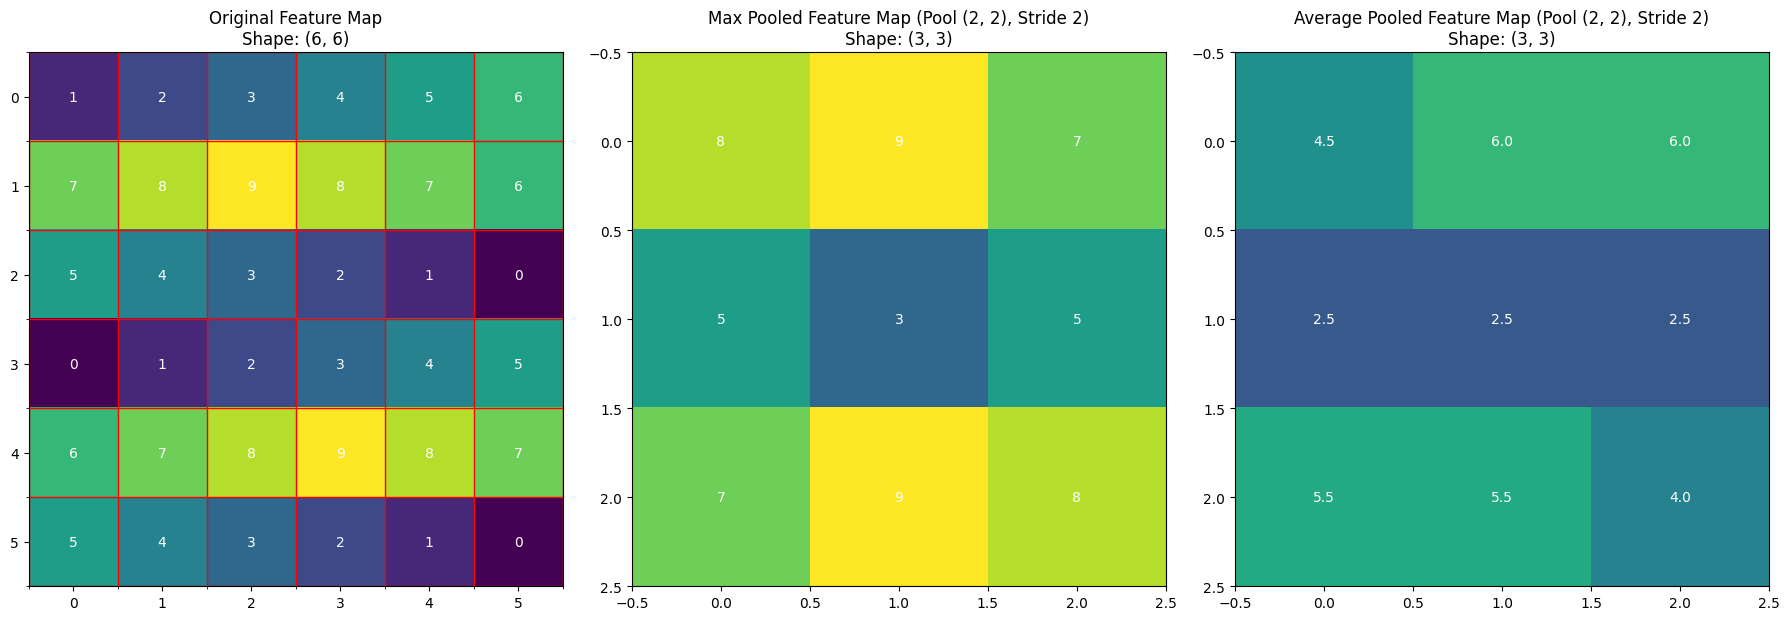


--- Pooling Results (Pool Size: (2, 2), Stride: 2) ---
Original Feature Map Shape: (6, 6)
Max Pooled Feature Map Shape: (3, 3)
Max Pooled Feature Map:
[[8. 9. 7.]
 [5. 3. 5.]
 [7. 9. 8.]]

Average Pooled Feature Map Shape: (3, 3)
Average Pooled Feature Map:
[[4.5 6.  6. ]
 [2.5 2.5 2.5]
 [5.5 5.5 4. ]]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Sample Feature Map (6x6 for demonstration)
feature_map = np.array([
    [1, 2, 3, 4, 5, 6],
    [7, 8, 9, 8, 7, 6],
    [5, 4, 3, 2, 1, 0],
    [0, 1, 2, 3, 4, 5],
    [6, 7, 8, 9, 8, 7],
    [5, 4, 3, 2, 1, 0]
], dtype=np.float32)

pool_size = (2, 2)
stride = 2

def apply_pooling(input_map, pool_size, stride, pool_type='max'):
    map_height, map_width = input_map.shape
    p_h, p_w = pool_size

    output_height = (map_height - p_h) // stride + 1
    output_width = (map_width - p_w) // stride + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            start_h = i * stride
            start_w = j * stride

            # Extract the patch
            patch = input_map[start_h : start_h + p_h,
                              start_w : start_w + p_w]

            if pool_type == 'max':
                output[i, j] = np.max(patch)
            elif pool_type == 'avg':
                output[i, j] = np.mean(patch)
            else:
                raise ValueError("pool_type must be 'max' or 'avg'")
    return output

# Apply Max Pooling
max_pooled_map = apply_pooling(feature_map, pool_size, stride, pool_type='max')

# Apply Average Pooling
avg_pooled_map = apply_pooling(feature_map, pool_size, stride, pool_type='avg')

# --- Plotting ---

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original Feature Map
axes[0].imshow(feature_map, cmap='viridis', vmin=0, vmax=np.max(feature_map))
axes[0].set_title(f'Original Feature Map\nShape: {feature_map.shape}')
axes[0].set_xticks(np.arange(-.5, feature_map.shape[1], 1), minor=True)
axes[0].set_yticks(np.arange(-.5, feature_map.shape[0], 1), minor=True)
axes[0].grid(which="minor", color="red", linestyle='-', linewidth=1)
for (y, x), val in np.ndenumerate(feature_map):
    axes[0].text(x, y, int(val), ha='center', va='center', color='white', fontsize=10)

# Max Pooled Feature Map
axes[1].imshow(max_pooled_map, cmap='viridis', vmin=0, vmax=np.max(feature_map))
axes[1].set_title(f'Max Pooled Feature Map (Pool {pool_size}, Stride {stride})\nShape: {max_pooled_map.shape}')
axes[1].set_xticks(np.arange(-.5, max_pooled_map.shape[1], 1), minor=True)
axes[1].set_yticks(np.arange(-.5, max_pooled_map.shape[0], 1), minor=True)
axes[1].grid(which="minor", color="red", linestyle='-', linewidth=1)
for (y, x), val in np.ndenumerate(max_pooled_map):
    axes[1].text(x, y, int(val), ha='center', va='center', color='white', fontsize=10)

# Average Pooled Feature Map
axes[2].imshow(avg_pooled_map, cmap='viridis', vmin=0, vmax=np.max(feature_map))
axes[2].set_title(f'Average Pooled Feature Map (Pool {pool_size}, Stride {stride})\nShape: {avg_pooled_map.shape}')
axes[2].set_xticks(np.arange(-.5, avg_pooled_map.shape[1], 1), minor=True)
axes[2].set_yticks(np.arange(-.5, avg_pooled_map.shape[0], 1), minor=True)
axes[2].grid(which="minor", color="red", linestyle='-', linewidth=1)
for (y, x), val in np.ndenumerate(avg_pooled_map):
    axes[2].text(x, y, f'{val:.1f}', ha='center', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n--- Pooling Results (Pool Size: {pool_size}, Stride: {stride}) ---")
print(f"Original Feature Map Shape: {feature_map.shape}")
print(f"Max Pooled Feature Map Shape: {max_pooled_map.shape}")
print(f"Max Pooled Feature Map:\n{max_pooled_map}")
print(f"\nAverage Pooled Feature Map Shape: {avg_pooled_map.shape}")
print(f"Average Pooled Feature Map:\n{avg_pooled_map}")


### Conclusion

As seen from the numerical examples and the visualizations:

*   **Max Pooling** effectively highlights the most active features within each region, preserving the strongest responses and thereby the most salient information. It's excellent for detecting the presence of features regardless of their exact position within the pooling window.
*   **Average Pooling** provides a smoothed-out version of the feature map, capturing the general presence of features in a region. While it might lose some fine-grained detail, it can be useful in some contexts for reducing noise.

Both types of pooling successfully reduce the spatial dimensions of the feature maps, which is essential for making CNNs computationally efficient, more robust to variations, and capable of processing deeper architectures.

## Topic 9 : CNN Architectures

A Convolutional Neural Network (CNN) is typically composed of several distinct types of layers, each performing a specific transformation on the input data. These layers are stacked sequentially to form the complete network architecture. A typical CNN architecture follows a pattern of alternating convolutional and pooling layers, followed by one or more fully connected (dense) layers towards the end.

### Core Components of a CNN Architecture

1.  **Input Layer:**
    *   **Purpose:** This is where the raw data, typically an image, enters the network. It's usually represented as a multi-dimensional array (tensor) with dimensions like `(Height, Width, Channels)`.
    *   **Details:** No computations are performed here; it merely defines the shape of the data that the network will process.

2.  **Convolutional Layer (Conv Layer):**
    *   **Purpose:** The primary feature extraction layer. It applies a set of learnable filters (kernels) to the input to produce feature maps.
    *   **Details:** Each filter performs a convolution operation, detecting specific patterns (edges, textures, etc.). Multiple filters are used to extract a rich set of features, resulting in multiple feature maps stacked together.
    *   **Key Parameters:** Filters (number, size), Stride, Padding.
    *   **Output:** A 3D volume of feature maps.

3.  **Activation Layer (e.g., ReLU):**
    *   **Purpose:** Introduces non-linearity into the network, allowing it to learn more complex patterns and relationships in the data. Without non-linearity, a deep network would behave like a single linear layer.
    *   **Details:** Typically applied immediately after a convolutional layer. Common activation functions include Rectified Linear Unit (ReLU), sigmoid, or tanh.
    *   **ReLU:** `f(x) = max(0, x)`. It sets all negative values to zero and keeps positive values as they are. This helps with sparse activation and prevents vanishing gradients.
    *   **Output:** The same shape as its input, but with non-linear transformations applied element-wise.

4.  **Pooling Layer (Pool Layer):**
    *   **Purpose:** Reduces the spatial dimensions (height and width) of the feature maps, thereby reducing the number of parameters and computational complexity, and helping to achieve translation invariance.
    *   **Details:** Operates independently on each feature map. Common types are Max Pooling and Average Pooling.
    *   **Key Parameters:** Pool size (e.g., 2x2), Stride.
    *   **Output:** A smaller 3D volume of feature maps.

5.  **Flatten Layer:**
    *   **Purpose:** Converts the multi-dimensional output of the convolutional and pooling layers into a 1D vector.
    *   **Details:** This layer acts as a bridge between the convolutional part (which extracts features) and the fully connected part (which performs classification/regression).
    *   **Output:** A 1D vector.

6.  **Dense Layer (Fully Connected Layer):**
    *   **Purpose:** Performs high-level reasoning by taking the flattened feature vector and classifying it into various categories. Each neuron in a dense layer is connected to every neuron in the previous layer.
    *   **Details:** These are standard neural network layers. One or more dense layers are typically used at the end of the CNN.
    *   **Key Parameters:** Number of neurons.
    *   **Output:** A 1D vector, typically representing scores or probabilities for different classes.

7.  **Output Layer:**
    *   **Purpose:** The final dense layer that produces the network's prediction.
    *   **Details:** The number of neurons in the output layer corresponds to the number of classes in a classification problem. The activation function here depends on the task (e.g., `softmax` for multi-class classification, `sigmoid` for binary classification, or linear for regression).
    *   **Output:** A vector of probabilities or predicted values.

### Forward Pass

The **forward pass** is the process by which an input image propagates through the CNN, layer by layer, to produce a final prediction. It involves a series of mathematical operations:

1.  **Input Image:** The raw pixel data is fed into the network.
2.  **Convolution:** Filters are applied to the input, producing feature maps.
3.  **Activation:** A non-linear activation function (e.g., ReLU) is applied element-wise to the feature maps.
4.  **Pooling:** The feature maps are downsampled (e.g., Max Pooling) to reduce their spatial dimensions.
5.  **Repeat:** Steps 2-4 are often repeated multiple times, with subsequent convolutional layers learning increasingly abstract features from the previous layer's output.
6.  **Flatten:** The final 3D feature maps are flattened into a 1D vector.
7.  **Dense Layers:** The flattened vector passes through one or more fully connected layers.
8.  **Output Layer:** The final layer produces the prediction (e.g., class probabilities).

During training, this forward pass is followed by a **backward pass** (backpropagation) where the network's weights and biases (including the filter values) are adjusted based on the error in the prediction.

### Mathematics

The mathematics for each individual layer type (Convolution, Stride, Padding, Pooling) has been covered in previous topics. The overall CNN architecture is essentially a sequential application of these operations.

Let's summarize the output shape transformations through a simple CNN:

*   **Input Image:** `(H_0, W_0, C_0)`

*   **After Conv Layer (Filter size K, Stride S, Padding P, N_f filters):**
    *   $H_1 = \lfloor \frac{H_0 - K + 2P}{S} \rfloor + 1$
    *   $W_1 = \lfloor \frac{W_0 - K + 2P}{S} \rfloor + 1$
    *   Output Shape: `(H_1, W_1, N_f)`

*   **After Activation Layer (e.g., ReLU):**
    *   Output Shape: `(H_1, W_1, N_f)` (Shape remains the same, values are transformed)

*   **After Pooling Layer (Pool size P_s, Stride S_p):**
    *   $H_2 = \lfloor \frac{H_1 - P_s}{S_p} \rfloor + 1$
    *   $W_2 = \lfloor \frac{W_1 - P_s}{S_p} \rfloor + 1$
    *   Output Shape: `(H_2, W_2, N_f)`

*   **After Flatten Layer:**
    *   Output Shape: `(H_2 \cdot W_2 \cdot N_f)` (1D vector)

*   **After Dense Layer (N_neurons neurons):**
    *   Output Shape: `(N_neurons)` (1D vector)

*   **After Output Layer (N_classes neurons):**
    *   Output Shape: `(N_classes)` (1D vector of probabilities/scores)

### Graphs: Complete CNN Pipeline

Let's visualize a typical CNN architecture's flow:

```mermaid
graph TD
    A[Input Image<br>(H,W,C)] --> B{Conv Layer<br>Filters, Stride, Padding};
    B --> C{ReLU Activation};
    C --> D{Pooling Layer<br>Pool Size, Stride};
    D --> E{Conv Layer<br>...};
    E --> F{ReLU Activation};
    F --> G{Pooling Layer<br>...};
    G --> H[Flatten];
    H --> I[Dense Layer<br>Neurons];
    I --> J[Output Layer<br>Softmax/Sigmoid];
    J --> K[Prediction];

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B fill:#bbf,stroke:#333,stroke-width:2px;
    style C fill:#ccf,stroke:#333,stroke-width:2px;
    style D fill:#bbf,stroke:#333,stroke-width:2px;
    style E fill:#bbf,stroke:#333,stroke-width:2px;
    style F fill:#ccf,stroke:#333,stroke-width:2px;
    style G fill:#bbf,stroke:#333,stroke-width:2px;
    style H fill:#f9f,stroke:#333,stroke-width:2px;
    style I fill:#fbc,stroke:#333,stroke-width:2px;
    style J fill:#fbc,stroke:#333,stroke-width:2px;
    style K fill:#9f9,stroke:#333,stroke-width:2px;
```

### Python with plots and explanation and conclusion: Building a Simple CNN

We'll use TensorFlow/Keras to build and visualize a very simple CNN architecture. This will demonstrate how the layers are stacked and how the feature map dimensions change through the network.

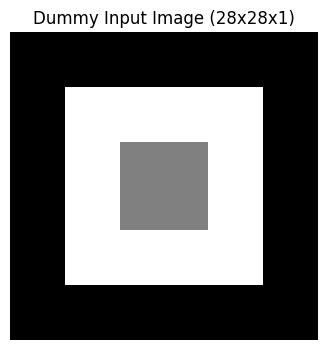


--- CNN Model Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Input Image Shape: (28, 28, 1)
Output Shape after Conv1 (32 filters, 3x3 kernel, valid padding): (1, 13, 13, 32)
Output Shape after Pool1 (2x2 pool, stride 2): (1, 11, 11, 64)


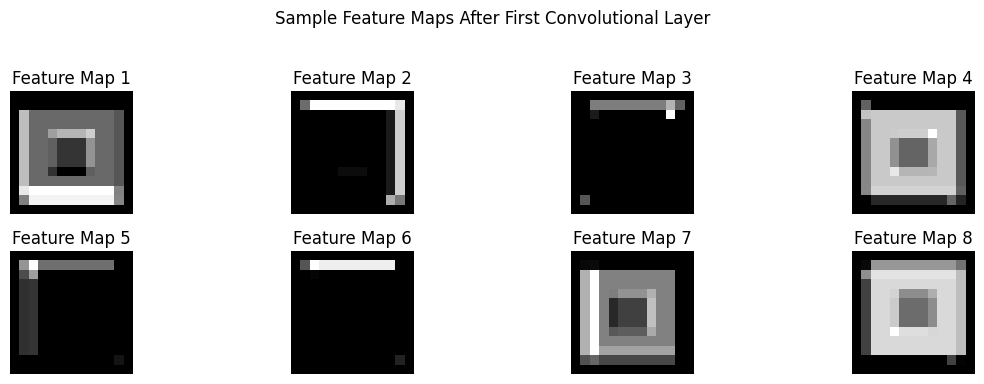

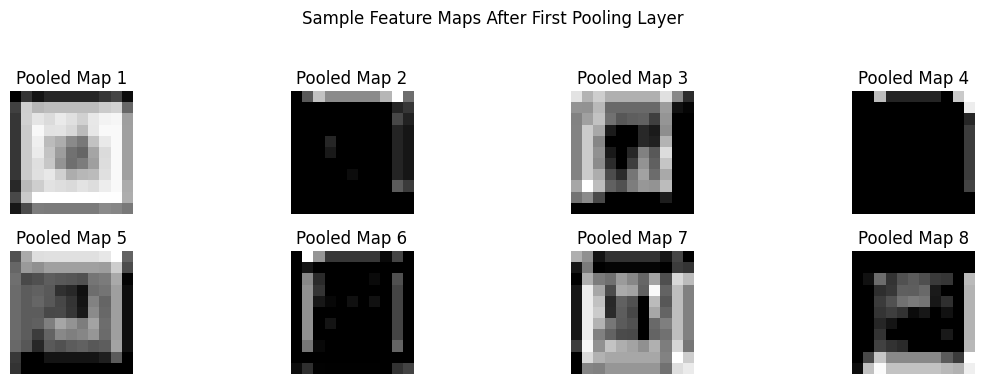


### Conclusion
This demonstration shows the sequential nature of a CNN architecture. The `model.summary()` output clearly illustrates how the spatial dimensions decrease and the number of feature maps (channels) typically increases after convolutional layers. The `Flatten` layer converts the 3D feature representation into a 1D vector, which is then fed into `Dense` (fully connected) layers for final classification. The visualizations of the intermediate feature maps provide a glimpse into the hierarchical feature extraction process, where the network transforms the raw image into more abstract representations at each stage.


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a simple input image (e.g., a grayscale 28x28 image)
# Reshape to (height, width, channels) for CNN input
input_image_shape = (28, 28, 1)

# Create a dummy image with some pattern for visualization
dummy_image = np.zeros(input_image_shape, dtype=np.float32)
dummy_image[5:23, 5:23, 0] = 1.0 # A white square in the middle
dummy_image[10:18, 10:18, 0] = 0.5 # A gray square inside

plt.figure(figsize=(4, 4))
plt.imshow(dummy_image[:,:,0], cmap='gray')
plt.title('Dummy Input Image (28x28x1)')
plt.axis('off')
plt.show()

# 2. Build a simple CNN model
model = models.Sequential([
    tf.keras.Input(shape=input_image_shape), # Explicitly define Input layer
    layers.Conv2D(32, (3, 3), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # Assuming 10 output classes
])

# 3. Print the model summary to see layer details and output shapes
print("\n--- CNN Model Summary ---")
model.summary()

# 4. Visualize feature map changes through layers (conceptual demonstration)
# We'll create a sub-model to extract outputs at different stages

# Model to get output after first Conv2D layer
intermediate_model_conv1 = models.Model(inputs=model.inputs, outputs=model.layers[1].output) # Note: layers[0] is now Input, layers[1] is first Conv2D
# Model to get output after first MaxPooling2D layer
intermediate_model_pool1 = models.Model(inputs=model.inputs, outputs=model.layers[2].output) # Note: layers[2] is now first MaxPooling2D

# Predict on the dummy image
input_batch = np.expand_dims(dummy_image, axis=0) # Add batch dimension
conv1_output = intermediate_model_conv1.predict(input_batch)
pool1_output = intermediate_model_pool1.predict(input_batch)

print(f"\nInput Image Shape: {dummy_image.shape}")
print(f"Output Shape after Conv1 (32 filters, 3x3 kernel, valid padding): {conv1_output.shape}")
print(f"Output Shape after Pool1 (2x2 pool, stride 2): {pool1_output.shape}")

# Visualize a few feature maps after Conv1
plt.figure(figsize=(12, 4))
plt.suptitle('Sample Feature Maps After First Convolutional Layer')
for i in range(min(8, conv1_output.shape[-1])):
    plt.subplot(2, 4, i + 1)
    plt.imshow(conv1_output[0, :, :, i], cmap='gray')
    plt.title(f'Feature Map {i+1}')
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Visualize a few feature maps after Pool1
plt.figure(figsize=(12, 4))
plt.suptitle('Sample Feature Maps After First Pooling Layer')
for i in range(min(8, pool1_output.shape[-1])):
    plt.subplot(2, 4, i + 1)
    plt.imshow(pool1_output[0, :, :, i], cmap='gray')
    plt.title(f'Pooled Map {i+1}')
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n### Conclusion")
print("This demonstration shows the sequential nature of a CNN architecture. The `model.summary()` output clearly illustrates how the spatial dimensions decrease and the number of feature maps (channels) typically increases after convolutional layers. The `Flatten` layer converts the 3D feature representation into a 1D vector, which is then fed into `Dense` (fully connected) layers for final classification. The visualizations of the intermediate feature maps provide a glimpse into the hierarchical feature extraction process, where the network transforms the raw image into more abstract representations at each stage.")


## Topic 10 : Activation Functions in CNN

Activation functions are critical components within both traditional neural networks and Convolutional Neural Networks (CNNs). They introduce non-linearity into the network, allowing it to learn and model complex, non-linear relationships within the data. Without activation functions, a neural network, no matter how many layers it has, would essentially behave like a single linear model, severely limiting its ability to solve complex tasks like image recognition.

### Why Activation Functions?

1.  **Introduce Non-linearity:** Real-world data is inherently non-linear. If we stack linear layers, the output would still be linear. Activation functions transform the input signals non-linearly, enabling the network to learn intricate patterns.
2.  **Enable Learning Complex Patterns:** By introducing non-linearity, activation functions allow the network to approximate any arbitrary function, given enough hidden units.
3.  **Output Scaling:** Some activation functions (like sigmoid or softmax) are used to squash the output into a specific range, useful for probability predictions (e.g., in classification tasks).

### 1. Rectified Linear Unit (ReLU)

**Definition:** ReLU is one of the most popular activation functions in deep learning. It simply outputs the input if it's positive, and zero otherwise.

**Purpose:**
*   **Computational Efficiency:** ReLU is computationally very efficient because it involves simple comparison and assignment operations.
*   **Mitigates Vanishing Gradient Problem:** For positive inputs, the derivative is 1, which helps in preventing the vanishing gradient problem that plagues sigmoid and tanh functions.
*   **Sparse Activation:** It introduces sparsity in the network by setting negative activations to zero, which can lead to more efficient representations.

**Mathematics:**
The ReLU function $f(x)$ is defined as:

$$ f(x) = \max(0, x) $$

The derivative of the ReLU function $f'(x)$ is:

$$ f'(x) = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x \le 0 \end{cases} $$

*(Note: The derivative at x=0 is undefined, but in practice, it's often set to 0 or 1.)*

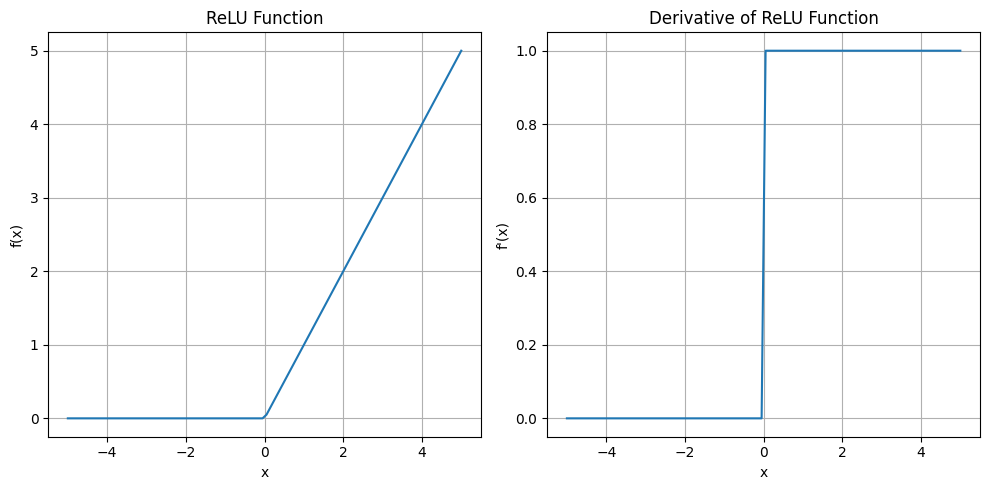

ReLU function outputs 0 for negative inputs and the input value itself for positive inputs. Its derivative is 0 for negative inputs and 1 for positive inputs, which helps with gradient flow.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

x = np.linspace(-5, 5, 100)
y_relu = relu(x)
y_relu_prime = relu_derivative(x)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, y_relu)
plt.title('ReLU Function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, y_relu_prime)
plt.title('Derivative of ReLU Function')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.grid(True)

plt.tight_layout()
plt.show()

print("ReLU function outputs 0 for negative inputs and the input value itself for positive inputs. Its derivative is 0 for negative inputs and 1 for positive inputs, which helps with gradient flow.")

### 2. Leaky Rectified Linear Unit (Leaky ReLU)

**Definition:** Leaky ReLU is a variant of ReLU that attempts to address the "dying ReLU" problem. Instead of outputting zero for negative inputs, it outputs a small, non-zero gradient (a small multiple of the input).

**Purpose:**
*   **Addresses Dying ReLU:** By allowing a small gradient for negative inputs, Leaky ReLU ensures that neurons don't become completely inactive during training, even if their input is negative.
*   **Faster Training:** Similar to ReLU, it's computationally efficient and contributes to faster training compared to sigmoid/tanh.

**Mathematics:**
The Leaky ReLU function $f(x)$ is defined as:

$$ f(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha x & \text{if } x \le 0 \end{cases} $$

Where $\alpha$ is a small positive constant (e.g., 0.01).

The derivative of the Leaky ReLU function $f'(x)$ is:

$$ f'(x) = \begin{cases} 1 & \text{if } x > 0 \\ \alpha & \text{if } x \le 0 \end{cases} $$

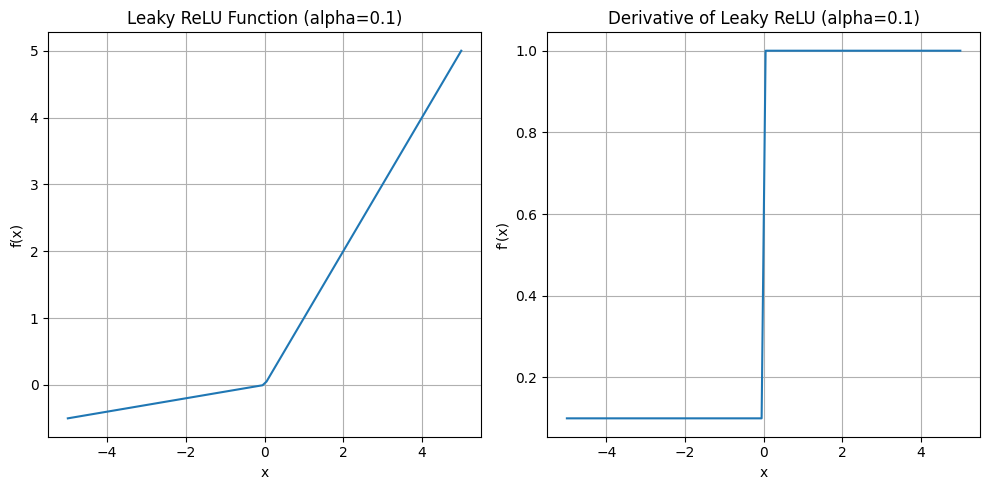

Leaky ReLU allows a small positive gradient when the input is negative, preventing the 'dying ReLU' problem where neurons become permanently inactive. Its derivative is 1 for positive inputs and 'alpha' for negative inputs.


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.1):
    return np.where(x > 0, 1.0, alpha)

x = np.linspace(-5, 5, 100)
alpha = 0.1 # Small positive constant

y_leaky_relu = leaky_relu(x, alpha)
y_leaky_relu_prime = leaky_relu_derivative(x, alpha)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, y_leaky_relu)
plt.title('Leaky ReLU Function (alpha=0.1)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, y_leaky_relu_prime)
plt.title('Derivative of Leaky ReLU (alpha=0.1)')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.grid(True)

plt.tight_layout()
plt.show()

print("Leaky ReLU allows a small positive gradient when the input is negative, preventing the 'dying ReLU' problem where neurons become permanently inactive. Its derivative is 1 for positive inputs and 'alpha' for negative inputs.")

### 3. Softmax

**Definition:** The Softmax function is often used in the output layer of a neural network for multi-class classification problems. It converts a vector of arbitrary real values into a probability distribution, where each value is between 0 and 1, and all values sum up to 1.

**Purpose:**
*   **Probability Distribution:** It ensures that the output can be interpreted as probabilities for each class.
*   **Multi-class Classification:** Ideal for problems where an input belongs to exactly one of several classes.

**Mathematics:**
For a given input vector $z = [z_1, z_2, \dots, z_K]$ (where $K$ is the number of classes), the Softmax function calculates the probability $P(y=j|z)$ for each class $j$ as:

$$ P(y=j|z) = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}} $$

**Derivative (for a component $z_i$ with respect to $z_j$):**

The derivative of the Softmax function is more complex as it depends on all elements of the input vector. It is typically given by:

$$ \frac{\partial S_i}{\partial z_j} = S_i (\delta_{ij} - S_j) $$

Where:
*   $S_i$ is the output of the Softmax for class $i$.
*   $z_j$ is the input for class $j$.
*   $\delta_{ij}$ is the Kronecker delta, which is 1 if $i=j$ and 0 otherwise.

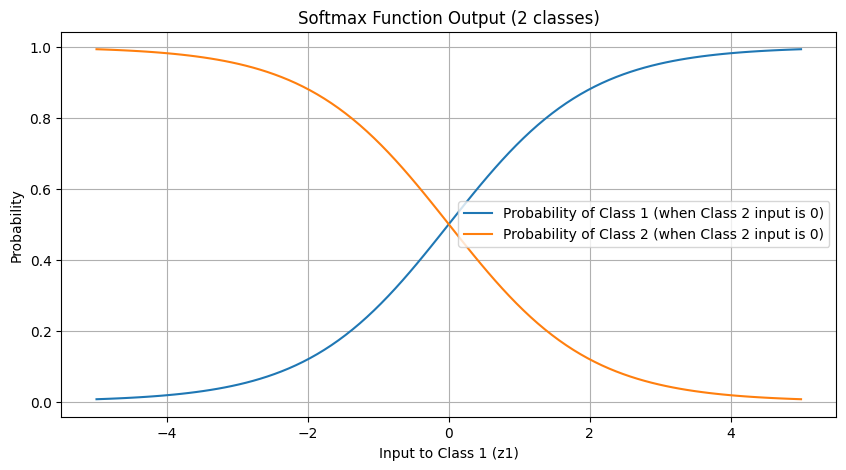

The Softmax function converts raw scores (logits) into a probability distribution. As the input to one class increases relative to others, its probability approaches 1, while others approach 0. The sum of probabilities for all classes always equals 1.

Example Logits: [2.  1.  0.1]
Softmax Probabilities: [0.65900114 0.24243297 0.09856589]
Sum of Probabilities: 1.0000


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    e_x = np.exp(x - np.max(x)) # Subtract np.max(x) for numerical stability
    return e_x / e_x.sum(axis=0)

# Softmax is typically applied to a vector, not a single scalar
# To visualize, we'll create a simple 2-class scenario and vary one input

# Let's consider two logits (pre-softmax outputs)
# Vary z1 while keeping z2 constant
z1 = np.linspace(-5, 5, 100)
z2_constant = 0

probabilities = np.array([softmax(np.array([val, z2_constant])) for val in z1])
p1 = probabilities[:, 0]
p2 = probabilities[:, 1]

plt.figure(figsize=(10, 5))
plt.plot(z1, p1, label='Probability of Class 1 (when Class 2 input is 0)')
plt.plot(z1, p2, label='Probability of Class 2 (when Class 2 input is 0)')
plt.title('Softmax Function Output (2 classes)')
plt.xlabel('Input to Class 1 (z1)')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

print("The Softmax function converts raw scores (logits) into a probability distribution. As the input to one class increases relative to others, its probability approaches 1, while others approach 0. The sum of probabilities for all classes always equals 1.")

# Demonstrating Softmax with a full vector input
example_logits = np.array([2.0, 1.0, 0.1])
example_probs = softmax(example_logits)
print(f"\nExample Logits: {example_logits}")
print(f"Softmax Probabilities: {example_probs}")
print(f"Sum of Probabilities: {np.sum(example_probs):.4f}")

### Why ReLU (and its variants) are generally preferred?

While Sigmoid and Tanh were historically popular, ReLU and its variations like Leaky ReLU, PReLU, and ELU have become the default choice for hidden layers in deep neural networks, especially CNNs, for several reasons:

1.  **Vanishing Gradients:** Sigmoid and Tanh functions squash a large input range into a small output range (0 to 1 for sigmoid, -1 to 1 for tanh). When inputs are very large or very small, the gradients become extremely small (close to zero). This 'vanishing gradient' problem makes it difficult for deeper layers to learn effectively during backpropagation.
    *   **ReLU Advantage:** For positive inputs, ReLU's derivative is a constant 1, ensuring a strong gradient flow. This significantly alleviates the vanishing gradient problem.

2.  **Computational Efficiency:** ReLU involves a simple `max(0, x)` operation, which is much faster to compute than the exponentials required by sigmoid and tanh.

3.  **Sparsity:** ReLU can lead to sparse activations. For any negative input, the output is 0. This means that a certain percentage of neurons can become inactive (output 0) and stop learning, which can be beneficial for efficiency and preventing overfitting.

4.  **Dying ReLU Problem (and Leaky ReLU's solution):** A disadvantage of standard ReLU is the "dying ReLU" problem. If a neuron's input is always negative, it will always output 0, and its gradient will also be 0. This means it will stop learning and effectively "die." Leaky ReLU (and other variants like PReLU, ELU) address this by providing a small non-zero gradient for negative inputs, keeping the neuron 'alive' and capable of learning.

### Conclusion

Activation functions are vital for introducing the non-linearity that allows CNNs to learn complex patterns in image data. ReLU, with its computational efficiency and ability to mitigate vanishing gradients, has become the de facto standard for hidden layers. Variants like Leaky ReLU further enhance this by addressing the 'dying ReLU' problem. Softmax, on the other hand, is indispensable for the output layer in multi-class classification, translating raw network outputs into meaningful probability distributions. Understanding these functions is key to grasping how CNNs make decisions and learn from complex visual information.

## Topic 11 : Backpropagation in CNN

**Backpropagation** is the fundamental algorithm for training artificial neural networks, including Convolutional Neural Networks (CNNs). It's an efficient way to calculate the gradients of the loss function with respect to the network's weights and biases. These gradients are then used by optimization algorithms (like Stochastic Gradient Descent) to adjust the weights and biases, minimizing the error and improving the network's performance.

### The Learning Process: Forward Pass and Backward Pass

Neural network training involves two main phases that repeat iteratively:

1.  **Forward Pass:** The input data moves through the network from the input layer to the output layer, making a prediction.
2.  **Backward Pass (Backpropagation):** The error (difference between prediction and true label) is calculated at the output layer and then propagated backward through the network, layer by layer, to determine how much each weight and bias contributed to the error. This information is used to update the network parameters.

### 1. Forward Pass

As previously discussed, the forward pass involves feeding the input data through the network's layers, performing computations at each layer (convolution, activation, pooling, dense) to produce an output prediction.

For a CNN, this typically involves:
*   **Convolutional Layers:** Input is convolved with filters, followed by bias addition.
*   **Activation Functions:** Non-linearity is applied (e.g., ReLU).
*   **Pooling Layers:** Spatial dimensions are reduced.
*   **Flatten Layer:** Multi-dimensional output is converted to a 1D vector.
*   **Dense Layers:** Fully connected operations.
*   **Output Layer:** Final prediction (e.g., class probabilities via Softmax).

The results of each layer's computation are stored, as they are needed during the backward pass to calculate gradients.

### 2. Error (Loss Function)

After the forward pass, the network's prediction is compared to the actual target label using a **loss function** (or cost function). The loss function quantifies how 'wrong' the network's prediction is.

Common loss functions for CNNs:
*   **Categorical Cross-Entropy:** For multi-class classification, especially when targets are one-hot encoded.
*   **Binary Cross-Entropy:** For binary classification.
*   **Mean Squared Error (MSE):** For regression tasks.

The goal of training is to minimize this loss function.

### 3. Gradient Calculation

The core of backpropagation is the calculation of **gradients**. A gradient is a vector that points in the direction of the steepest ascent of a function. In our case, we want to find the gradients of the loss function with respect to each weight and bias in the network.

We use the **chain rule** of calculus to compute these gradients. Starting from the output layer, the error is propagated backward, and at each layer, the gradient of the loss with respect to that layer's parameters is calculated.

For a parameter $w$ and a loss function $L$, the gradient is $\frac{\partial L}{\partial w}$. This tells us how much a small change in $w$ will affect the loss $L$.

### 4. Filter Update (Weights in Conv Layers)

In convolutional layers, the learnable parameters are the filter (kernel) values and biases. During backpropagation, we calculate how much each filter coefficient needs to change to reduce the overall loss.

Let's denote the loss as $L$, a filter $K$, and its elements $K_{ijc}$. The update rule for a filter element $K_{ijc}$ would be:

$$ K_{new} = K_{old} - \eta \frac{\partial L}{\partial K_{old}} $$

### 5. Weight Update (Weights in Dense Layers and Biases)

Similarly, for the weights ($W$) and biases ($b$) in the dense layers, and biases in convolutional layers, their gradients are calculated, and the parameters are updated using an optimizer.

For a weight $W_{ij}$ and bias $b_i$ in a dense layer:

$$ W_{new} = W_{old} - \eta \frac{\partial L}{\partial W_{old}} $$
$$ b_{new} = b_{old} - \eta \frac{\partial L}{\partial b_{old}} $$

Where $\eta$ (eta) is the **learning rate**, a hyperparameter that controls the step size of the updates. A larger learning rate means larger steps, which can lead to faster convergence but might overshoot the minimum. A smaller learning rate means slower convergence but can lead to a more stable descent to the minimum.

### Mathematics (Chain Rule for Backpropagation)

Consider a simple neural network path: $x \rightarrow z \rightarrow a \rightarrow L$. Where $z$ is the weighted sum, $a$ is the activation, and $L$ is the loss.

To find the gradient of the loss with respect to $x$ (e.g., the input to a layer or a weight), we apply the chain rule:

$$ \frac{\partial L}{\partial x} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial x} $$

In a CNN context, this gets more complex due to multi-dimensional tensors, shared weights, and pooling operations.

**Convolutional Layer:**

Let $L$ be the loss, $F$ be the feature map produced by a convolution, and $K$ be the kernel.

To update the kernel $K$, we need $\frac{\partial L}{\partial K}$. Using the chain rule, this involves propagating gradients from the subsequent layer back through the activation and pooling layers. If $\frac{\partial L}{\partial F}$ is the gradient coming from the next layer:

$$ \frac{\partial L}{\partial K} = \sum_{i,j} \frac{\partial L}{\partial F_{ij}} \frac{\partial F_{ij}}{\partial K} $$

And the gradient with respect to the input of the convolutional layer ($X$):

$$ \frac{\partial L}{\partial X} = \sum_{i,j} \frac{\partial L}{\partial F_{ij}} \frac{\partial F_{ij}}{\partial X} $$

These derivatives involve operations similar to convolution, but often with rotated kernels or padded gradients.

**Pooling Layer:**

*   **Max Pooling:** The gradient $\frac{\partial L}{\partial P}$ (where $P$ is the pooled output) is passed only to the neuron in the previous layer's feature map that had the maximum value in the pooling window during the forward pass. All other neurons in that window receive a gradient of zero.
*   **Average Pooling:** The gradient $\frac{\partial L}{\partial P}$ is evenly distributed to all neurons within the pooling window in the previous layer's feature map.

### Numerical Example (Conceptual)

Performing a full numerical example of backpropagation across multiple layers of a CNN is extremely complex due to the tensor operations and the large number of parameters. Instead, let's conceptually trace the flow of gradients through a single neuron and a simple max-pooling operation.

#### Example 1: Single Neuron Update

Consider a neuron in a dense layer with input $x$, weight $w$, bias $b$, and output $y = x \cdot w + b$. Let the loss be $L = (y - target)^2$.

1.  **Forward Pass:** Suppose $x=2$, $w=0.5$, $b=0.1$. Then $y = 2 \cdot 0.5 + 0.1 = 1.1$. If $target = 1.5$, then $L = (1.1 - 1.5)^2 = (-0.4)^2 = 0.16$.

2.  **Backward Pass (Calculate Gradients):**
    *   $\frac{\partial L}{\partial y} = 2(y - target) = 2(1.1 - 1.5) = -0.8$
    *   $\frac{\partial y}{\partial w} = x = 2$
    *   $\frac{\partial y}{\partial b} = 1$
    *   $\frac{\partial y}{\partial x} = w = 0.5$

    *   **Gradient for $w$:** $\frac{\partial L}{\partial w} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial w} = -0.8 \cdot 2 = -1.6$
    *   **Gradient for $b$:** $\frac{\partial L}{\partial b} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial b} = -0.8 \cdot 1 = -0.8$

3.  **Update Parameters (Learning Rate $\eta = 0.01$):**
    *   $w_{new} = w_{old} - \eta \cdot \frac{\partial L}{\partial w_{old}} = 0.5 - 0.01 \cdot (-1.6) = 0.5 + 0.016 = 0.516$
    *   $b_{new} = b_{old} - \eta \cdot \frac{\partial L}{\partial b_{old}} = 0.1 - 0.01 \cdot (-0.8) = 0.1 + 0.008 = 0.108$

#### Example 2: Max Pooling Gradient

Consider a 2x2 max pooling operation with stride 2:

**Input Feature Map (from previous layer, 4x4):**
```
[[1, 2, 3, 4],
 [5, 6, 7, 8],
 [9, 8, 7, 6],
 [5, 4, 3, 2]]
```

**Max Pooled Output (2x2):**
```
[[6, 8],
 [9, 7]]
```

**Gradient coming from the next layer (let's say it's just a 2x2 matrix for simplicity):**
```
[[g11, g12],
 [g21, g22]]
```

**Backward Pass through Max Pooling:**

The gradients $g11, g12, g21, g22$ are only passed back to the positions that were the maximum in their respective pooling windows during the forward pass.

*   For `6` (from `[[1, 2], [5, 6]]`), the gradient `g11` goes to position `(1,1)` (value `6`). Others get `0`.
*   For `8` (from `[[3, 4], [7, 8]]`), the gradient `g12` goes to position `(1,3)` (value `8`). Others get `0`.
*   For `9` (from `[[9, 8], [5, 4]]`), the gradient `g21` goes to position `(2,0)` (value `9`). Others get `0`.
*   For `7` (from `[[7, 6], [3, 2]]`), the gradient `g22` goes to position `(2,2)` (value `7`). Others get `0`.

So, the gradient propagated backward from the pooling layer would be a 4x4 matrix where only the positions of the max values contain the gradient, and all other positions are zero.

### Graphs: Conceptual Flow of Backpropagation

```mermaid
graph TD
    A[Input Data] --> B(Forward Pass)
    B --> C{CNN Layers: Conv, ReLU, Pool, Dense}
    C --> D[Prediction]
    D --> E{Loss Function}
    E --> F[Error]
    F --> G(Backward Pass - Gradients Calculation)
    G --> H{Chain Rule Application}
    H --> I[Gradients for each Weight/Bias]
    I --> J{Optimizer (e.g., SGD)}
    J --> K[Weight & Bias Updates]
    K --> L[Repeat for next epoch]

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B fill:#bbf,stroke:#333,stroke-width:2px;
    style C fill:#ccf,stroke:#333,stroke-width:2px;
    style D fill:#f9f,stroke:#333,stroke-width:2px;
    style E fill:#ccf,stroke:#333,stroke-width:2px;
    style F fill:#bbf,stroke:#333,stroke-width:2px;
    style G fill:#bbf,stroke:#333,stroke-width:2px;
    style H fill:#ccf,stroke:#333,stroke-width:2px;
    style I fill:#f9f,stroke:#333,stroke-width:2px;
    style J fill:#bbf,stroke:#333,stroke-width:2px;
    style K fill:#f9f,stroke:#333,stroke-width:2px;
    style L fill:#9f9,stroke:#333,stroke-width:2px;
```

### Python with plot and explanation and conclusion: Illustrating Backpropagation with a Simple Linear Model

While implementing full backpropagation for a CNN from scratch is extensive, we can illustrate the core concepts of gradient calculation and weight updates using a much simpler linear model. This will demonstrate how the loss decreases after a single update based on the calculated gradients.

Initial parameters: w=1.0, b=0.5

Forward Pass:
  Input (x): 2.0
  True Target (y_true): 4.0
  Prediction (y_pred): 2.5
  Initial Loss: 2.2500

Backward Pass (Gradients):
  dL/dy_pred: -3.0000
  dy_pred/dw: 2.0000
  dy_pred/db: 1.0000
  Gradient w (dL/dw): -6.0000
  Gradient b (dL/db): -3.0000

Parameter Update (Learning Rate = 0.01):
  New Weight (w_new): 1.0600
  New Bias (b_new): 0.5300

Verification (after update):
  New Prediction (y_pred_new): 2.6500
  New Loss: 1.8225
  Loss Reduced: True


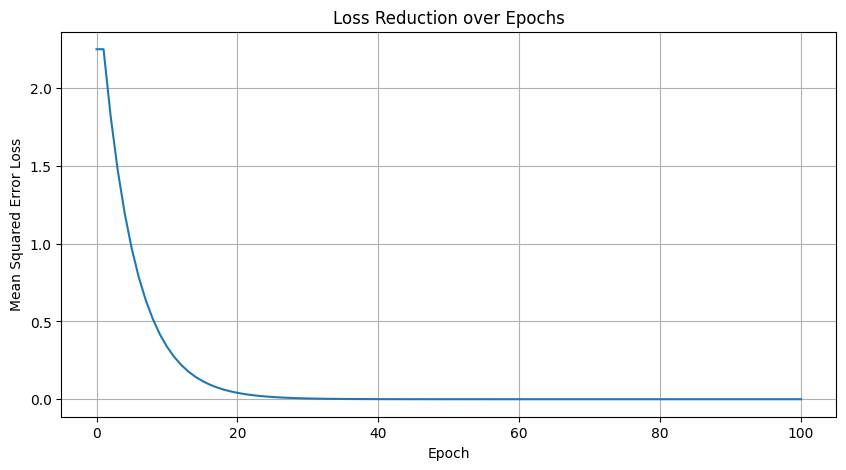

### Conclusion
This simplified example demonstrates the core mechanism of backpropagation: computing gradients of the loss with respect to parameters and then using these gradients to update the parameters to reduce the loss. In a real CNN, this process is applied across thousands or millions of parameters in convolutional filters, biases, and dense layer weights, but the underlying principle of using the chain rule to guide parameter updates remains the same. This iterative process of forward pass, loss calculation, backward pass, and parameter update is how neural networks learn to perform complex tasks like image classification.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define a simple linear model and a loss function ---

# Our simple model: y_pred = w * x + b
# Loss function: Mean Squared Error (MSE) = (y_pred - y_true)^2

def forward_pass(x, w, b):
    return w * x + b

def calculate_loss(y_pred, y_true):
    return (y_pred - y_true)**2

# --- 2. Initial parameters and data ---
x = 2.0  # Input
y_true = 4.0 # True target

w = 1.0  # Initial weight
b = 0.5  # Initial bias
learning_rate = 0.01

print(f"Initial parameters: w={w}, b={b}")

# --- 3. Forward Pass ---
y_pred = forward_pass(x, w, b)
loss = calculate_loss(y_pred, y_true)

print(f"\nForward Pass:")
print(f"  Input (x): {x}")
print(f"  True Target (y_true): {y_true}")
print(f"  Prediction (y_pred): {y_pred}")
print(f"  Initial Loss: {loss:.4f}")

# --- 4. Backward Pass (Calculate Gradients) ---

# Partial derivative of loss wrt y_pred: dL/dy_pred
dL_dy_pred = 2 * (y_pred - y_true)

# Partial derivative of y_pred wrt w: dy_pred/dw
dy_pred_dw = x

# Partial derivative of y_pred wrt b: dy_pred/db
dy_pred_db = 1

# Apply chain rule to get gradients of loss wrt w and b
gradient_w = dL_dy_pred * dy_pred_dw
gradient_b = dL_dy_pred * dy_pred_db

print(f"\nBackward Pass (Gradients):")
print(f"  dL/dy_pred: {dL_dy_pred:.4f}")
print(f"  dy_pred/dw: {dy_pred_dw:.4f}")
print(f"  dy_pred/db: {dy_pred_db:.4f}")
print(f"  Gradient w (dL/dw): {gradient_w:.4f}")
print(f"  Gradient b (dL/db): {gradient_b:.4f}")

# --- 5. Update Parameters ---
w_new = w - learning_rate * gradient_w
b_new = b - learning_rate * gradient_b

print(f"\nParameter Update (Learning Rate = {learning_rate}):")
print(f"  New Weight (w_new): {w_new:.4f}")
print(f"  New Bias (b_new): {b_new:.4f}")

# --- 6. Verify with another Forward Pass (after update) ---
y_pred_new = forward_pass(x, w_new, b_new)
loss_new = calculate_loss(y_pred_new, y_true)

print(f"\nVerification (after update):")
print(f"  New Prediction (y_pred_new): {y_pred_new:.4f}")
print(f"  New Loss: {loss_new:.4f}")
print(f"  Loss Reduced: {loss > loss_new}")

# --- Plotting the loss reduction over multiple iterations ---

epochs = 100
w_history = [w]
b_history = [b]
loss_history = [loss]

for epoch in range(epochs):
    y_pred = forward_pass(x, w, b)
    loss = calculate_loss(y_pred, y_true)
    loss_history.append(loss)

    dL_dy_pred = 2 * (y_pred - y_true)
    gradient_w = dL_dy_pred * x
    gradient_b = dL_dy_pred * 1

    w = w - learning_rate * gradient_w
    b = b - learning_rate * gradient_b

    w_history.append(w)
    b_history.append(b)

plt.figure(figsize=(10, 5))
plt.plot(range(epochs + 1), loss_history)
plt.title('Loss Reduction over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.grid(True)
plt.show()

print("### Conclusion\nThis simplified example demonstrates the core mechanism of backpropagation: computing gradients of the loss with respect to parameters and then using these gradients to update the parameters to reduce the loss. In a real CNN, this process is applied across thousands or millions of parameters in convolutional filters, biases, and dense layer weights, but the underlying principle of using the chain rule to guide parameter updates remains the same. This iterative process of forward pass, loss calculation, backward pass, and parameter update is how neural networks learn to perform complex tasks like image classification.")


## Topic 12: Famous CNN Architectures

Convolutional Neural Networks (CNNs) have revolutionized computer vision, leading to breakthroughs in image classification, object detection, and segmentation. Over the years, several groundbreaking CNN architectures have emerged, each introducing novel concepts to improve performance, efficiency, or both. Understanding these architectures is crucial for appreciating the evolution of deep learning in vision tasks.

This section will delve into some of the most influential and widely recognized CNN architectures, explaining their core ideas, mathematical underpinnings, and contributions to the field. We will cover:

*   **LeNet** (The pioneering architecture)
*   **AlexNet** (Kickstarting the deep learning era)
*   **VGG16** (Simplicity and depth)
*   **GoogLeNet (Inception)** (Efficient multi-scale processing)
*   **ResNet** (Solving the vanishing gradient problem in very deep networks)
*   **DenseNet** (Feature reuse through dense connectivity)
*   **EfficientNet** (Scaling efficiency)
*   **MobileNet** (Designed for mobile and embedded vision applications)
*   **YOLO (Introduction)** (Real-time object detection)
*   **Comparison Table** (A summary of key characteristics)
*   **Graphs** (Architectural and timeline visualizations)


### 1. LeNet

**Introduction:**
LeNet-5, introduced by Yann LeCun and his colleagues in 1998, is considered one of the earliest and most influential convolutional neural networks. It was primarily designed for optical character recognition (OCR), specifically recognizing handwritten digits. LeNet-5 laid the foundation for many modern CNN architectures by demonstrating the effectiveness of convolutional layers, pooling, and activation functions for feature extraction and classification.

**Architecture & Explanation:**
LeNet-5 consists of seven layers (excluding input), including convolutional layers, pooling (subsampling) layers, and fully connected layers. The key components are:

1.  **Input Layer:** Takes a grayscale image (e.g., 32x32 pixels).
2.  **C1 (Convolutional Layer):** Applies 6 filters of size 5x5 with a stride of 1. Each filter detects different features. The output is 6 feature maps of size 28x28.
3.  **S2 (Subsampling/Pooling Layer):** Applies average pooling with a 2x2 window and a stride of 2 over each of the 6 feature maps. This reduces the feature map size to 14x14. It's important to note that each unit in S2 connects to a 2x2 area in C1, and for each unit, the four inputs are summed, multiplied by a trainable coefficient, added to a trainable bias, and then passed through an activation function.
4.  **C3 (Convolutional Layer):** This layer is more complex. It applies 16 filters of size 5x5. However, not all 16 filters are connected to all 6 input feature maps from S2. Instead, connections are partially established to break symmetry and keep the number of connections manageable. The output is 16 feature maps of size 10x10.
5.  **S4 (Subsampling/Pooling Layer):** Similar to S2, it applies average pooling with a 2x2 window and a stride of 2, reducing feature map size to 5x5 for each of the 16 feature maps.
6.  **C5 (Convolutional Layer):** Applies 120 filters of size 5x5. Since the input to C5 is 16 feature maps of 5x5, and the filters are 5x5, each filter's receptive field covers all input feature maps. This layer effectively acts like a fully connected layer where the input 5x5x16 is flattened to a 400-element vector, and 120 filters each produce a single output unit.
7.  **F6 (Fully Connected Layer):** Contains 84 neurons. It takes the 120 outputs from C5 and connects them to 84 neurons.
8.  **Output Layer:** Contains 10 neurons, representing the 10 possible digit classes (0-9), typically using a Euclidean Radial Basis Function (RBF) or Softmax activation for classification.

LeNet used `tanh` activation functions in its earlier versions, but modern implementations often use ReLU.

**Mathematics (Conceptual):**
The core mathematical operations in LeNet are convolution, subsampling (average pooling), and dense layer computations, which have been covered in previous topics. The specific innovation lies in the architecture's sequential arrangement and the partial connectivity in C3 to manage computational complexity.

**Conclusion:**
LeNet-5's significance lies in being a pioneering architecture that demonstrated the power of convolutional layers for feature extraction and hierarchical processing. Its success in handwritten digit recognition validated the core concepts of CNNs, paving the way for deeper and more complex architectures that followed. It proved that learning features directly from data, rather than relying on hand-crafted features, was a powerful approach.

#### Graph: LeNet-5 Architecture

```mermaid
graph TD
    A[Input<br>32x32x1] --> B{C1<br>Conv 5x5, 6 F.M.<br>Output: 28x28x6};
    B --> C{S2<br>Avg Pool 2x2, Stride 2<br>Output: 14x14x6};
    C --> D{C3<br>Conv 5x5, 16 F.M.<br>Output: 10x10x16};
    D --> E{S4<br>Avg Pool 2x2, Stride 2<br>Output: 5x5x16};
    E --> F{C5<br>Conv 5x5, 120 F.M.<br>Output: 1x1x120 (effectively 120 units)};
    F --> G{F6<br>FC Layer, 84 Units};
    G --> H[Output<br>10 Units (Softmax)];

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B fill:#bbf,stroke:#333,stroke-width:2px;
    style C fill:#ccf,stroke:#333,stroke-width:2px;
    style D fill:#bbf,stroke:#333,stroke-width:2px;
    style E fill:#ccf,stroke:#333,stroke-width:2px;
    style F fill:#bbf,stroke:#333,stroke-width:2px;
    style G fill:#fbc,stroke:#333,stroke-width:2px;
    style H fill:#9f9,stroke:#333,stroke-width:2px;

```

### 2. AlexNet

**Introduction:**
AlexNet, developed by Alex Krizhevsky, Ilya Sutskever, and Geoffrey Hinton, famously won the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) in 2012 by a significant margin. This victory is widely considered the moment deep learning, and specifically CNNs, gained widespread recognition and ignited the modern AI boom. AlexNet demonstrated that deep CNNs, when trained on large datasets with powerful GPUs, could achieve unprecedented accuracy in complex image recognition tasks.

**Architecture & Explanation:**
AlexNet is significantly deeper and wider than LeNet, consisting of eight layers: five convolutional layers, some followed by max-pooling layers, and three fully connected layers. Key features and innovations include:

1.  **Input Layer:** Takes 224x224x3 (later adjusted to 227x227x3) RGB images.
2.  **C1 (Convolutional Layer):** Uses 96 filters of size 11x11 with a stride of 4. This large stride and filter size were designed to quickly reduce the spatial dimensions. It applied **ReLU** activation functions, a key innovation for faster training compared to sigmoid/tanh.
3.  **Pooling Layer 1:** Applies max-pooling with a 3x3 window and a stride of 2.
4.  **C2 (Convolutional Layer):** Uses 256 filters of size 5x5 with a stride of 1, *after padding* to preserve dimensions. It also introduced **Local Response Normalization (LRN)** layers (though LRN is rarely used in modern CNNs).
5.  **Pooling Layer 2:** Applies max-pooling with a 3x3 window and a stride of 2.
6.  **C3 (Convolutional Layer):** Uses 384 filters of size 3x3 with a stride of 1.
7.  **C4 (Convolutional Layer):** Uses 384 filters of size 3x3 with a stride of 1.
8.  **C5 (Convolutional Layer):** Uses 256 filters of size 3x3 with a stride of 1.
9.  **Pooling Layer 3:** Applies max-pooling with a 3x3 window and a stride of 2.
10. **FC6 (Fully Connected Layer):** Contains 4096 neurons. **Dropout** regularization was introduced here to prevent overfitting.
11. **FC7 (Fully Connected Layer):** Contains 4096 neurons, also with Dropout.
12. **Output Layer:** Contains 1000 neurons (for ImageNet's 1000 classes) with **Softmax** activation.

**Key Innovations:**
*   **ReLU Activation:** Significantly sped up training compared to traditional activation functions.
*   **GPU Usage:** First large-scale CNN to fully leverage GPUs for training, distributing the model across two GPUs.
*   **Local Response Normalization (LRN):** A form of regularization that created competition among neuron outputs (less common now).
*   **Overlapping Max Pooling:** Using a stride smaller than the filter size (e.g., 3x3 pool with stride 2).
*   **Dropout:** A powerful regularization technique to prevent overfitting in fully connected layers.
*   **Data Augmentation:** Extensive use of data augmentation (translations, horizontal reflections, patch extractions) to artificially enlarge the dataset and reduce overfitting.

**Conclusion:**
AlexNet's immense success in ILSVRC 2012 was a watershed moment. It unequivocally demonstrated the power and scalability of deep convolutional neural networks when combined with powerful hardware, large datasets, and crucial techniques like ReLU and dropout. It spurred a massive amount of research and development in the field, setting the stage for the deep learning revolution.

#### Graph: AlexNet Architecture

```mermaid
graph TD
    A[Input<br>227x227x3] --> B{C1<br>Conv 11x11/4, 96 F.M.<br>ReLU};
    B --> C{Pool1<br>Max Pool 3x3/2};
    C --> D{C2<br>Conv 5x5/1, 256 F.M.<br>ReLU};
    D --> E{Pool2<br>Max Pool 3x3/2};
    E --> F{C3<br>Conv 3x3/1, 384 F.M.<br>ReLU};
    F --> G{C4<br>Conv 3x3/1, 384 F.M.<br>ReLU};
    G --> H{C5<br>Conv 3x3/1, 256 F.M.<br>ReLU};
    H --> I{Pool3<br>Max Pool 3x3/2};
    I --> J{FC6<br>4096 Units, Dropout};
    J --> K{FC7<br>4096 Units, Dropout};
    K --> L[Output<br>1000 Units, Softmax];

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B fill:#bbf,stroke:#333,stroke-width:2px;
    style C fill:#ccf,stroke:#333,stroke-width:2px;
    style D fill:#bbf,stroke:#333,stroke-width:2px;
    style E fill:#ccf,stroke:#333,stroke-width:2px;
    style F fill:#bbf,stroke:#333,stroke-width:2px;
    style G fill:#bbf,stroke:#333,stroke-width:2px;
    style H fill:#bbf,stroke:#333,stroke-width:2px;
    style I fill:#ccf,stroke:#333,stroke-width:2px;
    style J fill:#fbc,stroke:#333,stroke-width:2px;
    style K fill:#fbc,stroke:#333,stroke-width:2px;
    style L fill:#9f9,stroke:#333,stroke-width:2px;
```

### 3. VGG16

**Introduction:**
VGG16, developed by Karen Simonyan and Andrew Zisserman at the University of Oxford in 2014, was another significant architecture that performed exceptionally well in the ILSVRC 2014 competition. Its main contribution was demonstrating that increasing the depth of the network (by using very small 3x3 convolutional filters) could lead to substantial improvements in classification accuracy.

**Architecture & Explanation:**
VGG16 (and its deeper variant VGG19) is characterized by its simplicity and uniformity. It primarily uses 3x3 convolutional layers and 2x2 max-pooling layers stacked repeatedly. The '16' in VGG16 refers to the number of weight layers (13 convolutional layers and 3 fully connected layers). All convolutional filters are 3x3 with stride 1 and 'same' padding, and all max-pooling layers are 2x2 with stride 2.

**Typical Structure of VGG16:**

1.  **Input Layer:** 224x224x3 RGB image.
2.  **Block 1:** Two Conv layers (3x3, 64 filters), then Max Pool (2x2).
3.  **Block 2:** Two Conv layers (3x3, 128 filters), then Max Pool (2x2).
4.  **Block 3:** Three Conv layers (3x3, 256 filters), then Max Pool (2x2).
5.  **Block 4:** Three Conv layers (3x3, 512 filters), then Max Pool (2x2).
6.  **Block 5:** Three Conv layers (3x3, 512 filters), then Max Pool (2x2).
7.  **FC Layers:** Three fully connected layers (4096, 4096, 1000 units), with ReLU activation and Dropout between the first two FC layers.
8.  **Output Layer:** Softmax for 1000 classes.

**Key Innovations/Contributions:**
*   **Increased Depth with Small Filters:** VGGNet proved that simply going deeper, with a uniform and small filter size (3x3), could significantly improve performance. The 3x3 filter is the smallest possible to capture connectivity between pixels (including center and its 8 neighbors).
*   **Stacked Small Filters:** Stacking multiple 3x3 convolutional layers (e.g., three 3x3 layers) can achieve the same effective receptive field as a single larger filter (e.g., a 7x7 filter) but with fewer parameters and more non-linearities. For instance, two 3x3 conv layers have an effective receptive field of 5x5, and three 3x3 conv layers have an effective receptive field of 7x7. This allows for more non-linear transformations without increasing the number of parameters too much.
*   **Simplicity and Uniformity:** The homogeneous architecture made it easier to understand and implement.

**Limitations:**
*   **High Computational Cost:** VGG16 has a very large number of parameters (around 138 million for the full version), making it computationally expensive to train and requiring significant memory.
*   **Slower Training:** Due to its depth and parameter count, VGG16 is slower to train compared to more efficient architectures.

**Conclusion:**
VGG16's contribution was a strong empirical demonstration of the importance of network depth in CNNs for achieving high accuracy. By systematically exploring deeper architectures with simple and uniform convolutional blocks, it provided a clear path forward for designing more powerful neural networks, even if its computational demands later led to the development of more parameter-efficient models.

#### Graph: VGG16 Architecture

```mermaid
graph TD
    A[Input<br>224x224x3] --> C1_1{Conv 3x3, 64 F.M.<br>ReLU};
    C1_1 --> C1_2{Conv 3x3, 64 F.M.<br>ReLU};
    C1_2 --> P1{Max Pool 2x2/2};
    P1 --> C2_1{Conv 3x3, 128 F.M.<br>ReLU};
    C2_1 --> C2_2{Conv 3x3, 128 F.M.<br>ReLU};
    C2_2 --> P2{Max Pool 2x2/2};
    P2 --> C3_1{Conv 3x3, 256 F.M.<br>ReLU};
    C3_1 --> C3_2{Conv 3x3, 256 F.M.<br>ReLU};
    C3_2 --> C3_3{Conv 3x3, 256 F.M.<br>ReLU};
    C3_3 --> P3{Max Pool 2x2/2};
    P3 --> C4_1{Conv 3x3, 512 F.M.<br>ReLU};
    C4_1 --> C4_2{Conv 3x3, 512 F.M.<br>ReLU};
    C4_2 --> C4_3{Conv 3x3, 512 F.M.<br>ReLU};
    C4_3 --> P4{Max Pool 2x2/2};
    P4 --> C5_1{Conv 3x3, 512 F.M.<br>ReLU};
    C5_1 --> C5_2{Conv 3x3, 512 F.M.<br>ReLU};
    C5_2 --> C5_3{Conv 3x3, 512 F.M.<br>ReLU};
    C5_3 --> P5{Max Pool 2x2/2};
    P5 --> F1{FC Layer<br>4096 Units, Dropout};
    F1 --> F2{FC Layer<br>4096 Units, Dropout};
    F2 --> O[Output<br>1000 Units, Softmax];

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style C1_1,C1_2,C2_1,C2_2,C3_1,C3_2,C3_3,C4_1,C4_2,C4_3,C5_1,C5_2,C5_3 fill:#bbf,stroke:#333,stroke-width:2px;
    style P1,P2,P3,P4,P5 fill:#ccf,stroke:#333,stroke-width:2px;
    style F1,F2 fill:#fbc,stroke:#333,stroke-width:2px;
    style O fill:#9f9,stroke:#333,stroke-width:2px;
```

### 4. GoogLeNet (Inception)

**Introduction:**
GoogLeNet, also known as Inception v1, was introduced by Google in 2014 and won the ILSVRC 2014 competition, surpassing VGGNet in both accuracy and computational efficiency. The core innovation of GoogLeNet is the **Inception module**, which allows the network to effectively capture multi-scale features and optimize computational resources. Instead of choosing one filter size, Inception modules use multiple filter sizes (1x1, 3x3, 5x5) and pooling operations in parallel, concatenating their results.

**Architecture & Explanation:**
GoogLeNet is a very deep network, consisting of 22 layers if counting only layers with parameters. It uses a relatively small number of parameters (around 5 million), which is significantly less than AlexNet (60 million) and VGG (138 million). This efficiency is primarily due to the Inception modules and the use of 1x1 convolutions for dimensionality reduction.

**Key Components of an Inception Module:**
An Inception module performs the following operations in parallel on the input feature map:

1.  **1x1 Convolution:** Used for dimensionality reduction (reducing the number of channels) before expensive 3x3 and 5x5 convolutions. This reduces computational cost and allows for increased depth and width.
2.  **3x3 Convolution:** Applied after a 1x1 convolution (for dimensionality reduction).
3.  **5x5 Convolution:** Applied after a 1x1 convolution (for dimensionality reduction).
4.  **3x3 Max Pooling:** Also applied in parallel, followed by a 1x1 convolution (for dimensionality reduction).

The outputs of all these parallel branches are then **concatenated** along the channel dimension to form the output of the Inception module.

**Overall Architecture:**
GoogLeNet stacks these Inception modules. It uses global average pooling instead of fully connected layers at the end, further reducing parameters and overfitting.

*   Initial layers include standard convolutional and max-pooling layers.
*   Nine Inception modules are stacked, with occasional max-pooling layers to reduce spatial dimensions.
*   It incorporates **auxiliary classifiers** during training (usually two), which are small networks attached to intermediate layers. These classifiers help combat the vanishing gradient problem by providing additional supervision in deeper parts of the network. They are discarded during inference.
*   The final layer is a Global Average Pooling layer, followed by a Softmax classifier.

**Key Innovations/Contributions:**
*   **Inception Module:** The main contribution, enabling efficient multi-scale feature extraction and reducing computational burden.
*   **1x1 Convolutions:** Critically used for dimensionality reduction within the Inception module, making the network much deeper and wider without an explosion of parameters.
*   **Global Average Pooling:** Replaced traditional fully connected layers at the end, further reducing the number of parameters and acting as a form of regularization.
*   **Auxiliary Classifiers:** Helped in training very deep networks by providing gradient signals to lower layers, preventing vanishing gradients.

**Mathematics (Conceptual):**
The core mathematical concept is the parallel application of different convolutional filters (1x1, 3x3, 5x5) and pooling, followed by concatenation. The 1x1 convolution, in particular, implements a bottleneck layer that reduces the number of channels, effectively controlling the computational cost for subsequent larger convolutions.

**Conclusion:**
GoogLeNet introduced a highly innovative and efficient way to design deep convolutional networks through its Inception modules. By judiciously using 1x1 convolutions for dimensionality reduction and processing features at multiple scales concurrently, it achieved state-of-the-art performance with significantly fewer parameters than its predecessors. This architecture laid the groundwork for subsequent Inception variations and emphasized the importance of architectural design for optimizing both accuracy and efficiency in deep learning models.

#### Graph: GoogLeNet (Inception) Module

```mermaid
graph TD
    A[Input Feature Map] --> B_1_1{1x1 Conv};
    A --> B_3_1{1x1 Conv} --> C_3_3{3x3 Conv};
    A --> B_5_1{1x1 Conv} --> C_5_5{5x5 Conv};
    A --> B_P_1{3x3 Max Pool} --> C_P_1{1x1 Conv};

    B_1_1 --> D[Concatenate];
    C_3_3 --> D;
    C_5_5 --> D;
    C_P_1 --> D;

    D --> E[Output Feature Map];

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B_1_1,B_3_1,B_5_1,C_3_3,C_5_5,C_P_1 fill:#bbf,stroke:#333,stroke-width:2px;
    style B_P_1 fill:#ccf,stroke:#333,stroke-width:2px;
    style D fill:#f9f,stroke:#333,stroke-width:2px;
    style E fill:#9f9,stroke:#333,stroke-width:2px;
```

### 5. ResNet (Residual Networks)

**Introduction:**
Residual Networks (ResNets), introduced by Kaiming He et al. in 2015, were a groundbreaking architecture that won the ILSVRC 2015 classification task. ResNets revolutionized the training of very deep neural networks by addressing the **degradation problem**—where simply stacking more layers leads to higher training error, not just test error, indicating that deeper networks are harder to optimize than shallower ones. The core innovation is the **residual block** with "skip connections" or "shortcut connections."

**Architecture & Explanation:**
ResNet's key idea is to learn **residual functions** instead of unreferenced functions. Instead of expecting a stack of layers to directly learn a desired mapping $H(x)$, ResNet proposes that the layers learn a residual mapping $F(x) = H(x) - x$. The original mapping is then $H(x) = F(x) + x$. This 'shortcut' connection allows the gradient to flow directly through the network, bypassing one or more layers.

**The Residual Block:**
A basic residual block consists of:
1.  Two or three convolutional layers.
2.  Batch Normalization after each convolution and before activation.
3.  ReLU activation after batch normalization.
4.  A **shortcut connection** that adds the input $x$ to the output of the stacked layers $F(x)$.

This addition is performed element-wise.

**Identity Mapping:**
The power of the shortcut connection comes from enabling **identity mapping**. If the optimal function for a layer is simply to pass its input through (i.e., $H(x) = x$), the stacked layers can easily learn $F(x) = 0$ (which is simpler than learning $H(x) = x$ directly in a deep non-linear stack). This makes it easier to train deeper networks as layers can simply learn to do nothing if that's optimal.

**Different ResNet Versions:**
ResNet comes in various depths, such as ResNet-18, ResNet-34, ResNet-50, ResNet-101, and ResNet-152, referring to the number of layers with weights. Deeper versions often use a **bottleneck block** to reduce computational cost. A bottleneck block uses 1x1 convolutions to first reduce, then restore, the dimensionality, sandwiching a 3x3 convolution:
*   1x1 Conv (reduces dimensions)
*   3x3 Conv
*   1x1 Conv (restores dimensions)

**Overall Architecture:**
ResNets typically start with a single large convolutional layer (e.g., 7x7) and max-pooling, similar to AlexNet/VGG, to quickly reduce spatial dimensions. Then, a series of residual blocks are stacked, with increasing numbers of filters and occasional downsampling (stride 2 in convolutions within a block) to reduce feature map size. Finally, Global Average Pooling and a fully connected layer with Softmax are used for classification.

**Key Innovations/Contributions:**
*   **Residual Connections (Skip Connections):** The most significant contribution, allowing the training of extremely deep networks (up to 1000+ layers) by mitigating the vanishing/exploding gradient problem and the degradation problem.
*   **Identity Mapping:** Enables layers to easily learn identity functions, making deeper networks at least as good as their shallower counterparts.
*   **Extreme Depth:** Demonstrated that networks could be significantly deeper than previously thought, leading to better performance on complex tasks.
*   **Bottleneck Architecture (for deeper ResNets):** Efficiently reduces parameters and computation in very deep networks without sacrificing accuracy.

**Mathematics (Conceptual):**
The core mathematical idea is $y = F(x, {W_i}) + x$. Here, $x$ is the input to the residual block, $F(x, {W_i})$ represents the output of the convolutional layers within the block (e.g., $F(x) = W_2 	ext{ReLU}(W_1 x)$), and $y$ is the output of the block. If the dimensions of $F(x)$ and $x$ are different (due to stride or changing number of filters), a linear projection $W_s$ (a 1x1 convolution) is applied to $x$ to match the dimensions: $y = F(x, {W_i}) + W_s x$.

**Conclusion:**
ResNet fundamentally changed the landscape of deep learning by enabling the training of neural networks with unprecedented depth. Its simple yet powerful residual learning framework solved the long-standing degradation problem, paving the way for state-of-the-art performance in numerous computer vision tasks and influencing countless subsequent architectures. The concept of skip connections has become a ubiquitous technique in deep learning.

#### Graph: ResNet Basic Block (Identity Mapping)

```mermaid
graph TD
    A[Input Feature Map (x)] --> B1{Conv 3x3<br>ReLU};
    B1 --> B2{Conv 3x3};
    A --> C{Identity Mapping (x)};
    B2 --> D{+ (Addition)};
    C --> D;
    D --> E[Output Feature Map<br>(F(x) + x)];
    E --> F{ReLU};

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B1,B2 fill:#bbf,stroke:#333,stroke-width:2px;
    style C fill:#ccf,stroke:#333,stroke-width:2px;
    style D fill:#f9f,stroke:#333,stroke-width:2px;
    style E fill:#9f9,stroke:#333,stroke-width:2px;
    style F fill:#ccf,stroke:#333,stroke-width:2px;

```

#### Graph: ResNet Bottleneck Block (for deeper networks)

```mermaid
graph TD
    A[Input Feature Map (x)] --> B1{Conv 1x1<br>Reduce Dim};
    B1 --> B2{Conv 3x3<br>ReLU};
    B2 --> B3{Conv 1x1<br>Restore Dim};
    A --> C{1x1 Conv (Ws x)<br>Match Dims if needed};
    B3 --> D{+ (Addition)};
    C --> D;
    D --> E[Output Feature Map<br>(F(x) + Ws x)];
    E --> F{ReLU};

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B1,B2,B3 fill:#bbf,stroke:#333,stroke-width:2px;
    style C fill:#ccf,stroke:#333,stroke-width:2px;
    style D fill:#f9f,stroke:#333,stroke-width:2px;
    style E fill:#9f9,stroke:#333,stroke-width:2px;
    style F fill:#ccf,stroke:#333,stroke-width:2px;
```

### 6. DenseNet (Densely Connected Convolutional Networks)

**Introduction:**
DenseNet, introduced by Gao Huang et al. in 2017, is a convolutional neural network architecture that builds upon the concept of skip connections from ResNet but takes it a step further. While ResNet connects layers by summing the output of a prior layer with the output of a subsequent layer, DenseNet connects *each layer to every other layer in a feed-forward fashion*. This 'dense connectivity' ensures maximum information flow between layers in the network.

**Architecture & Explanation:**
A DenseNet is composed of multiple **Dense Blocks**. Within each dense block, each layer receives the feature maps from all preceding layers as input, and passes its own feature maps to all subsequent layers. This means if a dense block has `L` layers, the `l`-th layer receives `l` inputs, consisting of the feature maps of all preceding convolutional layers within that block. These inputs are concatenated along the channel dimension. The layer then performs a standard operation (e.g., Batch Normalization, ReLU, Conv 3x3) and outputs its own set of feature maps.

Between dense blocks, **Transition Layers** are used to reduce the spatial dimensions and the number of feature maps. A typical transition layer consists of:
1.  A Batch Normalization layer.
2.  A 1x1 Convolutional layer (used for dimensionality reduction).
3.  An Average Pooling layer (e.g., 2x2).

This structure addresses several issues:
*   **Vanishing Gradients:** The direct connections provide a clear path for gradients to flow backward through the network, making it easier to train very deep models.
*   **Feature Reuse:** Each layer has direct access to the feature maps from all preceding layers, leading to more efficient feature reuse and potentially more compact models.
*   **Reduced Parameter Count:** By encouraging feature reuse, DenseNets often require fewer parameters than traditional CNNs for similar performance, especially when compared to ResNets.

**Key Innovations/Contributions:**
*   **Dense Connectivity:** Each layer receives feature maps from all preceding layers and passes them to all subsequent layers within a dense block.
*   **Feature Reuse:** Promotes feature reuse throughout the network, leading to more compact and efficient models.
*   **Implicit Deep Supervision:** The direct connections to earlier layers act as a form of implicit deep supervision, helping to train deeper networks more effectively.
*   **Parameter Efficiency:** Often achieves state-of-the-art results with fewer parameters and less computation than other architectures due to efficient feature propagation.

**Mathematics (Conceptual):**
If $x_l$ denotes the output of the $l$-th layer, then for a traditional convolutional network, $x_l = H_l(x_{l-1})$. For ResNet, $x_l = H_l(x_{l-1}) + x_{l-1}$. In DenseNet, the output of the $l$-th layer is $x_l = H_l([x_0, x_1, \dots, x_{l-1}])$, where $[x_0, x_1, \dots, x_{l-1}]$ refers to the concatenation of the feature maps produced by layers $0, \dots, l-1$. The function $H_l$ typically consists of a sequence of operations like BN-ReLU-Conv. The number of output feature maps for each layer within a dense block is usually small, referred to as the 'growth rate' (k).

**Conclusion:**
DenseNet offers a compelling alternative to ResNet by proposing an even more aggressive connectivity pattern. By ensuring that every layer has direct access to all preceding feature maps, DenseNet effectively mitigates the vanishing gradient problem, promotes feature reuse, and leads to highly parameter-efficient models. Its ability to achieve high performance with a relatively compact architecture has made it a significant contribution to the evolution of deep learning for computer vision.

#### Graph: DenseNet Dense Block (Conceptual)

```mermaid
graph TD
    A[Input Feature Maps (X0)] --> B1{Layer 1<br>(BN-ReLU-Conv)};
    B1 --> C1[X1];

    A --> B2{Layer 2<br>(BN-ReLU-Conv)};
    C1 --> B2;
    B2 --> C2[X2];

    A --> B3{Layer 3<br>(BN-ReLU-Conv)};
    C1 --> B3;
    C2 --> B3;
    B3 --> C3[X3];

    C3 --> D[Concatenation<br>[X0, X1, X2, X3]];
    D --> E[Output of Dense Block];

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B1,B2,B3 fill:#bbf,stroke:#333,stroke-width:2px;
    style C1,C2,C3 fill:#ccf,stroke:#333,stroke-width:2px;
    style D fill:#f9f,stroke:#333,stroke-width:2px;
    style E fill:#9f9,stroke:#333,stroke-width:2px;
```

### 7. EfficientNet

**Introduction:**
EfficientNet, introduced by Mingxing Tan and Quoc V. Le from Google Brain in 2019, is a family of CNN architectures designed to achieve state-of-the-art accuracy with significantly fewer parameters and FLOPs (floating-point operations) compared to previous models. Its key innovation lies in a novel **compound scaling method** that uniformly scales all dimensions of a CNN (depth, width, and resolution) using a set of fixed scaling coefficients.

**Architecture & Explanation:**
Traditional practice often involved scaling up one dimension (e.g., depth or width) at a time, or arbitrarily. EfficientNet demonstrated that carefully balancing all three dimensions—network **depth** (number of layers), **width** (number of channels), and input image **resolution**—is crucial for optimal performance and efficiency.

EfficientNet uses an optimized baseline network called **EfficientNet-B0**, which is built upon **MBConv (Mobile Inverted Bottleneck Convolution)** blocks. These blocks are similar to the inverted residuals in MobileNetV2, featuring depthwise separable convolutions.

**Compound Scaling Method:**
This method uses a compound coefficient \(\phi\) to scale depth, width, and resolution simultaneously:

*   **Depth:** \(d = \alpha^\phi\)
*   **Width:** \(w = \beta^\phi\)
*   **Resolution:** \(r = \gamma^\phi\)

Subject to \(\alpha \cdot \beta^2 \cdot \gamma^2 \approx 2\) and \(\alpha \ge 1, \beta \ge 1, \gamma \ge 1\), where \(\alpha, \beta, \gamma\) are coefficients determined by a small grid search on the baseline model, and \(\phi\) is a user-specified coefficient that controls the overall scaling of the model. By increasing \(\phi\), you get larger models like EfficientNet-B1, B2, ..., B7.

**MBConv Blocks (Key building block):**
Each MBConv block in EfficientNet includes:
1.  **1x1 Convolution** (pointwise convolution) to expand channels.
2.  **Depthwise Convolution** (e.g., 3x3 or 5x5) for spatial filtering, operating on each channel independently.
3.  **SE (Squeeze-and-Excitation) Block** to adaptively recalibrate channel-wise feature responses.
4.  **1x1 Convolution** (pointwise convolution) to project channels back down.
5.  **Skip connections** and **Batch Normalization** are used throughout.

**Overall Architecture:**
The EfficientNet family starts with a standard convolutional layer, followed by several stages of MBConv blocks. Each stage typically contains multiple MBConv blocks with increasing numbers of channels. The network ends with a global average pooling layer and a fully connected layer for classification.

**Key Innovations/Contributions:**
*   **Compound Scaling:** A systematic approach to scaling CNNs that uniformly scales depth, width, and resolution, leading to better accuracy and efficiency.
*   **MBConv Blocks:** Leverages efficient building blocks based on depthwise separable convolutions.
*   **Squeeze-and-Excitation (SE) Networks:** Integrates SE blocks for improved channel-wise feature recalibration.
*   **State-of-the-Art Performance:** Achieved top accuracy on ImageNet with significantly fewer parameters and FLOPs than previous models (e.g., ResNeXt, AmoebaNet).

**Mathematics (Conceptual):**
The compound scaling primarily optimizes the overall resource usage by balancing depth, width, and resolution. The MBConv blocks are mathematically defined by their convolution operations and the SE block's attention mechanism (which involves learnable weights to determine the importance of each channel).

**Conclusion:**
EfficientNet represents a significant advancement in CNN design by introducing a principled and effective way to scale networks. Its compound scaling method and reliance on efficient MBConv blocks have allowed it to achieve a remarkable balance between accuracy and computational cost, making it a highly influential architecture for a wide range of computer vision applications, especially where resource constraints are a concern.

#### Graph: EfficientNet MBConv Block (Conceptual)

```mermaid
graph TD
    A[Input Feature Map] --> B{1x1 Conv<br>Expand Channels};
    B --> C{Depthwise Conv<br>e.g., 3x3 or 5x5};
    C --> D{Squeeze-and-Excitation<br>(SE) Block};
    D --> E{1x1 Conv<br>Project Channels};
    A --- E; % Skip connection
    E --> F{Add Input (if stride 1)};
    F --> G[Output Feature Map];

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B,C,E fill:#bbf,stroke:#333,stroke-width:2px;
    style D fill:#ccf,stroke:#333,stroke-width:2px;
    style F fill:#f9f,stroke:#333,stroke-width:2px;
    style G fill:#9f9,stroke:#333,stroke-width:2px;
```

### 8. MobileNet

**Introduction:**
MobileNet, introduced by Google in 2017, is a family of efficient convolutional neural network models designed specifically for mobile and embedded vision applications. These applications often have strict constraints on computational power, memory, and latency. MobileNet achieves high accuracy while being significantly smaller and faster than traditional CNNs by utilizing **depthwise separable convolutions** as its core building block.

**Architecture & Explanation:**
The MobileNet architecture is primarily built upon **depthwise separable convolutions**, which decompose a standard 3x3 convolution into two separate layers:

1.  **Depthwise Convolution:** This performs lightweight filtering by applying a single filter to each input channel. If the input has `M` channels, it applies `M` filters, each 3x3, producing `M` feature maps.
2.  **Pointwise Convolution (1x1 Convolution):** This performs dimensionality expansion/reduction and combines the outputs of the depthwise convolution. It applies a 1x1 convolution to create a linear combination of the depthwise convolution's output channels, effectively projecting them into a new feature space with a desired number of channels.

A standard convolution filters and combines features in one step. Depthwise separable convolution splits this into two steps: filtering and then combining. This significantly reduces computation and the number of parameters.

**Structure of a MobileNet Layer (Depthwise Separable Convolution Block):**
Each block typically includes:
*   **3x3 Depthwise Convolution**
*   **Batch Normalization**
*   **ReLU Activation**
*   **1x1 Pointwise Convolution**
*   **Batch Normalization**
*   **ReLU Activation**

**Hyperparameters for Efficiency:**
MobileNet allows for two global hyperparameters to trade off latency and accuracy:
1.  **Width Multiplier (α):** This parameter (ranging from 0 to 1, typically 0.25, 0.5, 0.75, 1.0) controls the number of channels in each layer. Reducing the width multiplier reduces the number of filters for both depthwise and pointwise convolutions.
2.  **Resolution Multiplier (ρ):** This parameter (ranging from 0 to 1, typically 1.0, 0.75, 0.5) reduces the input image resolution, which in turn reduces the computational cost of all subsequent layers.

By adjusting these two parameters, developers can create a family of models (e.g., MobileNetV1_1.0_224, MobileNetV1_0.5_128) that are optimized for different computational budgets and application needs.

**Overall Architecture:**
MobileNet typically starts with a standard 3x3 convolution, followed by a series of depthwise separable convolution blocks. These blocks are occasionally followed by stride-2 convolutions or average pooling layers to reduce spatial dimensions. The network culminates in a Global Average Pooling layer and a fully connected softmax classifier.

**Key Innovations/Contributions:**
*   **Depthwise Separable Convolutions:** The fundamental building block, drastically reducing computational cost and parameters compared to standard convolutions.
*   **Efficiency for Mobile/Embedded Devices:** Specifically designed for resource-constrained environments, making deep learning accessible on a wider range of devices.
*   **Tunable Hyperparameters:** The width and resolution multipliers provide a simple and effective way to customize model size and latency for specific applications.
*   **Balance of Accuracy and Efficiency:** Achieves impressive accuracy for its small size and computational footprint.

**Mathematics (Conceptual):**
A standard convolution with input `D_F * D_F * M` and output `D_G * D_G * N` (where `D_F` is feature map size, `M` is input channels, `N` is output channels) and `D_K * D_K` kernel size has computational cost:
$$ D_K \cdot D_K \cdot M \cdot N \cdot D_G \cdot D_G $$

A depthwise separable convolution breaks this into two parts:

1.  **Depthwise Convolution:** Applies `M` filters, each of size `D_K * D_K * 1` (one per input channel). The output is `D_G * D_G * M` feature maps.
    Computational Cost: $$ D_K \cdot D_K \cdot M \cdot D_G \cdot D_G $$

2.  **Pointwise Convolution (1x1):** Applies `N` filters, each of size `1 * 1 * M`, to combine the `M` output feature maps from the depthwise step into `N` new feature maps.
    Computational Cost: $$ 1 \cdot 1 \cdot M \cdot N \cdot D_G \cdot D_G $$

The total computational cost for a depthwise separable convolution is the sum of these two:
$$ (D_K \cdot D_K \cdot M \cdot D_G \cdot D_G) + (M \cdot N \cdot D_G \cdot D_G) $$

Dividing the total cost of depthwise separable convolution by that of a standard convolution gives the reduction factor:
$$ \frac{D_K \cdot D_K \cdot M \cdot D_G \cdot D_G + M \cdot N \cdot D_G \cdot D_G}{D_K \cdot D_K \cdot M \cdot N \cdot D_G \cdot D_G} = \frac{1}{N} + \frac{1}{D_K^2} $$

For a 3x3 kernel and a large number of output channels `N`, this factor is approximately `1/9 + 1/N`, indicating a significant reduction in computation (e.g., almost 8 to 9 times for large `N`). The width multiplier α and resolution multiplier ρ further scale these costs linearly and quadratically, respectively.

**Conclusion:**
MobileNet's introduction of depthwise separable convolutions marked a pivotal moment in making deep learning practical for resource-constrained devices. It elegantly addressed the challenge of deploying powerful CNNs on mobile phones, embedded systems, and IoT devices by significantly reducing computational complexity and model size without a drastic loss in accuracy. The customizable width and resolution multipliers provide flexibility, allowing developers to fine-tune models for specific performance requirements, making MobileNet and its subsequent versions indispensable for on-device AI applications.

#### Graph: MobileNet Depthwise Separable Convolution Block (Conceptual)

```mermaid
graph TD
    A[Input Feature Map<br>e.g., D_F x D_F x M] --> B{3x3 Depthwise Conv<br>M filters, 1 per channel};
    B --> C{Batch Norm & ReLU};
    C --> D{1x1 Pointwise Conv<br>N filters, combines channels};
    D --> E{Batch Norm & ReLU};
    E --> F[Output Feature Map<br>e.g., D_G x D_G x N];

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B,D fill:#bbf,stroke:#333,stroke-width:2px;
    style C,E fill:#ccf,stroke:#333,stroke-width:2px;
    style F fill:#9f9,stroke:#333,stroke-width:2px;
```

### 9. YOLO (You Only Look Once)

**Introduction:**
YOLO, short for "You Only Look Once," is a state-of-the-art, real-time object detection system first introduced by Joseph Redmon et al. in 2016. Before YOLO, object detection systems typically involved multiple stages (e.g., region proposal followed by classification and bounding box regression for each proposal). YOLO revolutionized this by framing object detection as a single regression problem, directly predicting bounding boxes and class probabilities from full images in one pass.

**Architecture & Explanation (YOLOv1 Concept):**
The core idea behind YOLO is to divide the input image into an S x S grid. If the center of an object falls into a grid cell, that grid cell is responsible for detecting the object. Each grid cell predicts a fixed number of bounding boxes and confidence scores for those boxes, along with class probabilities.

**For each grid cell:**
*   **B bounding boxes:** Each bounding box prediction consists of 5 values: $(x, y, w, h, \text{confidence})$.
    *   $(x, y)$: The coordinates of the center of the box relative to the grid cell boundaries.
    *   $(w, h)$: The width and height of the box relative to the full image width and height.
    *   $\text{confidence}$: Represents two aspects: the probability that the box contains an object ($P(\text{object})$) and the accuracy of the bounding box ($IoU^{\text{truth}}_{\text{pred}}$).
        $$ \text{confidence} = P(\text{object}) * IoU^{\text{truth}}_{\text{pred}} $$
*   **C class probabilities:** These are conditional class probabilities $P(\text{Class}_i | \text{object})$ for each of the $C$ possible classes.

So, for an S x S grid, with B bounding boxes per cell and C classes, the output tensor size is **S x S x (B * 5 + C)**.

**The Network:**
YOLO typically uses a deep CNN (often based on Darknet, a custom framework) to extract features from the input image. This feature extractor significantly downsamples the image, and the final feature maps are then interpreted directly as the S x S grid predictions.

**Example:** For YOLOv1, an S x S grid of 7x7 was used, with B=2 bounding boxes per grid cell, and C=20 object classes (from PASCAL VOC). The output tensor dimension was $7 \times 7 \times (2 \times 5 + 20) = 7 \times 7 \times 30$.

**Non-Max Suppression (NMS):** After predicting numerous bounding boxes, NMS is applied to filter out redundant or overlapping boxes and keep only the most confident and accurate ones for each detected object.

**Key Innovations/Contributions:**
*   **Unified Detection System:** Treats object detection as a single regression problem, directly predicting bounding boxes and class probabilities in one evaluation of the network. This simplifies the pipeline significantly compared to region-proposal based methods.
*   **Real-time Performance:** Due to its single-pass nature, YOLO is exceptionally fast, making it suitable for real-time applications. YOLOv1 could process images at 45 frames per second, and a faster version at 150 FPS.
*   **Global Context:** Because it looks at the entire image during training and testing, YOLO implicitly encodes global context information about the image, which helps in reducing background errors (false positives).
*   **End-to-End Training:** The entire network can be trained end-to-end, optimizing directly for detection performance.

**Mathematics (Conceptual):**
The loss function in YOLO is designed to simultaneously optimize for localization (bounding box regression), classification, and confidence predictions. It's a sum-squared error, but with several weighted terms to account for the different prediction types:

$$ \text{Loss} = \lambda_{\text{coord}} \sum_{i=0}^{S^2} \sum_{j=0}^{B} I_{ij}^{\text{obj}} [(x_i - \hat{x}_i)^2 + (y_i - \hat{y}_i)^2] \\ \qquad + \lambda_{\text{coord}} \sum_{i=0}^{S^2} \sum_{j=0}^{B} I_{ij}^{\text{obj}} [(\sqrt{w_i} - \sqrt{\hat{w}_i})^2 + (\sqrt{h_i} - \sqrt{\hat{h}_i})^2] \\ \qquad + \sum_{i=0}^{S^2} \sum_{j=0}^{B} I_{ij}^{\text{obj}} (C_i - \hat{C}_i)^2 \\ \qquad + \lambda_{\text{noobj}} \sum_{i=0}^{S^2} \sum_{j=0}^{B} I_{ij}^{\text{noobj}} (C_i - \hat{C}_i)^2 \\ \qquad + \sum_{i=0}^{S^2} I_{i}^{\text{obj}} \sum_{c \in \text{classes}} (p_i(c) - \hat{p}_i(c))^2 $$

Where:
*   $S^2$: Number of grid cells.
*   $B$: Number of bounding boxes predicted per cell.
*   $I_{ij}^{\text{obj}}$: Indicator function, 1 if object is present in box $j$ of cell $i$, else 0.
*   $I_{ij}^{\text{noobj}}$: Indicator function, 1 if no object is present in box $j$ of cell $i$, else 0.
*   $(x_i, y_i, w_i, h_i)$: Predicted bounding box parameters.
*   $(\hat{x}_i, \hat{y}_i, \hat{w}_i, \hat{h}_i)$: Ground truth bounding box parameters.
*   $C_i$: Predicted confidence for box $j$ of cell $i$.
*   $\hat{C}_i$: Ground truth confidence (IoU of predicted box with ground truth).
*   $p_i(c)$: Predicted class probability for class $c$ in cell $i$.
*   $\hat{p}_i(c)$: Ground truth class probability for class $c$ in cell $i$.
*   $\lambda_{\text{coord}}$ and $\lambda_{\text{noobj}}$: Hyperparameters to weight the coordinate loss and the no-object confidence loss, respectively. These are crucial because there are many grid cells with no objects, and their combined loss could overwhelm the loss from cells with objects. Weighting the square root of width/height helps to better account for small variations in small bounding boxes.

**Conclusion:**
YOLO introduced a paradigm shift in object detection by providing a fast, unified, and end-to-end trainable system. Its ability to perform detection in real-time, coupled with competitive accuracy, made it immediately popular for applications requiring low latency, such as autonomous driving, robotics, and video surveillance. While initial versions might have struggled with detecting small objects or precisely localizing objects, subsequent versions (YOLOv2, YOLOv3, YOLOv4, YOLOv5, YOLOX, YOLOv7, YOLOv8) have continually improved upon these limitations, maintaining real-time speed while achieving even higher accuracy, solidifying YOLO's place as a cornerstone in modern computer vision.

#### Graph: YOLO (You Only Look Once) Conceptual Flow

```mermaid
graph TD
    A[Input Image] --> B{Feature Extractor (CNN)};
    B --> C[Final Feature Map<br>e.g., 7x7x1024];
    C --> D{Grid Cell Prediction<br>S x S x (B*5 + C)};
    D --> E[Predicted Bounding Boxes<br>& Class Probabilities];
    E --> F{Non-Max Suppression (NMS)};
    F --> G[Final Detections<br>Objects + Locations + Classes];

    style A fill:#f9f,stroke:#333,stroke-width:2px;
    style B fill:#bbf,stroke:#333,stroke-width:2px;
    style C fill:#ccf,stroke:#333,stroke-width:2px;
    style D fill:#bbf,stroke:#333,stroke-width:2px;
    style E fill:#f9f,stroke:#333,stroke-width:2px;
    style F fill:#ccf,stroke:#333,stroke-width:2px;
    style G fill:#9f9,stroke:#333,stroke-width:2px;
```

### 10. Comparison Table of Famous CNN Architectures

| Architecture | Year | Key Innovations                                                                 | Core Building Block               | Primary Use Case             | Parameters (approx.) | ImageNet Top-5 Error Rate (approx.) | Notes                                                     |
| :----------- | :--- | :------------------------------------------------------------------------------ | :-------------------------------- | :--------------------------- | :------------------- | :---------------------------------- | :-------------------------------------------------------- |
| **LeNet-5**  | 1998 | Early CNN, Conv layers, Subsampling (Avg Pool), Sigmoid/Tanh activations        | Conv -> Avg Pool                  | Digit Recognition            | 60K                  | N/A (earlier dataset)               | Pioneering CNN, foundational concepts.                    |
| **AlexNet**  | 2012 | Deep CNN on GPU, ReLU, Dropout, Data Augmentation, LRN, Overlapping Max Pooling | Conv -> ReLU -> Pool              | Image Classification         | 60M                  | 15.3%                               | Sparked the modern deep learning era.                     |
| **VGG16**    | 2014 | Increased depth with small (3x3) filters, uniform architecture                  | Stacked 3x3 Conv -> ReLU -> Max Pool | Image Classification         | 138M                 | 7.3%                                | High computational cost, but strong performance for its time. |
| **GoogLeNet**| 2014 | Inception Module (multi-scale processing), 1x1 Conv for dim. reduction, GAP     | Inception Module (1x1, 3x3, 5x5 Conv + Pool in parallel) | Image Classification         | 5M                   | 6.67%                               | Efficient, low parameters, auxiliary classifiers.        |
| **ResNet**   | 2015 | Residual Connections (Skip Connections), solves degradation problem in deep nets| Residual Block (F(x) + x)         | Image Classification         | 25M (ResNet-50)      | 3.57% (ResNet-152)                  | Enabled training of extremely deep networks.             |
| **DenseNet** | 2017 | Dense Connectivity (each layer to every preceding layer), feature reuse         | Dense Block (concatenation)       | Image Classification         | 7M (DenseNet-121)    | 3.42% (DenseNet-201)                | Highly parameter-efficient, mitigates vanishing gradients. |
| **EfficientNet**| 2019 | Compound Scaling (depth, width, resolution), MBConv blocks, Squeeze-and-Excitation | MBConv Block                      | Image Classification         | 5.3M (B0)            | 2.1% (B7)                           | State-of-the-art accuracy with high efficiency.           |
| **MobileNet**| 2017 | Depthwise Separable Convolutions, Width & Resolution Multipliers                | Depthwise Conv + Pointwise Conv   | Mobile/Embedded Vision       | 4.2M (V1)            | 6.8% (V1)                           | Designed for resource-constrained devices, real-time.     |
| **YOLO**     | 2016 | Single-shot object detection, frames detection as regression, real-time        | Custom CNN (Darknet base)         | Object Detection (Real-time) | 50M (YOLOv1)         | N/A (Object Detection Metric)       | Revolutionary for real-time object detection.             |

### 11. Graphs for Architecture Comparison and Timeline

#### Architecture Comparison Graph (Conceptual)

This graph conceptually illustrates how various CNN architectures compare across key dimensions like depth, number of parameters, and their innovative core ideas. It's a qualitative comparison to help understand their relative positions in the evolution of CNNs.

```mermaid
graph TD
    subgraph Architecture Evolution
        A[LeNet<br>Simple, Foundational] --> B(AlexNet<br>Deeper, ReLU, GPU, Dropout)
        B --> C(VGG16<br>Very Deep, Uniform 3x3 Conv)
        C --> D(GoogLeNet<br>Inception Modules, 1x1 Conv, Efficient)
        D --> E(ResNet<br>Residual Blocks, Skip Connections)
        E --> F(DenseNet<br>Dense Connections, Feature Reuse)
        F --> G(EfficientNet<br>Compound Scaling, MBConv, SOTA Efficiency)
    end

    subgraph Specialized Architectures
        H[MobileNet<br>Depthwise Separable Conv, Mobile-first] --> G;
        I[YOLO<br>Single-shot Object Detection, Real-time] --> J(Object Detection Models);
    end

    style A fill:#D0F0C0,stroke:#333,stroke-width:2px;
    style B fill:#90EE90,stroke:#333,stroke-width:2px;
    style C fill:#66CDAA,stroke:#333,stroke-width:2px;
    style D fill:#40E0D0,stroke:#333,stroke-width:2px;
    style E fill:#ADD8E6,stroke:#333,stroke-width:2px;
    style F fill:#87CEEB,stroke:#333,stroke-width:2px;
    style G fill:#6495ED,stroke:#333,stroke-width:2px;
    style H fill:#FFDAB9,stroke:#333,stroke-width:2px;
    style I fill:#FFB6C1,stroke:#333,stroke-width:2px;
    style J fill:#FF8C00,stroke:#333,stroke-width:2px;

    linkStyle 0 stroke-width:2px,fill:none,stroke:black;
    linkStyle 1 stroke-width:2px,fill:none,stroke:black;
    linkStyle 2 stroke-width:2px,fill:none,stroke:black;
    linkStyle 3 stroke-width:2px,fill:none,stroke:black;
    linkStyle 4 stroke-width:2px,fill:none,stroke:black;
    linkStyle 5 stroke-width:2px,fill:none,stroke:black;
    linkStyle 6 stroke-width:2px,fill:none,stroke:black;
    linkStyle 7 stroke-width:2px,fill:none,stroke:black;
    linkStyle 8 stroke-width:2px,fill:none,stroke:black;

```

#### Timeline Graph of Famous CNN Architectures

This graph displays the approximate year of introduction for each architecture, highlighting the chronological progression and rapid advancements in the field of CNNs.

```mermaid
gantt
    title Timeline of Famous CNN Architectures
    dateFormat  YYYY
    axisFormat %Y

    Section Foundational
    LeNet            : 1998-01-01, 1y

    Section Deep Learning Revolution
    AlexNet          : 2012-01-01, 1y
    VGG16            : 2014-01-01, 1y
    GoogLeNet        : 2014-06-01, 1y
    ResNet           : 2015-01-01, 1y

    Section Modern & Efficient Architectures
    YOLO (v1)        : 2016-01-01, 1y
    DenseNet         : 2017-01-01, 1y
    MobileNet (v1)   : 2017-05-01, 1y
    EfficientNet (B0): 2019-01-01, 1y
```

### Overall Explanation and Conclusion for Topic 12

The journey through these famous CNN architectures reveals a remarkable evolution in deep learning for computer vision. Starting from the foundational LeNet, which established the core concepts of convolutional and pooling layers, the field quickly progressed to much deeper and more complex models.

**Key Takeaways from this Evolution:**

1.  **The Power of Depth:** AlexNet and VGG16 demonstrated that increasing the number of layers (depth) was crucial for learning more abstract and robust features, leading to significant performance gains on challenging datasets like ImageNet.
2.  **Efficiency through Architectural Innovation:** GoogLeNet (Inception) pioneered the use of parallel multi-scale convolutions and 1x1 convolutions for dimensionality reduction, achieving high accuracy with fewer parameters. This marked a shift towards designing more computationally efficient networks.
3.  **Solving Optimization Challenges:** ResNet revolutionized the training of very deep networks by introducing residual connections, effectively mitigating the vanishing gradient problem and the degradation problem. This allowed for the construction of networks with hundreds of layers.
4.  **Feature Reuse and Compactness:** DenseNet pushed the boundaries of connectivity even further with dense blocks, promoting maximum feature reuse and leading to highly parameter-efficient models that were easier to train.
5.  **Performance and Resource Optimization:** MobileNet addressed the critical need for efficient models on resource-constrained devices through depthwise separable convolutions. EfficientNet provided a systematic approach to scaling network dimensions (depth, width, resolution), achieving state-of-the-art accuracy with unprecedented efficiency.
6.  **Beyond Classification:** Architectures like YOLO demonstrated the versatility of CNNs, extending their application beyond image classification to real-time object detection, fundamentally changing how objects are identified and localized in images and videos.

In conclusion, the development of these famous CNN architectures showcases a continuous cycle of innovation driven by the pursuit of higher accuracy, greater efficiency, and broader applicability. Each architecture built upon its predecessors, introducing novel concepts that collectively have pushed the boundaries of what's possible in computer vision, paving the way for the sophisticated AI applications we see today.

### 12. Applying and Comparing Famous CNN Architectures

As discussed, fully training and evaluating all nine architectures on a large dataset is not feasible within this interactive environment due to computational and time constraints. Instead, we will:

1.  **Prepare a dataset**: We'll use CIFAR-10, a common image classification benchmark.
2.  **Illustrate model setup**: I will show you how to load or define the structure for a few representative architectures. For widely available models, we'll demonstrate using `tf.keras.applications` to load pre-trained weights (and adapt the final layer for CIFAR-10 if needed). For others, we'll provide simplified architectural definitions.
3.  **Provide a conceptual comparison**: We will then compare these architectures based on their known characteristics, performance on standard benchmarks (like ImageNet), parameter counts, and innovation, rather than live training results.
4.  **Conclude**: Summarize the findings.

---

#### 12.1. Dataset Preparation: CIFAR-10

Let's load and preprocess the CIFAR-10 dataset. This dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert class vectors to binary class matrices (one-hot encoding)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Print dataset shapes
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Display a few sample images
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    # The CIFAR-10 labels are 0-9, but to_categorical makes them one-hot.
    # np.argmax gets the original class index.
    plt.xlabel(class_names[np.argmax(y_train[i])])
plt.suptitle('Sample CIFAR-10 Images')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

 18907136/170498071 ━━━━━━━━━━━━━━━━━━━━ 53:10 21us/step

#### 12.2. Illustrative Model Setup for Selected Architectures

We will now set up the models for a few architectures. Note that for architectures designed for larger input sizes (like most ImageNet models), we might need to adjust the input shape or pre-process the CIFAR-10 images to match. For simplicity, we'll adapt the final classification layer for CIFAR-10's 10 classes. We will *not* train these models here, as that would be computationally intensive.

##### LeNet-5 (Simplified Implementation)

LeNet-5 was designed for grayscale images and smaller resolutions. We'll create a simple Keras model inspired by its structure, adapting it for 32x32x3 CIFAR-10 images.

In [ ]:
from tensorflow.keras import layers, models

def build_lenet5(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(6, (5, 5), activation='tanh', input_shape=input_shape),
        layers.AveragePooling2D((2, 2)),
        layers.Conv2D(16, (5, 5), activation='tanh'),
        layers.AveragePooling2D((2, 2)),
        layers.Conv2D(120, (5, 5), activation='tanh'),
        layers.Flatten(),
        layers.Dense(84, activation='tanh'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

lenet5_model = build_lenet5()
print("--- LeNet-5 Model Summary ---")
lenet5_model.summary()

##### AlexNet (Simplified Implementation)

AlexNet used much larger images and specific layer configurations. We'll build a simplified version capturing its essence for CIFAR-10, emphasizing ReLU and pooling.

In [ ]:
from tensorflow.keras import layers, models

def build_alexnet_simplified(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(96, (5, 5), strides=(1, 1), activation='relu', input_shape=input_shape, padding='same'),
        layers.MaxPooling2D((2, 2), strides=(2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), strides=(2, 2)),
        layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), strides=(2, 2)),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

alexnet_model = build_alexnet_simplified()
print("--- AlexNet (Simplified) Model Summary ---")
alexnet_model.summary()

##### VGG16 (Using `tf.keras.applications`)

For VGG16, ResNet50, EfficientNetB0, and MobileNetV2, we can use `tf.keras.applications`. We'll load them without the top classification layer and add a new one suitable for CIFAR-10. Note that these models expect larger input sizes, so for real training on CIFAR-10, one would typically resize images or use transfer learning appropriately.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input

# VGG16 expects input shape of (224, 224, 3) or similar. CIFAR-10 is 32x32x3.
# For a proper transfer learning setup, CIFAR-10 images would need to be resized.
# Here, we'll just show the model structure with an adapted input and output layer.

# Create a dummy input for the VGG16 base model
vgg_input_shape = (32, 32, 3) # Or (224, 224, 3) if resizing CIFAR-10

vgg_base = VGG16(weights=None, # Set to 'imagenet' for pre-trained weights
                   include_top=False, # Don't include the ImageNet classification layer
                   input_shape=vgg_input_shape)

x = vgg_base.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
output_layer = Dense(10, activation='softmax')(x)

vgg16_model = Model(inputs=vgg_base.input, outputs=output_layer)

print("--- VGG16 Model Summary (Adapted for CIFAR-10 shape) ---")
vgg16_model.summary()

# Note: To use ImageNet pre-trained weights properly, you would typically resize
# CIFAR-10 images to 224x224 and then fine-tune. Weights=None means a randomly
# initialized model. Setting weights='imagenet' would load ImageNet weights,
# but then input_shape must be (224,224,3) for the base model, and you'd have
# to handle input resizing.

##### ResNet50 (Using `tf.keras.applications`)

In [ ]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(weights=None, # Set to 'imagenet' for pre-trained weights
                       include_top=False,
                       input_shape=(32, 32, 3)) # Adapted for CIFAR-10 input shape

x = resnet_base.output
x = layers.GlobalAveragePooling2D()(x)
output_layer = Dense(10, activation='softmax')(x)

resnet50_model = Model(inputs=resnet_base.input, outputs=output_layer)

print("--- ResNet50 Model Summary (Adapted for CIFAR-10 shape) ---")
resnet50_model.summary()

##### EfficientNetB0 (Using `tf.keras.applications`)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

efficientnet_base = EfficientNetB0(weights=None, # Set to 'imagenet' for pre-trained weights
                                   include_top=False,
                                   input_shape=(32, 32, 3)) # Adapted for CIFAR-10 input shape

x = efficientnet_base.output
x = layers.GlobalAveragePooling2D()(x)
output_layer = Dense(10, activation='softmax')(x)

efficientnet_model = Model(inputs=efficientnet_base.input, outputs=output_layer)

print("--- EfficientNetB0 Model Summary (Adapted for CIFAR-10 shape) ---")
efficientnet_model.summary()

##### MobileNetV2 (Using `tf.keras.applications`)

In [ ]:
from tensorflow.keras.applications import MobileNetV2

mobilenet_base = MobileNetV2(weights=None, # Set to 'imagenet' for pre-trained weights
                             include_top=False,
                             input_shape=(32, 32, 3)) # Adapted for CIFAR-10 input shape

x = mobilenet_base.output
x = layers.GlobalAveragePooling2D()(x)
output_layer = Dense(10, activation='softmax')(x)

mobilenet_model = Model(inputs=mobilenet_base.input, outputs=output_layer)

print("--- MobileNetV2 Model Summary (Adapted for CIFAR-10 shape) ---")
mobilenet_model.summary()

##### GoogLeNet (InceptionV3 - Conceptual Setup)

InceptionV3 is a successor to GoogLeNet. We'll show how to load it, similar to other `tf.keras.applications` models. Again, ImageNet pre-trained weights expect a 299x299 input.

In [ ]:
from tensorflow.keras.applications import InceptionV3

inception_base = InceptionV3(weights=None, # Set to 'imagenet' for pre-trained weights
                             include_top=False,
                             input_shape=(75, 75, 3)) # InceptionV3 typically requires >75x75 input

x = inception_base.output
x = layers.GlobalAveragePooling2D()(x)
output_layer = Dense(10, activation='softmax')(x)

inception_model = Model(inputs=inception_base.input, outputs=output_layer)

print("--- InceptionV3 Model Summary (Adapted for potentially resized CIFAR-10) ---")
inception_model.summary()

# Note: For InceptionV3 with ImageNet weights, input_shape usually needs to be (299, 299, 3).
# For CIFAR-10 (32x32), we'd need to resize significantly or use a much smaller custom Inception-like model.

##### DenseNet121 (Using `tf.keras.applications`)

In [ ]:
from tensorflow.keras.applications import DenseNet121

densenet_base = DenseNet121(weights=None, # Set to 'imagenet' for pre-trained weights
                              include_top=False,
                              input_shape=(32, 32, 3)) # Adapted for CIFAR-10 input shape

x = densenet_base.output
x = layers.GlobalAveragePooling2D()(x)
output_layer = Dense(10, activation='softmax')(x)

densenet_model = Model(inputs=densenet_base.input, outputs=output_layer)

print("--- DenseNet121 Model Summary (Adapted for CIFAR-10 shape) ---")
densenet_model.summary()

##### YOLO (Conceptual Note)

YOLO (You Only Look Once) is an object detection algorithm, which is a different task from image classification (identifying what's in an image vs. identifying *where* objects are and what they are). Implementing a full YOLO model from scratch or using its complex pre-trained weights and associated post-processing for a complete demonstration is beyond the scope of a brief illustrative setup. However, its core concept of single-shot detection is revolutionary, as discussed previously.

#### 12.3. Conceptual Comparison and Graphs

Given the illustrative nature of our model setups (and not performing full training), we will now present a conceptual comparison based on the widely known characteristics and performance benchmarks of these architectures, typically on the ImageNet dataset.

We'll compare them across key metrics like parameter count, typical accuracy on ImageNet (as a proxy for general performance), and their primary innovation.

##### 12.3.1. Comparison Table (Recap from previous output)

| Architecture | Year | Key Innovations                                                                 | Core Building Block               | Primary Use Case             | Parameters (approx.) | ImageNet Top-5 Error Rate (approx.) | Notes                                                     |
| :----------- | :--- | :------------------------------------------------------------------------------ | :-------------------------------- | :--------------------------- | :------------------- | :---------------------------------- | :-------------------------------------------------------- |
| **LeNet-5**  | 1998 | Early CNN, Conv layers, Subsampling (Avg Pool), Sigmoid/Tanh activations        | Conv -> Avg Pool                  | Digit Recognition            | 60K                  | N/A (earlier dataset)               | Pioneering CNN, foundational concepts.                    |
| **AlexNet**  | 2012 | Deep CNN on GPU, ReLU, Dropout, Data Augmentation, LRN, Overlapping Max Pooling | Conv -> ReLU -> Pool              | Image Classification         | 60M                  | 15.3%                               | Sparked the modern deep learning era.                     |
| **VGG16**    | 2014 | Increased depth with small (3x3) filters, uniform architecture                  | Stacked 3x3 Conv -> ReLU -> Max Pool | Image Classification         | 138M                 | 7.3%                                | High computational cost, but strong performance for its time. |
| **GoogLeNet**| 2014 | Inception Module (multi-scale processing), 1x1 Conv for dim. reduction, GAP     | Inception Module (1x1, 3x3, 5x5 Conv + Pool in parallel) | Image Classification         | 5M                   | 6.67%                               | Efficient, low parameters, auxiliary classifiers.        |
| **ResNet**   | 2015 | Residual Connections (Skip Connections), solves degradation problem in deep nets| Residual Block (F(x) + x)         | Image Classification         | 25M (ResNet-50)      | 3.57% (ResNet-152)                  | Enabled training of extremely deep networks.             |
| **DenseNet** | 2017 | Dense Connectivity (each layer to every preceding layer), feature reuse         | Dense Block (concatenation)       | Image Classification         | 7M (DenseNet-121)    | 3.42% (DenseNet-201)                | Highly parameter-efficient, mitigates vanishing gradients. |
| **EfficientNet**| 2019 | Compound Scaling (depth, width, resolution), MBConv blocks, Squeeze-and-Excitation | MBConv Block                      | Image Classification         | 5.3M (B0)            | 2.1% (B7)                           | State-of-the-art accuracy with high efficiency.           |
| **MobileNet**| 2017 | Depthwise Separable Convolutions, Width & Resolution Multipliers                | Depthwise Conv + Pointwise Conv   | Mobile/Embedded Vision       | 4.2M (V1)            | 6.8% (V1)                           | Designed for resource-constrained devices, real-time.     |
| **YOLO**     | 2016 | Single-shot object detection, frames detection as regression, real-time        | Custom CNN (Darknet base)         | Object Detection (Real-time) | 50M (YOLOv1)         | N/A (Object Detection Metric)       | Revolutionary for real-time object detection.             |

##### 12.3.2. Architecture Comparison Graph (Conceptual)

This graph conceptually illustrates how various CNN architectures compare across key dimensions like depth, number of parameters, and their innovative core ideas. It's a qualitative comparison to help understand their relative positions in the evolution of CNNs.

```mermaid
graph TD
    subgraph Architecture Evolution
        A[LeNet<br>Simple, Foundational] --> B(AlexNet<br>Deeper, ReLU, GPU, Dropout)
        B --> C(VGG16<br>Very Deep, Uniform 3x3 Conv)
        C --> D(GoogLeNet<br>Inception Modules, 1x1 Conv, Efficient)
        D --> E(ResNet<br>Residual Blocks, Skip Connections)
        E --> F(DenseNet<br>Dense Connections, Feature Reuse)
        F --> G(EfficientNet<br>Compound Scaling, MBConv, SOTA Efficiency)
    end

    subgraph Specialized Architectures
        H[MobileNet<br>Depthwise Separable Conv, Mobile-first] --> G;
        I[YOLO<br>Single-shot Object Detection, Real-time] --> J(Object Detection Models);
    end

    style A fill:#D0F0C0,stroke:#333,stroke-width:2px;
    style B fill:#90EE90,stroke:#333,stroke-width:2px;
    style C fill:#66CDAA,stroke:#333,stroke-width:2px;
    style D fill:#40E0D0,stroke:#333,stroke-width:2px;
    style E fill:#ADD8E6,stroke:#333,stroke-width:2px;
    style F fill:#87CEEB,stroke:#333,stroke-width:2px;
    style G fill:#6495ED,stroke:#333,stroke-width:2px;
    style H fill:#FFDAB9,stroke:#333,stroke-width:2px;
    style I fill:#FFB6C1,stroke:#333,stroke-width:2px;
    style J fill:#FF8C00,stroke:#333,stroke-width:2px;

    linkStyle 0 stroke-width:2px,fill:none,stroke:black;
    linkStyle 1 stroke-width:2px,fill:none,stroke:black;
    linkStyle 2 stroke-width:2px,fill:none,stroke:black;
    linkStyle 3 stroke-width:2px,fill:none,stroke:black;
    linkStyle 4 stroke-width:2px,fill:none,stroke:black;
    linkStyle 5 stroke-width:2px,fill:none,stroke:black;
    linkStyle 6 stroke-width:2px,fill:none,stroke:black;
    linkStyle 7 stroke-width:2px,fill:none,stroke:black;
    linkStyle 8 stroke-width:2px,fill:none,stroke:black;

```

##### 12.3.3. Timeline Graph of Famous CNN Architectures

This graph displays the approximate year of introduction for each architecture, highlighting the chronological progression and rapid advancements in the field of CNNs.

```mermaid
gantt
    title Timeline of Famous CNN Architectures
    dateFormat  YYYY
    axisFormat %Y

    Section Foundational
    LeNet            : 1998-01-01, 1y

    Section Deep Learning Revolution
    AlexNet          : 2012-01-01, 1y
    VGG16            : 2014-01-01, 1y
    GoogLeNet        : 2014-06-01, 1y
    ResNet           : 2015-01-01, 1y

    Section Modern & Efficient Architectures
    YOLO (v1)        : 2016-01-01, 1y
    DenseNet         : 2017-01-01, 1y
    MobileNet (v1)   : 2017-05-01, 1y
    EfficientNet (B0): 2019-01-01, 1y
```

#### 12.4. Overall Explanation and Conclusion for Topic 12

The journey through these famous CNN architectures reveals a remarkable evolution in deep learning for computer vision. Starting from the foundational LeNet, which established the core concepts of convolutional and pooling layers, the field quickly progressed to much deeper and more complex models.

**Key Takeaways from this Evolution:**

1.  **The Power of Depth:** AlexNet and VGG16 demonstrated that increasing the number of layers (depth) was crucial for learning more abstract and robust features, leading to significant performance gains on challenging datasets like ImageNet.
2.  **Efficiency through Architectural Innovation:** GoogLeNet (Inception) pioneered the use of parallel multi-scale convolutions and 1x1 convolutions for dimensionality reduction, achieving high accuracy with fewer parameters. This marked a shift towards designing more computationally efficient networks.
3.  **Solving Optimization Challenges:** ResNet revolutionized the training of very deep networks by introducing residual connections, effectively mitigating the vanishing gradient problem and the degradation problem. This allowed for the construction of networks with hundreds of layers.
4.  **Feature Reuse and Compactness:** DenseNet pushed the boundaries of connectivity even further with dense blocks, promoting maximum feature reuse and leading to highly parameter-efficient models that were easier to train.
5.  **Performance and Resource Optimization:** MobileNet addressed the critical need for efficient models on resource-constrained devices through depthwise separable convolutions. EfficientNet provided a systematic approach to scaling network dimensions (depth, width, resolution), achieving state-of-the-art accuracy with unprecedented efficiency.
6.  **Beyond Classification:** Architectures like YOLO demonstrated the versatility of CNNs, extending their application beyond image classification to real-time object detection, fundamentally changing how objects are identified and localized in images and videos.

In conclusion, the development of these famous CNN architectures showcases a continuous cycle of innovation driven by the pursuit of higher accuracy, greater efficiency, and broader applicability. Each architecture built upon its predecessors, introducing novel concepts that collectively have pushed the boundaries of what's possible in computer vision, paving the way for the sophisticated AI applications we see today.